# **Semantic (Word2Vec/Doc2Vec) and Clustering (K-Means) Analysis of Grimm-Related Texts**



# 1. Loading data

In [ ]:
#from google.colab import files

#uploaded = files.upload()

## Group of text 1: Original Fairy tales


In [ ]:
# Import the zipfile module to work with compressed ZIP archives
import zipfile

# Import the os module for interacting with the operating system (file paths, directories, etc.)
import os

# Import pandas for data manipulation and DataFrame creation
import pandas as pd

# Define the path to the ZIP file containing Andersen's fairy tales
zip_path = "/content/Grimm_Märchen.zip"

# Define the directory where the ZIP file will be extracted
# This folder will contain only the Märchen (fairy tales) texts
extract_path = "/content/texts_maerchen_grimm"

# Open the ZIP archive in read mode and extract all its contents
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("ZIP 1 extracted in:", extract_path) # Print a confirmation message showing where the ZIP file was extracted

# Initialize an empty list to store the text data
data = []

# Walk through the extracted directory structure
# os.walk allows us to access all subfolders and files
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".txt"):  # Process only files with the .txt extension
            ruta_txt = os.path.join(root, file) # Create the full path to the text file
            with open(ruta_txt, "r", encoding="utf-8") as f: # Open and read the content of the text file using UTF-8 encoding
                text = f.read()
            data.append({"file": file, "text": text}) # Append the file name and its text content to the data list

# Convert the collected data into a pandas DataFrame
df = pd.DataFrame(data)

# Display the first rows of the DataFrame to inspect the imported fairy tales
print("Original Fairy tales:")
df.head()

ZIP 1 extracted in: /content/texts_maerchen_grimm
Original Fairy tales:


,file,text
0,1857_Grimm_Original_Grimm_Hänsel_und_Grethel.txt,Hänsel und Gretel\n\nVor einem großen Walde wo...
1,1857_Grimm_Original_Grimm_Der_treue_Johannes.txt,Der treue Johannes\n\nEs war einmal ein alter ...
2,1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusi...,Die Bremer Stadtmusikanten\n\nEs hatte ein Man...
3,1812_Grimm_Original_Grimm_König_Drosselbart.txt,König Drosselbart\n\nEin König hatte eine Toch...
4,1857_Grimm_Original_Grimm_Die_goldene_Gans.txt,"Die goldene Gans\n\nEs war ein Mann, der hatte..."


In [ ]:
# Import the Natural Language Toolkit (NLTK) library
# NLTK provides tools for text processing such as tokenization, stopword lists, etc.
import nltk

# Import the stopwords corpus from NLTK
# Stopwords are very common words (e.g., "und", "der", "die") that usually do not carry semantic meaning
from nltk.corpus import stopwords

# Download the stopwords dataset from NLTK (only needed the first time)
nltk.download("stopwords")

# Load the list of German stopwords and convert it into a set for faster lookup
# These stopwords will later be removed during text preprocessing
stopwords_de = set(stopwords.words("german"))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Display the column names of the DataFrame
print(df.columns)

Index(['file', 'text'], dtype='object')


In [ ]:
import re

# Define a function to preprocess and tokenize the text
def tokenize(text):
    text = str(text).lower() # Convert the text to lowercase to ensure case-insensitive processing
    text = re.sub(r"http\S+|www\S+", " ", text) # Remove URLs (if any appear in the text)
    text = re.sub(r"[^a-zäöüß\s]", " ", text) # Remove all characters except lowercase letters, German umlauts, ß, and whitespace
    text = re.sub(r"\s+", " ", text).strip() # Replace multiple spaces with a single space and trim leading/trailing spaces
    tokens = text.split() # Split the cleaned text into individual tokens (words)
    tokens = [t for t in tokens if t not in stopwords_de] # Remove German stopwords to keep only semantically meaningful words
    return tokens  # Return the cleaned list of tokens

# Apply the tokenization function to the "text" column and create a new column "tokens"
df["tokens"] = df["text"].apply(tokenize)

# Print a label to indicate what is being displayed
print("Tokens (Original Fairy tales):")

# Show the first 15 rows with the file name and the corresponding tokens
df[["file", "tokens"]].head(15)


Tokens (Original Fairy tales):


,file,tokens
0,1857_Grimm_Original_Grimm_Hänsel_und_Grethel.txt,"[hänsel, gretel, großen, walde, wohnte, armer,..."
1,1857_Grimm_Original_Grimm_Der_treue_Johannes.txt,"[treue, johannes, alter, könig, krank, dachte,..."
2,1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusi...,"[bremer, stadtmusikanten, mann, esel, schon, l..."
3,1812_Grimm_Original_Grimm_König_Drosselbart.txt,"[könig, drosselbart, könig, tochter, maßen, sc..."
4,1857_Grimm_Original_Grimm_Die_goldene_Gans.txt,"[goldene, gans, mann, drei, söhne, davon, hieß..."
5,1857_Grimm_Original_Grimm_Sechse_kommen_durch_...,"[sechse, kommen, ganze, welt, mann, verstand, ..."
6,1812_Grimm_Original_Grimm_Die_zertanzten_Schuh...,"[zertanzten, schuhe, könig, zwölf, töchter, im..."
7,1812_Grimm_Original_Grimm_Der_Meisterdieb.txt,"[meisterdieb, tages, saß, ärmlichen, hause, al..."
8,1857_Grimm_Original_Grimm_Die_sechs_Schwaene.txt,"[sechs, schwäne, jagte, könig, großen, wald, j..."
9,1857_Grimm_Original_Grimm_Der_Bärenhäuter.txt,"[bärenhäuter, junger, kerl, ließ, soldat, anwe..."


In [ ]:
# Display the entire DataFrame to inspect the dataset after preprocessing
df

,file,text,tokens
0,1857_Grimm_Original_Grimm_Hänsel_und_Grethel.txt,Hänsel und Gretel\n\nVor einem großen Walde wo...,"[hänsel, gretel, großen, walde, wohnte, armer,..."
1,1857_Grimm_Original_Grimm_Der_treue_Johannes.txt,Der treue Johannes\n\nEs war einmal ein alter ...,"[treue, johannes, alter, könig, krank, dachte,..."
2,1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusi...,Die Bremer Stadtmusikanten\n\nEs hatte ein Man...,"[bremer, stadtmusikanten, mann, esel, schon, l..."
3,1812_Grimm_Original_Grimm_König_Drosselbart.txt,König Drosselbart\n\nEin König hatte eine Toch...,"[könig, drosselbart, könig, tochter, maßen, sc..."
4,1857_Grimm_Original_Grimm_Die_goldene_Gans.txt,"Die goldene Gans\n\nEs war ein Mann, der hatte...","[goldene, gans, mann, drei, söhne, davon, hieß..."
5,1857_Grimm_Original_Grimm_Sechse_kommen_durch_...,Sechse kommen durch die ganze Welt\n\nEs war e...,"[sechse, kommen, ganze, welt, mann, verstand, ..."
6,1812_Grimm_Original_Grimm_Die_zertanzten_Schuh...,Die zertanzten Schuhe\n\nEs war einmal ein Kön...,"[zertanzten, schuhe, könig, zwölf, töchter, im..."
7,1812_Grimm_Original_Grimm_Der_Meisterdieb.txt,Der Meisterdieb\n\nEines Tages saß vor einem ä...,"[meisterdieb, tages, saß, ärmlichen, hause, al..."
8,1857_Grimm_Original_Grimm_Die_sechs_Schwaene.txt,Die sechs Schwäne\n\nEs jagte einmal ein König...,"[sechs, schwäne, jagte, könig, großen, wald, j..."
9,1857_Grimm_Original_Grimm_Der_Bärenhäuter.txt,Der Bärenhäuter\n\nEs war einmal ein junger Ke...,"[bärenhäuter, junger, kerl, ließ, soldat, anwe..."


## Group of Text 2: Adaptations (Wikipedia)

In [ ]:
# Define the path to the second ZIP file containing the adapted Grimm fairy tales
zip_path2 = "/content/Grimm_Adaptionen.zip"

# Define the directory where the second ZIP file will be extracted
# This folder will contain only the adapted versions of the fairy tales
extract_path2 = "/content/texts_grimm_adaptionen"

# Open the ZIP archive in read mode and extract all its contents
with zipfile.ZipFile(zip_path2, 'r') as zip_ref:
    zip_ref.extractall(extract_path2)

# Print a confirmation message indicating where the files were extracted
print("ZIP 2 extracted in:", extract_path2)

# Initialize an empty list to store the adapted fairy tale texts
data2 = []

# Walk through the extracted directory to locate all text files
for root, dirs, files in os.walk(extract_path2):
    for file in files:
        if file.endswith(".txt"): # Process only files with the .txt extension
            ruta_txt = os.path.join(root, file)  # Build the full path to the text file
            with open(ruta_txt, "r", encoding="utf-8") as f:  # Open and read the text file using UTF-8 encoding
                text2 = f.read()
            data2.append({"file": file, "text": text2}) # Store the file name and text content in the list

# Convert the collected texts into a pandas DataFrame
df2 = pd.DataFrame(data2)

# Display the first rows to inspect the adapted fairy tales corpus
print("Adaptapted Fairy tales")
df2.head()

ZIP 2 extracted in: /content/texts_grimm_adaptionen
Adaptapted Fairy tales


,file,text
0,2014_Grimm_Wikipedia_Woolverton_Maleficent.txt,Maleficent – Die dunkle Fee\n\nZu Beginn der H...
1,1949_Grimm_Wikipedia_Hamel_Hans_im_Glück.txt,Hans im Glück\n\nDie Handlung des Schwarzweißf...
2,2012_Grimm_Wikipedia_Keerl_Die_sechs_Schwäne.txt,"Der Bauer Heinrich hat sechs Söhne, die nichts..."
3,1955_Grimm_Wikipedia_Lustig_Schneeweißchen_und...,Schneeweißchen und Rosenrot\n\nIm Märchenwald ...
4,1982_Grimm_Wikipedia_Hofman_Der_dritte_Prinz.txt,Der dritte Prinz\n\nPrinz Jindrich aus dem Lan...


In [ ]:
# Import the Natural Language Toolkit (NLTK) library for natural language processing tasks
import nltk

# Import the stopwords corpus, which contains lists of common words for different languages
from nltk.corpus import stopwords

# Download the stopwords dataset from NLTK
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import re

# Define a function to clean and tokenize the text
def tokenize(text):
    text = str(text).lower() # Convert the text to lowercase to standardize the data
    text = re.sub(r"http\S+|www\S+", " ", text) # Remove URLs if present in the text
    text = re.sub(r"[^a-zäöüß\s]", " ", text) # Remove all characters except lowercase letters, German umlauts, ß, and spaces
    text = re.sub(r"\s+", " ", text).strip() # Replace multiple spaces with a single space and remove leading/trailing spaces
    tokens = text.split() # Split the cleaned text into individual tokens (words)
    tokens = [t for t in tokens if t not in stopwords_de]  # Remove German stopwords to keep only meaningful terms for analysis
    return tokens # Return the list of processed tokens

# Apply the tokenization function to the adapted fairy tales dataset
# A new column "tokens" is created containing the processed words
df2["tokens"] = df2["text"].apply(tokenize)

# Print a label to indicate what is being displayed
print("Adapted Fairy tales")

# Display the first rows with file names and their corresponding tokens
df2[["file", "tokens"]].head()

Adapted Fairy tales


,file,tokens
0,2014_Grimm_Wikipedia_Woolverton_Maleficent.txt,"[maleficent, dunkle, fee, beginn, handlung, le..."
1,1949_Grimm_Wikipedia_Hamel_Hans_im_Glück.txt,"[hans, glück, handlung, schwarzweißfilms, hält..."
2,2012_Grimm_Wikipedia_Keerl_Die_sechs_Schwäne.txt,"[bauer, heinrich, sechs, söhne, unsinn, kopf, ..."
3,1955_Grimm_Wikipedia_Lustig_Schneeweißchen_und...,"[schneeweißchen, rosenrot, märchenwald, leben,..."
4,1982_Grimm_Wikipedia_Hofman_Der_dritte_Prinz.txt,"[dritte, prinz, prinz, jindrich, land, löwen, ..."


In [ ]:
# Display the entire DataFrame containing the adapted fairy tales
df2

,file,text,tokens
0,2014_Grimm_Wikipedia_Woolverton_Maleficent.txt,Maleficent – Die dunkle Fee\n\nZu Beginn der H...,"[maleficent, dunkle, fee, beginn, handlung, le..."
1,1949_Grimm_Wikipedia_Hamel_Hans_im_Glück.txt,Hans im Glück\n\nDie Handlung des Schwarzweißf...,"[hans, glück, handlung, schwarzweißfilms, hält..."
2,2012_Grimm_Wikipedia_Keerl_Die_sechs_Schwäne.txt,"Der Bauer Heinrich hat sechs Söhne, die nichts...","[bauer, heinrich, sechs, söhne, unsinn, kopf, ..."
3,1955_Grimm_Wikipedia_Lustig_Schneeweißchen_und...,Schneeweißchen und Rosenrot\n\nIm Märchenwald ...,"[schneeweißchen, rosenrot, märchenwald, leben,..."
4,1982_Grimm_Wikipedia_Hofman_Der_dritte_Prinz.txt,Der dritte Prinz\n\nPrinz Jindrich aus dem Lan...,"[dritte, prinz, prinz, jindrich, land, löwen, ..."
...,...,...,...
82,1991_Grimm_Wikipedia_Fiedler_Froschkönig.txt,Froschkönig\n\nEin König und seine Königin hab...,"[froschkönig, könig, königin, drei, töchter, w..."
83,1979_Grimm_Wikipedia_Hartmann_Schneeweißchen_u...,Schneeweißchen und Rosenrot\n\nDie beiden jung...,"[schneeweißchen, rosenrot, beiden, jungen, sch..."
84,1984_Grimm_Wikipedia_Genschow_Schneeweißchen_u...,Schneeweißchen und Rosenrot\n\nIn einem Königr...,"[schneeweißchen, rosenrot, königreich, großen,..."
85,1960_Grimm_Wikipedia_Carballido_Macario.txt,Macario\n\nIm Mittelpunkt der Geschichte steht...,"[macario, mittelpunkt, geschichte, steht, maca..."


# Group of Text 3 (Copilot Versions)

In [ ]:
# Define the path to the third ZIP file containing the Copilot-generated versions
zip_path3 = "/content/Grimm_Copilot.zip"

# Define the directory where the ZIP file will be extracted
extract_path3 = "/content/texts_grimm_Copilot"

# Open the ZIP archive in read mode and extract all its contents
with zipfile.ZipFile(zip_path3, 'r') as zip_ref:
    zip_ref.extractall(extract_path3)

# Print a confirmation message showing where the files were extracted
print("ZIP 3 extraído en:", extract_path3)

# Initialize an empty list to store the Copilot-generated texts
data3 = []

# Traverse the extracted directory structure to locate all text files
for root, dirs, files in os.walk(extract_path3):
    for file in files:
        if file.endswith(".txt"): # Process only files with the .txt extension
            ruta_txt = os.path.join(root, file) # Build the full path to the text file
            with open(ruta_txt, "r", encoding="utf-8") as f: # Open and read the text file using UTF-8 encoding
                text3 = f.read()
            data3.append({"file": file, "text": text3}) # Store the file name and its text content in the list

# Convert the collected texts into a pandas DataFrame
df3 = pd.DataFrame(data3)

# Print a label to indicate the dataset being displayed
print("CopilotVersions")

# Display the first 10 rows to inspect the Copilot-generated corpus
df3.head(10)

ZIP 3 extraído en: /content/texts_grimm_Copilot
CopilotVersions


,file,text
0,1977_Grimm_Copilot_Schlegel_Wer_reisst_denn_gl...,Wer reißt denn gleich vorm Teufel aus\n\nEs wa...
1,1977_Grimm_Copilot_Bothe-Pelzer_Allerleirauh.txt,"Allerleirauh\n \nEs war einmal ein König, dess..."
2,2019_Grimm_Copilot_Woolverton_Maleficient2.txt,Maleficent: Mächte der Finsternis\n\nEs war ei...
3,1997_Grimm_Copilot_Serra_Schneewittchen.txt,Schneewittchen \n\nEs war einmal ein edles Paa...
4,2021_Grimm_Copilot_Schönberger_Der_Geist_im_Gl...,Der Geist im Glas \n\nEs war einmal ein Mädche...
5,1965_Grimm_Copilot_Kaltofen_König_Drosselbart.txt,König Drosselbart\n\nEs war einmal in einem Kö...
6,1986_Grimm_Copilot_Beck_Der_Bärenhäuter.txt,"Der Bärenhäuter \n\nEs war einmal, nach einem ..."
7,1984_Grimm_Copilot_Luther_König_Drosselbart.txt,"König Drosselbart\n\nEs war einmal ein König, ..."
8,1957_Grimm_Copilot_Podehl_Der_Wolf_und_die_sie...,Der Wolf und die sieben Geißlein \n\nEs war ei...
9,2014_Grimm_Copilot_Turhan_Die_drei_Federn.txt,Die drei Federn\n\nEs war einmal ein Fürst nam...


In [ ]:
# Import the Natural Language Toolkit (NLTK) library for natural language processing tasks
import nltk

# Import the stopwords corpus, which contains lists of common words for different languages
from nltk.corpus import stopwords

# Download the stopwords dataset from NLTK
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import re

# Define a function to clean and tokenize the text
def tokenize(text):
    text = str(text).lower() # Convert the input to lowercase to normalize the text
    text = re.sub(r"http\S+|www\S+", " ", text)  # Remove URLs that may appear in the text
    text = re.sub(r"[^a-zäöüß\s]", " ", text) # Remove all characters except lowercase letters, German umlauts, ß, and spaces
    text = re.sub(r"\s+", " ", text).strip()     # Replace multiple spaces with a single space and remove leading/trailing whitespace
    tokens = text.split() # Split the cleaned text into tokens (individual words)
    tokens = [t for t in tokens if t not in stopwords_de] # Remove German stopwords to keep only meaningful lexical items
    return tokens # Return the cleaned list of tokens

    # NOTE: This line is unreachable because the function already returned 'tokens'
    # return text.split()

# Apply the tokenization function to the Copilot-generated texts
# A new column "tokens" is created in the DataFrame
df3["tokens"] = df3["text"].apply(tokenize)

# Print a label describing the dataset being displayed
print("Copilot Fairy Tales")

# Display the file names and their corresponding tokens
df3[["file", "tokens"]].head()

Copilot Fairy Tales


,file,tokens
0,1977_Grimm_Copilot_Schlegel_Wer_reisst_denn_gl...,"[wer, reißt, gleich, vorm, teufel, schmiedsges..."
1,1977_Grimm_Copilot_Bothe-Pelzer_Allerleirauh.txt,"[allerleirauh, könig, herz, seit, zwei, jahren..."
2,2019_Grimm_Copilot_Woolverton_Maleficient2.txt,"[maleficent, mächte, finsternis, gar, allzu, l..."
3,1997_Grimm_Copilot_Serra_Schneewittchen.txt,"[schneewittchen, edles, paar, großen, schloss,..."
4,2021_Grimm_Copilot_Schönberger_Der_Geist_im_Gl...,"[geist, glas, mädchen, namens, sophia, tochter..."


In [ ]:
# Display the DataFrame containing the Copilot-generated fairy tales
df3

,file,text,tokens
0,1977_Grimm_Copilot_Schlegel_Wer_reisst_denn_gl...,Wer reißt denn gleich vorm Teufel aus\n\nEs wa...,"[wer, reißt, gleich, vorm, teufel, schmiedsges..."
1,1977_Grimm_Copilot_Bothe-Pelzer_Allerleirauh.txt,"Allerleirauh\n \nEs war einmal ein König, dess...","[allerleirauh, könig, herz, seit, zwei, jahren..."
2,2019_Grimm_Copilot_Woolverton_Maleficient2.txt,Maleficent: Mächte der Finsternis\n\nEs war ei...,"[maleficent, mächte, finsternis, gar, allzu, l..."
3,1997_Grimm_Copilot_Serra_Schneewittchen.txt,Schneewittchen \n\nEs war einmal ein edles Paa...,"[schneewittchen, edles, paar, großen, schloss,..."
4,2021_Grimm_Copilot_Schönberger_Der_Geist_im_Gl...,Der Geist im Glas \n\nEs war einmal ein Mädche...,"[geist, glas, mädchen, namens, sophia, tochter..."
...,...,...,...
82,2011_Grimm_Copilot_Wheeler_Der_gestiefelte_Kat...,Der gestiefelte Kater\n\nEs war einmal ein Kat...,"[gestiefelte, kater, kater, trug, stiefel, fei..."
83,1954_Grimm_Copilot_Surmann_Der_Froschkönig.txt,Der Froschkönig\n\nEin junger Prinz wollte sei...,"[froschkönig, junger, prinz, kranken, vater, r..."
84,1953_Grimm_Copilot_Fitz_Brüderchen_und_Schwest...,Brüderchen und Schwesterchen\n\nEs war einmal ...,"[brüderchen, schwesterchen, könig, gemahlin, s..."
85,2012_Grimm_Copilot_Bongartz_Allerleirauh.txt,"Allerleirauh\n\nEs war einmal ein König, der h...","[allerleirauh, könig, hieß, tobald, tochter, l..."


# 2. Training model

## Group 1: Original Fairy Tales

In [ ]:
# Install the gensim library (quiet mode suppresses most installation output)
!pip -q install gensim

# Import the Doc2Vec model and the TaggedDocument helper class from gensim
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# Create a list of TaggedDocument objects
# Each document is represented by its tokens and tagged with its file name
documents = [
    TaggedDocument(words=toks, tags=[df.loc[i, "file"]])
    for i, toks in enumerate(df["tokens"])
]

# Train a Doc2Vec model on the tokenized fairy tales
model = Doc2Vec(
    documents=documents,
    vector_size=200, # Dimensionality of the document vectors (size of the embedding space)
    window=8, # Context window size: how many words around the target word are considered
    min_count=2, # Ignore words that appear fewer than 2 times in the corpus
    workers=4, # Number of worker threads used for training
    epochs=40, # Number of training iterations over the corpus

    # Training architecture:
    # dm=1 → PV-DM (Distributed Memory, similar to Word2Vec CBOW)
    # dm=0 → PV-DBOW (Distributed Bag of Words, similar to Skip-gram)
    dm=1
)

# Print confirmation that the model was trained
# model.dv contains the learned document vectors
print("Model trained. Number of documents:", len(model.dv))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.6 MB/s eta 0:00:00
Model trained. Number of documents: 40


## Group 2: Adaptations (Wikipedia)

In [ ]:
# Create a list of TaggedDocument objects for the adapted fairy tales
# Each document is represented by its tokens and tagged with the file name
documents2 = [
    TaggedDocument(words=toks, tags=[df2.loc[i, "file"]])
    for i, toks in enumerate(df2["tokens"])
]

# Train a Doc2Vec model on the adapted fairy tales corpus
model2 = Doc2Vec(
    documents=documents2,

    # Dimensionality of the document embeddings
    vector_size=200,

    # Size of the context window (number of surrounding words considered)
    window=8,

    # Ignore words that appear fewer than 2 times in the corpus
    min_count=2,

    # Number of worker threads used during training
    workers=4,

    # Number of iterations over the training corpus
    epochs=40,

    # Training architecture:
    # dm=1 → PV-DM (Distributed Memory)
    # dm=0 → PV-DBOW (Distributed Bag of Words)
    dm=1
)

# Print confirmation that the model was trained successfully
# model2.dv contains the learned document vectors
print("Model trained. Number of documents:", len(model2.dv))

Model trained. Number of documents: 87


# Group 3: Copilot versions

In [ ]:
# Create a list of TaggedDocument objects for the Copilot-generated fairy tales
# Each document is represented by its tokenized words and tagged with its file name
documents3 = [
    TaggedDocument(words=toks, tags=[df3.loc[i, "file"]])
    for i, toks in enumerate(df3["tokens"])
]

# Train a Doc2Vec model on the Copilot-generated fairy tales corpus
model3 = Doc2Vec(
    documents=documents3,

    # Dimensionality of the document vectors (embedding size)
    vector_size=200,

    # Context window size: number of neighboring words considered during training
    window=8,

    # Ignore words that appear fewer than 2 times in the corpus
    min_count=2,

    # Number of worker threads used for training
    workers=4,

    # Number of training iterations over the corpus
    epochs=40,

    # Training architecture:
    # dm=1 → PV-DM (Distributed Memory, often performs well)
    # dm=0 → PV-DBOW (Distributed Bag of Words)
    dm=1
)

# Print confirmation that the model was trained
# model3.dv contains the learned document embeddings
print("Model trained. Number of documents:", len(model3.dv))

Model trained. Number of documents: 87


# 3. Individual data analysis

## Group 1 (Original Fairy tales)

In [ ]:
# Define a function to find fairy tales that are semantically similar
# based on the document embeddings learned by the Doc2Vec model
def similar_tales(name_archiv, topn=10):

    # Check whether the file name exists in the trained model
    if name_archiv not in model.dv:
        print("This file is not found in the model.")
        return

    # Retrieve the most similar documents using cosine similarity
    similars = model.dv.most_similar(name_archiv, topn=topn)

    # Convert the results into a pandas DataFrame for easier visualization
    return pd.DataFrame(similars, columns=["similar_file", "similarity"])

# Example: find the 10 fairy tales most similar to the first document in the dataset
similar_tales(df.loc[0, "file"], topn=10)

,similar_file,similarity
0,1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusi...,0.607027
1,1857_Grimm_Original_Grimm_Der_Wolf_und_die_sie...,0.521375
2,1857_Grimm_Original_Grimm_Schneeweißchen_und_R...,0.505080
3,1857_Grimm_Original_Grimm_Die_Goldkinder.txt,0.451834
4,1857_Grimm_Original_Grimm_Der_Geist_im_Glas.txt,0.420628
5,1857_Grimm_Original_Grimm_Frau_Holle.txt,0.412636
6,1857_Grimm_Original_Grimm_Rothkäppchen.txt,0.350570
7,1857_Grimm_Original_Grimm_Brüderchen_und_Schwe...,0.329568
8,1857_Grimm_Original_Grimm_Jorinde_und_Joringel...,0.326621
9,1857_Grimm_Original_Grimm_Die_sieben_Raben.txt,0.283955


In [ ]:
# Define a function that searches for the most similar fairy tales
# based on an input text provided by the user
def look_for_text(texto, topn=10):

    # Tokenize the input text using the same preprocessing function
    # used for the training corpus
    toks = tokenize(texto)

    # Infer a document vector for the new text using the trained Doc2Vec model
    # This creates an embedding for a text that was not part of the training data
    vec = model.infer_vector(toks, epochs=50)

    # Find the most similar documents in the corpus using cosine similarity
    sims = model.dv.most_similar([vec], topn=topn)

    # Convert the similarity results into a pandas DataFrame for easier inspection
    return pd.DataFrame(sims, columns=["file", "similarity"])

# Example: search for fairy tales similar to the input phrase
look_for_text("es gibt eine kleine meerjungfrau", topn=10)

,file,similarity
0,1857_Grimm_Original_Grimm_Der_Gevatter_Tod.txt,0.685323
1,1857_Grimm_Original_Grimm_Die_Krystallkugel.txt,0.660438
2,1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusi...,0.626838
3,1857_Grimm_Original_Grimm_Frau_Holle.txt,0.607689
4,1857_Grimm_Original_Grimm_Der_Teufel_mit_den_d...,0.600823
5,1843_Grimm_Original_Grimm_Der_Hase_und_der_Ige...,0.591202
6,1857_Grimm_Original_Grimm_Die_sieben_Raben.txt,0.580468
7,1857_Grimm_Original_Grimm_Der_Froschkönig_oder...,0.574119
8,1812_Grimm_Original_Grimm_Die_zertanzten_Schuh...,0.557040
9,1857_Grimm_Original_Grimm_Die_drei_Federn.txt,0.537948


In [ ]:
# Install scikit-learn (quiet mode suppresses most installation messages)
!pip -q install scikit-learn

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Retrieve the document tags (file names) from the trained Doc2Vec model
# Each tag corresponds to one fairy tale
tags = list(model.dv.index_to_key)

# Extract the document vectors for all fairy tales
# These vectors represent the semantic embeddings learned by the model
X_1 = np.array([model.dv[t] for t in tags])

# Print the shape of the matrix
# Rows = number of documents
# Columns = embedding dimensions (vector_size)
print(X_1.shape)

(40, 200)


In [ ]:
# Initialize the t-SNE dimensionality reduction model
# This algorithm projects high-dimensional vectors (Doc2Vec embeddings) into 2D
tsne = TSNE(
    n_components=2,              # Reduce vectors to 2 dimensions for visualization
    random_state=42,             # Fix random seed for reproducibility
    init="pca",                  # Initialize using PCA to improve stability
    learning_rate="auto",        # Automatically choose a suitable learning rate

    # Perplexity controls how many neighbors influence each point
    # The value adapts to corpus size (between 5 and 30)
    perplexity=min(30, max(5, len(tags)//3))
)

# Apply t-SNE to the document embeddings
# X1 contains the Doc2Vec vectors for each fairy tale
X1 = tsne.fit_transform(X_1)


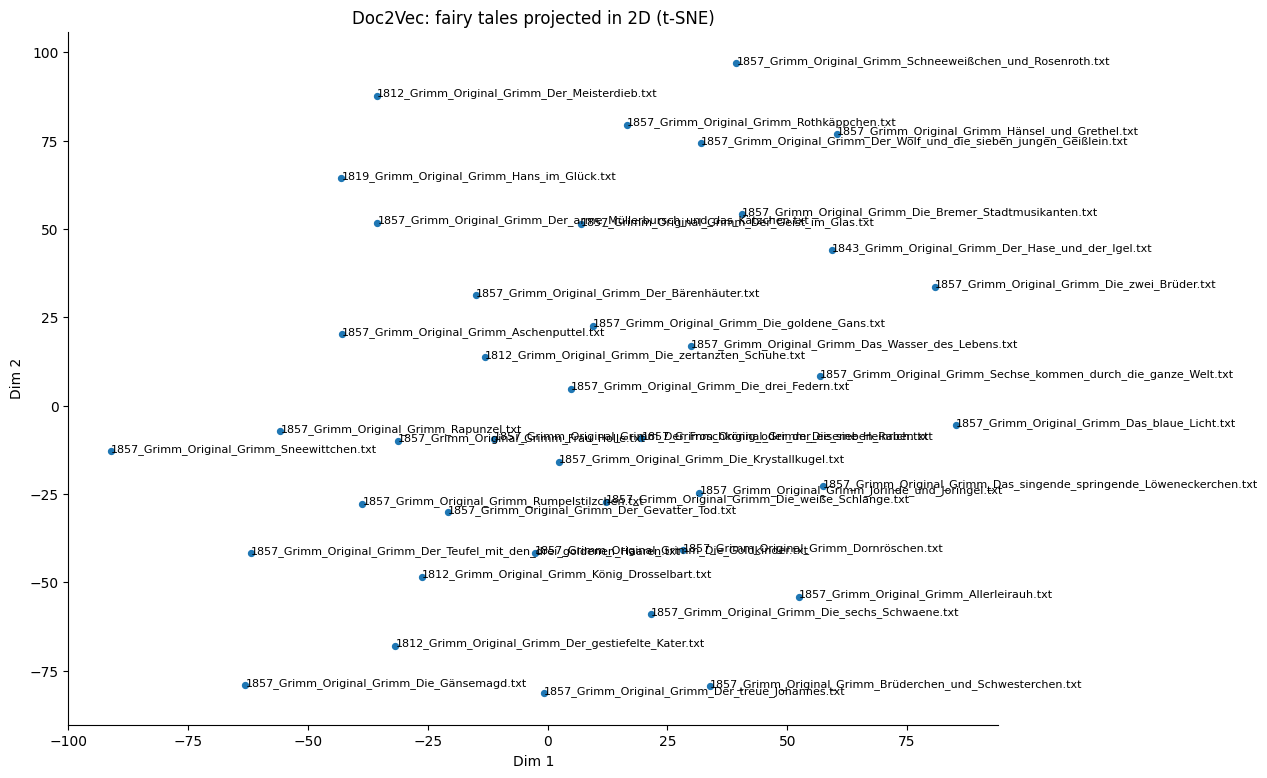

In [ ]:

# Create a figure for the visualization
plt.figure(figsize=(12, 9))

# Plot each fairy tale as a point in the 2D semantic space
plt.scatter(X1[:,0], X1[:,1], s=18)

# Add labels (file names) next to each point
for i, t in enumerate(tags):
    plt.text(X1[i,0], X1[i,1], t, fontsize=8)

# Add title and axis labels
plt.title("Doc2Vec: fairy tales projected in 2D (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

# Remove unnecessary borders
ax = plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Display the plot
plt.show()

In [ ]:
# Find the words most semantically similar to a given word
# The model returns the top 20 words with the highest cosine similarity
# based on the word embeddings learned during training
model.wv.most_similar("wald", topn=20)

[('großen', 0.8951470255851746),
 ('erreichen', 0.8455501198768616),
 ('hinaus', 0.8389427065849304),
 ('hirschkuh', 0.8315480351448059),
 ('tiefer', 0.8227648138999939),
 ('begleitung', 0.8205341696739197),
 ('reisig', 0.8172277808189392),
 ('gelangte', 0.7933477759361267),
 ('liefen', 0.7817118763923645),
 ('fröhlich', 0.7763880491256714),
 ('hirsch', 0.776260495185852),
 ('erhielten', 0.769978404045105),
 ('hohlen', 0.7686052322387695),
 ('wege', 0.7683948278427124),
 ('fanden', 0.7681055665016174),
 ('gingen', 0.7663712501525879),
 ('wild', 0.7637817859649658),
 ('hauen', 0.7626893520355225),
 ('warteten', 0.7586566209793091),
 ('getrost', 0.7555904984474182)]

In [ ]:
# Retrieve the fairy tales that are most semantically similar to a given tale
# Similarity is computed using cosine similarity between the document vectors learned by the Doc2Vec model
model.dv.most_similar("1812_Grimm_Original_Grimm_Der_gestiefelte_Kater.txt", topn=10)

[('1812_Grimm_Original_Grimm_König_Drosselbart.txt', 0.6714086532592773),
 ('1812_Grimm_Original_Grimm_Der_Meisterdieb.txt', 0.5415089726448059),
 ('1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusikanten.txt',
  0.43487435579299927),
 ('1857_Grimm_Original_Grimm_Das_blaue_Licht.txt', 0.3974011242389679),
 ('1857_Grimm_Original_Grimm_Sechse_kommen_durch_die_ganze_Welt.txt',
  0.38779929280281067),
 ('1857_Grimm_Original_Grimm_Der_arme_Müllerbursch_und_das_Kätzchen.txt',
  0.36360153555870056),
 ('1857_Grimm_Original_Grimm_Der_Gevatter_Tod.txt', 0.3623286783695221),
 ('1812_Grimm_Original_Grimm_Die_zertanzten_Schuhe.txt', 0.3265383541584015),
 ('1857_Grimm_Original_Grimm_Der_Geist_im_Glas.txt', 0.32072827219963074),
 ('1843_Grimm_Original_Grimm_Der_Hase_und_der_Igel.txt', 0.3064624071121216)]

In [ ]:
# Import the KMeans clustering algorithm from scikit-learn
from sklearn.cluster import KMeans

# Define the number of clusters
# This determines how many groups the fairy tales will be divided into
k = 5  # number of clusters (can be adjusted)

# Initialize the KMeans model
# random_state ensures reproducibility of the clustering results
kmeans = KMeans(n_clusters=k, random_state=42)

# Apply the clustering algorithm to the document embeddings
# X contains the Doc2Vec vectors for each fairy tale
clusters = kmeans.fit_predict(X_1)

# Print the cluster labels for the first 10 documents
# Each number represents the cluster assigned to that fairy tale
print(clusters[:10])

[4 1 3 2 3 2 3 2 1 3]


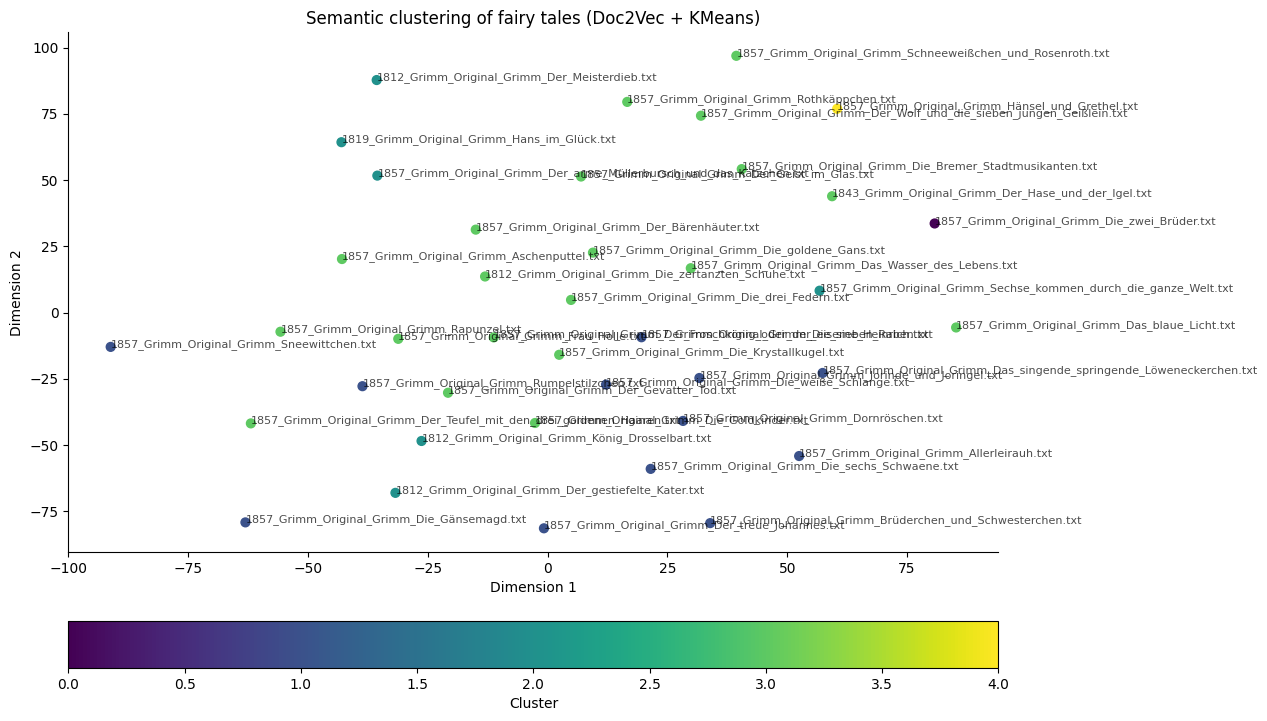

In [ ]:
# Import matplotlib for plotting the semantic map
import matplotlib.pyplot as plt

# Create a figure with a larger size for better readability
plt.figure(figsize=(12, 9))

# Plot the 2D coordinates of the fairy tales obtained from t-SNE
# Points are colored according to their K-Means cluster assignment
plt.scatter(
    X1[:, 0],      # x-coordinate (dimension 1 from t-SNE)
    X1[:, 1],      # y-coordinate (dimension 2 from t-SNE)
    c=clusters,    # color of each point corresponds to its cluster
    s=40           # size of the points
)

# Add labels (file names) next to each point
# This allows us to identify which fairy tale corresponds to each location
for i, tag in enumerate(tags):
    plt.text(
        X1[i, 0],
        X1[i, 1],
        tag,
        fontsize=8,
        alpha=0.7     # slight transparency so labels don't dominate the plot
    )

# Add title and axis labels
plt.title("Semantic clustering of fairy tales (Doc2Vec + KMeans)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# Add a colorbar to show cluster categories
plt.colorbar(label="Cluster", orientation="horizontal", pad=0.1)

# Remove unnecessary borders
ax = plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Display the visualization
plt.show()


## Group 2: Adaptations

In [ ]:
# Define a function to retrieve the most similar adapted fairy tales
# based on the document embeddings learned by the Doc2Vec model (model2)
def similar_adaptations(archiv, topn=10):

    # Check whether the file exists in the model vocabulary
    if archiv not in model2.dv:
        print("This file is not found in the model.")
        return

    # Retrieve the most similar documents using cosine similarity
    similars = model2.dv.most_similar(archiv, topn=topn)

    # Convert the results into a pandas DataFrame for easier inspection
    return pd.DataFrame(similars, columns=["similar_file", "similarity"])


# Example: find the 10 adapted fairy tales most similar to the first document
# in the adapted corpus
similar_adaptations(df2.loc[0, "file"], topn=10)

,similar_file,similarity
0,2019_Grimm_Wikipedia_Woolverton_Maleficient2.txt,0.986689
1,1959_Grimm_Wikipedia_Rinaldi_Dornröschen.txt,0.955924
2,1980_Grimm_Wikipedia_Hübner_Gevatter_Tod.txt,0.624936
3,2015_Grimm_Wikipedia_Nellis_Die_sieben_Raben.txt,0.614200
4,1993_Grimm_Wikipedia_Aujezdsky_Die_sieben_Rabe...,0.572946
5,2025_Grimm_Wikipedia_Blichfeldt_The_Ugly_Steps...,0.543434
6,2015_Grimm_Wikipedia_Ungureit_Der_Prinz_im_Bär...,0.521888
7,2009_Grimm_Wikipedia_Kömmerling_Die_Gänsemagd.txt,0.517164
8,1960_Grimm_Wikipedia_Carballido_Macario.txt,0.489968
9,1982_Grimm_Wikipedia_Beck_Der_Prinz_hinter_den...,0.487810


In [ ]:
# Define a function that searches for the most similar adapted fairy tales
# based on a new input text
def looking_for_text2(text2, topn=10):

    # Tokenize the input text using the same preprocessing pipeline
    # used when training the Doc2Vec model
    toks = tokenize(text2)

    # Infer a document vector for the new text
    # This generates an embedding even though the text was not in the training corpus
    vec = model2.infer_vector(toks, epochs=50)

    # Retrieve the most similar documents from the adapted fairy tales corpus
    # using cosine similarity between vectors
    sims = model2.dv.most_similar([vec], topn=topn)

    # Convert the results into a pandas DataFrame for easier inspection
    return pd.DataFrame(sims, columns=["file", "similarity"])


# Example query: search for adapted fairy tales similar to the input phrase
looking_for_text2("es gibt eine kleine meerjungfrau", topn=10)

,file,similarity
0,1982_Grimm_Wikipedia_Ensikat_Der_Hase_und_der_...,0.858996
1,2011_Grimm_Wikipedia_Kreis_Die_zertanzten_Schu...,0.822388
2,2025_Grimm_Wikipedia_Blichfeldt_The_Ugly_Steps...,0.819741
3,2021_Grimm_Wikipedia_Schönberger_Der_Geist_im_...,0.810199
4,1949_Grimm_Wikipedia_Hamel_Hans_im_Glück.txt,0.787895
5,1977_Grimm_Wikipedia_Schmenger_Die_zertanzten_...,0.774059
6,1978_Grimm_Wikipedia_Hübner_Der_Meisterdieb.txt,0.769424
7,2010_Grimm_Wikipedia_Bongartz_Der_Meisterdieb.txt,0.764717
8,1986_Grimm_Wikipedia_Beck_Der_Bärenhäuter.txt,0.762994
9,2009_Grimm_Wikipedia_Ungureit_Die_Bremer_Stadt...,0.761359


In [ ]:
# Retrieve the document tags (file names) from the adapted fairy tales Doc2Vec model
# Each tag corresponds to one adapted fairy tale in the corpus
tags2 = list(model2.dv.index_to_key)

# Extract the document vectors for all adapted fairy tales
# Each vector represents the semantic embedding of a document learned by Doc2Vec
X_2 = np.array([model2.dv[tag] for tag in tags2])

# Print the shape of the matrix to verify its dimensions
# Rows = number of documents
# Columns = embedding dimensions (vector_size defined during training)
print(X_2.shape)

(87, 200)


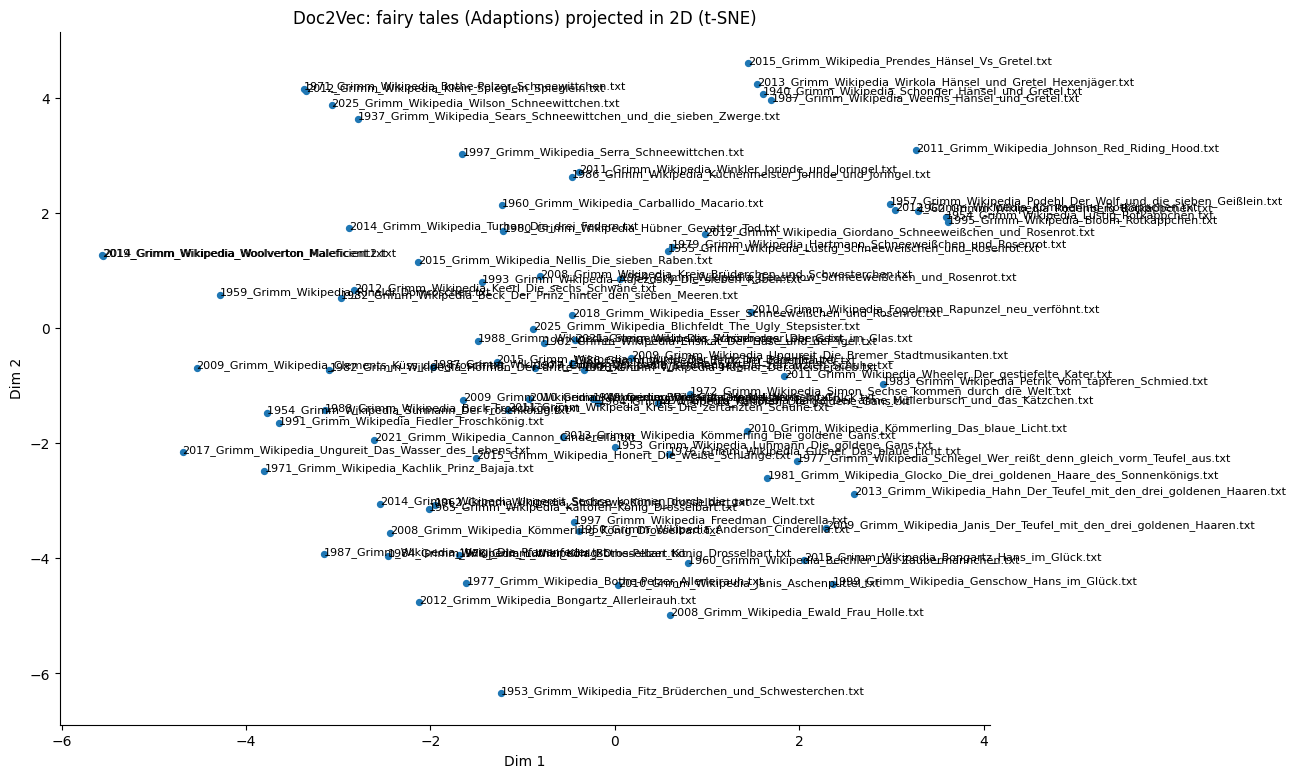

In [ ]:
# Initialize the t-SNE model to reduce high-dimensional document vectors to 2 dimensions
tsne2 = TSNE(
    n_components=2,          # Reduce embeddings to 2D for visualization
    random_state=42,         # Fix the random seed for reproducibility
    init="pca",              # Use PCA initialization to improve stability
    learning_rate="auto",    # Let the algorithm choose an appropriate learning rate

    # Perplexity controls the balance between local and global structure
    # The value adapts to the dataset size
    perplexity=min(30, max(5, len(tags2)//3))
)

# Apply t-SNE to the adapted fairy tale embeddings
# X_2 contains the Doc2Vec vectors from model2
X2 = tsne2.fit_transform(X_2)


# Create a figure for the visualization
plt.figure(figsize=(12, 9))

# Plot the projected documents in the 2D semantic space
plt.scatter(X2[:,0], X2[:,1], s=18)

# Add labels (file names) to each point to identify the fairy tales
for i, t in enumerate(tags2):
    plt.text(X2[i,0], X2[i,1], t, fontsize=8)

# Add title and axis labels
plt.title("Doc2Vec: fairy tales (Adaptions) projected in 2D (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

# Remove unnecessary plot borders for cleaner visualization
ax = plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Display the plot
plt.show()

In [ ]:
# Retrieve the words most semantically similar to one given word
# The model returns the top 20 words that appear in similar contexts
# according to the word embeddings learned during training
model2.wv.most_similar("meer", topn=20)

[('treiben', 0.9836943745613098),
 ('händler', 0.9746139049530029),
 ('besitzen', 0.9728634357452393),
 ('verwundert', 0.9713519215583801),
 ('mindestens', 0.9711703658103943),
 ('hätte', 0.9702049493789673),
 ('lügen', 0.9691140651702881),
 ('mehrfach', 0.9689739346504211),
 ('ankommt', 0.9687525033950806),
 ('dinge', 0.9684019088745117),
 ('fangen', 0.9682499170303345),
 ('kätzchen', 0.9658764600753784),
 ('entlang', 0.9658366441726685),
 ('arbeitet', 0.9650091528892517),
 ('malick', 0.964280903339386),
 ('müllerbursche', 0.9627976417541504),
 ('besten', 0.9625122547149658),
 ('melodie', 0.9601183533668518),
 ('handel', 0.9591953754425049),
 ('bauern', 0.9591501951217651)]

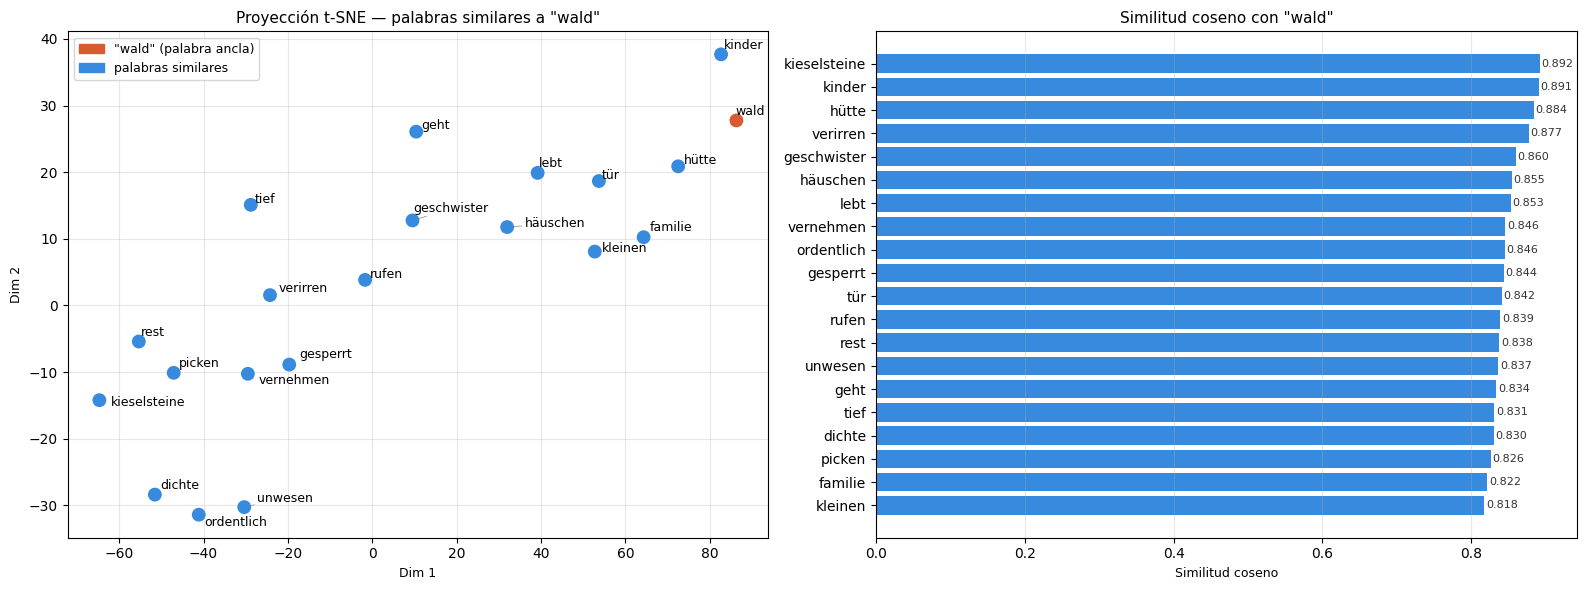

In [ ]:
!pip install adjustText
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from adjustText import adjust_text




similar_words2 = model2.wv.most_similar("wald", topn=20)
words = ["wald"] + [w for w, _ in similar_words2]


X_words = np.array([model2.wv[w] for w in words])


tsne.set_params(perplexity=5)
coords_plot = tsne.fit_transform(X_words)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
colors = ["#D85A30"] + ["#378ADD"] * 20
ax1.scatter(coords_plot[:, 0], coords_plot[:, 1], c=colors, s=80, zorder=3)

texts = []
for i, word in enumerate(words):
    texts.append(ax1.text(coords_plot[i, 0], coords_plot[i, 1], word, fontsize=9))

adjust_text(texts, ax=ax1, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

anchor = mpatches.Patch(color="#D85A30", label='"wald" (palabra ancla)')
similar = mpatches.Patch(color="#378ADD", label="palabras similares")
ax1.legend(handles=[anchor, similar], fontsize=9)
ax1.set_title('Proyección t-SNE — palabras similares a "wald"', fontsize=11)
ax1.set_xlabel("Dim 1", fontsize=9)
ax1.set_ylabel("Dim 2", fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
bar_words = [w for w, _ in similar_words2]
bar_scores = [s for _, s in similar_words2]

bars = ax2.barh(bar_words[::-1], bar_scores[::-1], color="#378ADD", edgecolor="none")
for bar, score in zip(bars, bar_scores[::-1]):
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f"{score:.3f}", va="center", fontsize=8, color="#333")

ax2.set_xlabel("Similitud coseno", fontsize=9)
ax2.set_title('Similitud coseno con "wald"', fontsize=11)
ax2.set_xlim(0, max(bar_scores) + 0.05)
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("wald_similarity_tsne_model2.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Retrieve the fairy tales that are most semantically similar to a given document
# The similarity is computed using cosine similarity between document embeddings learned by the Doc2Vec model trained on the adapted fairy tales corpus
model2.dv.most_similar("1937_Grimm_Wikipedia_Sears_Schneewittchen_und_die_sieben_Zwerge.txt", topn=10)

[('2025_Grimm_Wikipedia_Wilson_Schneewittchen.txt', 0.9342701435089111),
 ('1971_Grimm_Wikipedia_Bothe-Pelzer_Schneewittchen.txt', 0.9175965785980225),
 ('2012_Grimm_Wikipedia_Klein_Spieglein_Spieglein.txt', 0.8971333503723145),
 ('2008_Grimm_Wikipedia_Kreis_Brüderchen_und_Schwesterchen.txt',
  0.6371811628341675),
 ('2021_Grimm_Wikipedia_Schönberger_Der_Geist_im_Glas.txt',
  0.5921701192855835),
 ('2025_Grimm_Wikipedia_Blichfeldt_The_Ugly_Stepsister.txt',
  0.5884140729904175),
 ('1940_Grimm_Wikipedia_Schonger_Hänsel_und_Gretel.txt', 0.5830555558204651),
 ('1993_Grimm_Wikipedia_Aujezdsky_Die_sieben_Raben.txt', 0.571634829044342),
 ('1957_Grimm_Wikipedia_Podehl_Der_Wolf_und_die_sieben_Geißlein.txt',
  0.5661751627922058),
 ('1982_Grimm_Wikipedia_Ensikat_Der_Hase_und_der_Igel.txt',
  0.5640550851821899)]

In [ ]:
# Define the number of clusters
# This determines how many groups the adapted fairy tales will be divided into
k2 = 5  # number of clusters (can be adjusted)

# Initialize the K-Means clustering model
# random_state ensures reproducibility of the results
kmeans2 = KMeans(n_clusters=k2, random_state=42)

# Apply the clustering algorithm to the document embeddings
# X_2 contains the Doc2Vec vectors for the adapted fairy tales
clusters2 = kmeans2.fit_predict(X_2)

# Print the cluster labels for the first 10 documents
# Each number corresponds to the cluster assigned to that document
print(clusters2[:10])

[1 3 3 3 3 0 3 0 3 3]


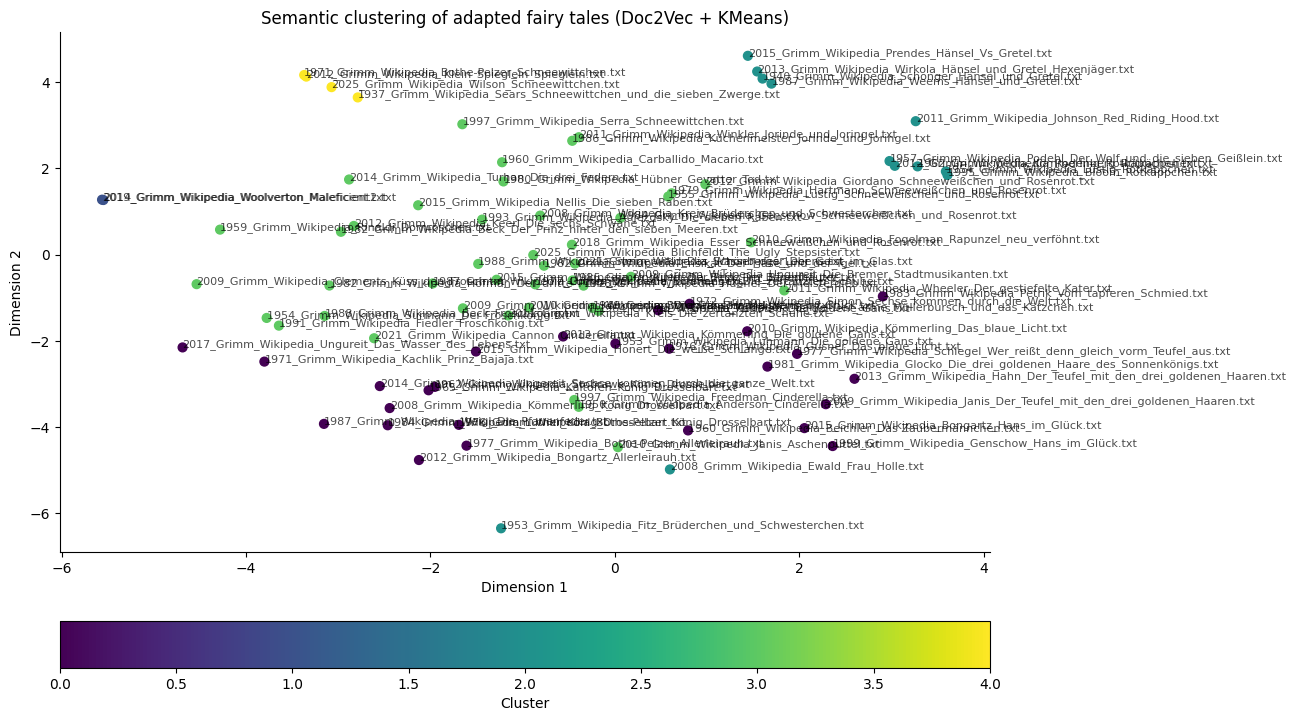

In [ ]:
# Import matplotlib for plotting the semantic map
import matplotlib.pyplot as plt

# Create a figure with a larger size for better readability
plt.figure(figsize=(12, 9))

# Plot the 2D coordinates obtained from t-SNE
# Points are colored according to their K-Means cluster assignment
plt.scatter(
    X2[:, 0],      # x-coordinate (dimension 1 from t-SNE)
    X2[:, 1],      # y-coordinate (dimension 2 from t-SNE)
    c=clusters2,   # color represents the cluster label
    s=40           # size of each point
)

# Add text labels (file names) next to each point
# This helps identify which fairy tale corresponds to each position
for i, tag in enumerate(tags2):
    plt.text(
        X2[i, 0],
        X2[i, 1],
        tag,
        fontsize=8,
        alpha=0.7   # slight transparency for readability
    )

# Add title and axis labels
plt.title("Semantic clustering of adapted fairy tales (Doc2Vec + KMeans)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# Add a horizontal colorbar showing the cluster labels
plt.colorbar(label="Cluster", orientation="horizontal", pad=0.1)

# Remove unnecessary borders to make the plot cleaner
ax = plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Display the visualization
plt.show()


# Group 3: Copilot versions

In [ ]:
# Define a function to retrieve the most similar Copilot-generated fairy tales
# based on the document embeddings learned by the Doc2Vec model (model3)
def similar_copilot_versions(archiv, topn=10):

    # Check whether the file exists in the model vocabulary
    if archiv not in model3.dv:
        print("This file is not found in the model.")
        return

    # Retrieve the most similar documents using cosine similarity
    similares = model3.dv.most_similar(archiv, topn=topn)

    # Convert the results into a pandas DataFrame for easier inspection
    return pd.DataFrame(similares, columns=["similar_file", "similarity"])


# Example: find the 10 Copilot-generated fairy tales most similar
# to the first document in the Copilot corpus
similar_copilot_versions(df3.loc[0, "file"], topn=10)

,similar_file,similarity
0,1986_Grimm_Copilot_Beck_Der_Bärenhäuter.txt,0.971503
1,1971_Grimm_Copilot_Kachlik_Prinz_Bajaja.txt,0.958976
2,1953_Grimm_Copilot_Luhmann_Die_goldene_Gans.txt,0.957694
3,1964_Grimm_Copilot_Kaltofen_Die_goldene_Gans.txt,0.953684
4,1988_Grimm_Copilot_Beck_Froschkönig.txt,0.952860
5,2008_Grimm_Copilot_Kömmerling_König_Drosselbar...,0.947210
6,2017_Grimm_Copilot_Ungureit_Das_Wasser_des_Leb...,0.937235
7,1976_Grimm_Copilot_Gusner_Das_blaue_Licht.txt,0.935490
8,2012_Grimm_Copilot_Bongartz_Allerleirauh.txt,0.935407
9,2011_Grimm_Copilot_Kreis_Die_zertanzten_Schuhe...,0.925629


In [ ]:
# Define a function that searches for the most similar Copilot-generated fairy tales
# based on a new input text
def looking_for_text3(text3, topn=10):

    # Tokenize the input text using the same preprocessing pipeline
    # that was applied to the training corpus
    toks = tokenize(text3)

    # Infer a vector representation for the new text using the trained Doc2Vec model
    # This allows the model to represent texts that were not part of the training data
    vec = model3.infer_vector(toks, epochs=50)

    # Retrieve the most similar documents from the Copilot corpus
    # using cosine similarity between document vectors
    sims = model3.dv.most_similar([vec], topn=topn)

    # Convert the results into a pandas DataFrame for easier inspection
    return pd.DataFrame(sims, columns=["file", "similarity"])


# Example query: search for Copilot-generated fairy tales similar to the input phrase
looking_for_text3("es gibt eine kleine meerjungfrau", topn=10)

,file,similarity
0,1960_Grimm_Copilot_Carballido_Macario.txt,0.973712
1,2018_Grimm_Copilot_Esser_Schneeweißchen_und_Ro...,0.970482
2,2025_Grimm_Copilot_Blichfeldt_The_Ugly_Stepsis...,0.968534
3,1979_Grimm_Copilot_Hartmann_Schneeweißchen_und...,0.959928
4,1980_Grimm_Copilot_Hübner_Gevatter_Tod.txt,0.952137
5,1982_Grimm_Copilot_Ensikat_Der_Hase_und_der_Ig...,0.949297
6,2009_Grimm_Copilot_Ungureit_Die_Bremer_Stadtmu...,0.946615
7,2021_Grimm_Copilot_Schönberger_Der_Geist_im_Gl...,0.937971
8,1953_Grimm_Copilot_Fitz_Brüderchen_und_Schwest...,0.930391
9,1959_Grimm_Copilot_Rinaldi_Dornröschen.txt,0.917268


In [ ]:
# Retrieve the document tags (file names) from the Doc2Vec model trained on the Copilot corpus
# Each tag corresponds to one generated fairy tale
tags3 = list(model3.dv.index_to_key)   # names of the fairy tales

# Extract the document vectors (embeddings) for all Copilot-generated stories
# Each vector represents the semantic embedding learned by the Doc2Vec model
X_3 = np.array([model3.dv[tag] for tag in tags3])

# Print the shape of the embedding matrix
# Rows = number of fairy tales
# Columns = dimensionality of the document vectors (vector_size)
print(X_3.shape)  # (n_fairy_tales, vector_size)


(87, 200)


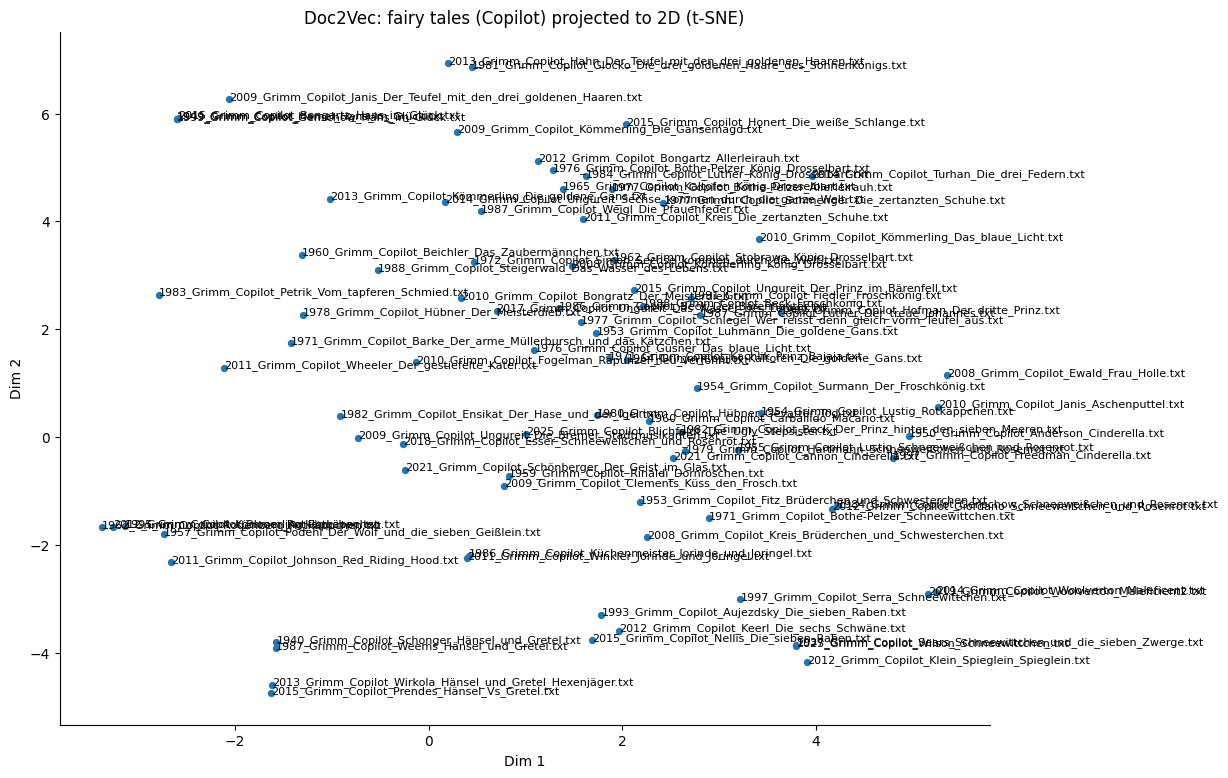

In [ ]:
# Initialize the t-SNE model to reduce high-dimensional document embeddings to 2D
tsne3 = TSNE(
    n_components=2,          # Reduce embeddings to 2 dimensions for visualization
    random_state=42,         # Fix the random seed for reproducibility
    init="pca",              # Use PCA initialization to improve stability
    learning_rate="auto",    # Let the algorithm choose an appropriate learning rate

    # Perplexity controls the balance between local and global structure
    # The value adapts to the dataset size
    perplexity=min(30, max(5, len(tags3)//3))
)

# Apply t-SNE to the Copilot document embeddings
# X_3 contains the Doc2Vec vectors from model3
X3 = tsne3.fit_transform(X_3)

# Create a figure for visualization
plt.figure(figsize=(12, 9))

# Plot the fairy tales in the 2D semantic space
plt.scatter(X3[:,0], X3[:,1], s=18)

# Add labels (file names) to identify each fairy tale
for i, t in enumerate(tags3):
    plt.text(X3[i,0], X3[i,1], t, fontsize=8)

# Add title and axis labels
plt.title("Doc2Vec: fairy tales (Copilot) projected to 2D (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

# Remove unnecessary borders for a cleaner visualization
ax = plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Display the plot
plt.show()

In [ ]:
# Retrieve the words most semantically similar to a given word
# The model returns the top 20 words that appear in similar contexts based on the word embeddings learned from the Copilot-generated corpus
model3.wv.most_similar("mann", topn=20)

[('all', 0.969104528427124),
 ('hast', 0.9666378498077393),
 ('bündel', 0.9626013040542603),
 ('vielleicht', 0.962514340877533),
 ('traut', 0.9624965190887451),
 ('besitzt', 0.9624621272087097),
 ('reisen', 0.9623170495033264),
 ('lachte', 0.962033748626709),
 ('klebte', 0.9610787034034729),
 ('hob', 0.9609116911888123),
 ('verneigte', 0.9601669311523438),
 ('demütig', 0.9601592421531677),
 ('meisterdieb', 0.9598489999771118),
 ('isabella', 0.9593825340270996),
 ('tritt', 0.9591359496116638),
 ('wusste', 0.9584223628044128),
 ('lieben', 0.9579727053642273),
 ('wunderlichen', 0.957952618598938),
 ('herzlich', 0.9577406644821167),
 ('halten', 0.9576216340065002)]

In [ ]:
# Retrieve the Copilot-generated fairy tales that are most semantically similar to a given document
# The similarity is calculated using cosine similarity between document embeddings learned by the Doc2Vec model trained on the Copilot corpus
model3.dv.most_similar("1937_Grimm_Copilot_Sears_Schneewittchen_und_die_sieben_Zwerge.txt", topn=10)

[('2025_Grimm_Copilot_Wilson_Schneewittchen.txt', 0.9797821044921875),
 ('1971_Grimm_Copilot_Bothe-Pelzer_Schneewittchen.txt', 0.9578975439071655),
 ('2012_Grimm_Copilot_Klein_Spieglein_Spieglein.txt', 0.932621955871582),
 ('1997_Grimm_Copilot_Serra_Schneewittchen.txt', 0.9256570935249329),
 ('2019_Grimm_Copilot_Woolverton_Maleficient2.txt', 0.8546362519264221),
 ('1982_Grimm_Copilot_Beck_Der_Prinz_hinter_den_sieben_Meeren.txt',
  0.8406903743743896),
 ('1953_Grimm_Copilot_Fitz_Brüderchen_und_Schwesterchen.txt',
  0.8275916576385498),
 ('2008_Grimm_Copilot_Kreis_Brüderchen_und_Schwesterchen.txt',
  0.8199342489242554),
 ('1979_Grimm_Copilot_Hartmann_Schneeweißchen_und_Rosenrot.txt',
  0.8093998432159424),
 ('2021_Grimm_Copilot_Cannon_Cinderella.txt', 0.7984229326248169)]

In [ ]:
# Define the number of clusters for the Copilot fairy tales corpus
k3 = 5  # number of clusters

# Initialize the K-Means clustering model
# random_state ensures reproducible results
kmeans3 = KMeans(n_clusters=k3, random_state=42)

# Apply K-Means clustering to the Doc2Vec document embeddings
# X_3 contains the high-dimensional document vectors
clusters3 = kmeans3.fit_predict(X_3)

# Print the cluster labels for the first 10 documents
# Each number represents the cluster assigned to a fairy tale
print(clusters3[:10])  # cluster labels

[2 2 3 3 0 2 2 2 1 2]


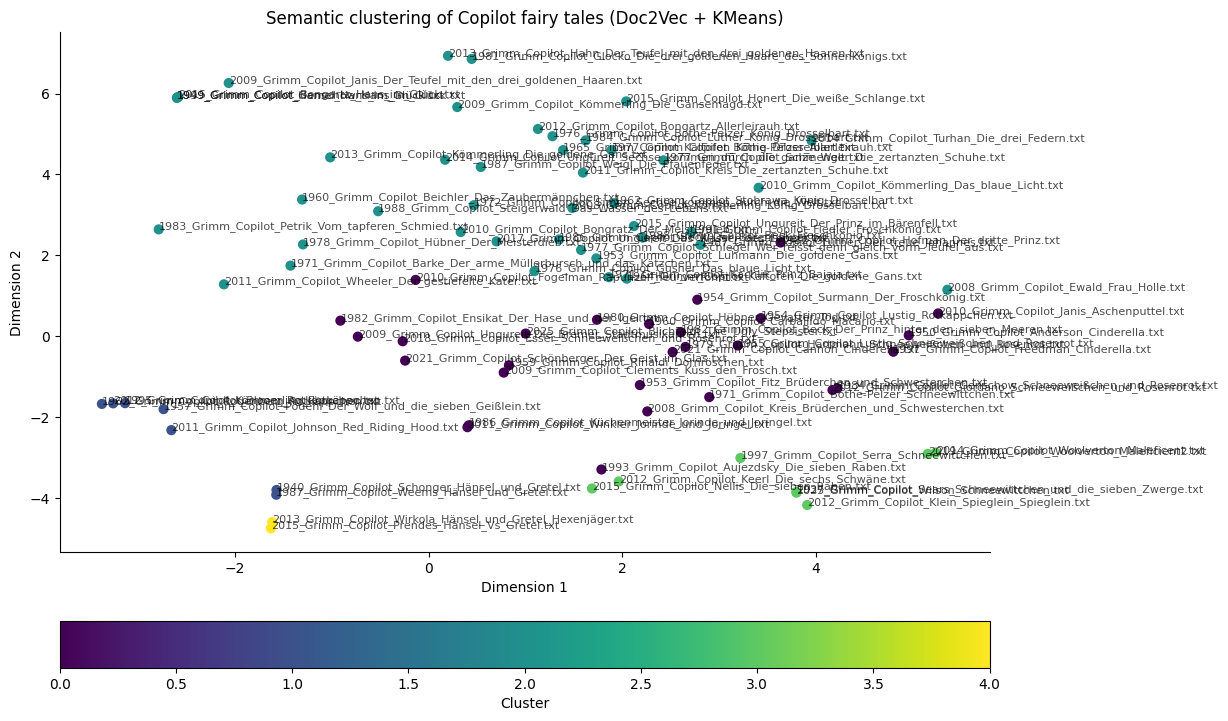

In [ ]:
# Import matplotlib for plotting the semantic map
import matplotlib.pyplot as plt

# Create a larger figure for better readability
plt.figure(figsize=(12, 9))

# Plot the 2D coordinates obtained from t-SNE
# Points are colored according to their K-Means cluster assignment
plt.scatter(
    X3[:, 0],      # x-coordinate (t-SNE dimension 1)
    X3[:, 1],      # y-coordinate (t-SNE dimension 2)
    c=clusters3,   # color indicates the cluster label
    s=40           # size of the points
)

# Add labels (file names) next to each point
# This helps identify which fairy tale corresponds to each location
for i, tag in enumerate(tags3):
    plt.text(
        X3[i, 0],
        X3[i, 1],
        tag,
        fontsize=8,
        alpha=0.7   # slight transparency to improve readability
    )

# Add title and axis labels
plt.title("Semantic clustering of Copilot fairy tales (Doc2Vec + KMeans)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# Add a horizontal colorbar indicating cluster membership
plt.colorbar(label="Cluster", orientation="horizontal", pad=0.1)

# Remove unnecessary borders to make the plot visually cleaner
ax = plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Display the plot
plt.show()

# 4. Comparison (2 groups: Original fairy tales vs. Adaptations)

In [ ]:
from collections import Counter

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
from collections import Counter

# Utility function to ensure the "tokens" column is safe to use
def _safe_tokens_col(dframe: pd.DataFrame, col="tokens"):
    """
    Returns a pandas Series where each element is a list of tokens.
    This function fixes potential issues such as NaN values, floats,
    None values, or accidental strings in the tokens column.
    """

    # If the column exists, use it; otherwise create empty token lists
    s = dframe[col] if col in dframe.columns else pd.Series([[]]*len(dframe))

    # Function to sanitize each element
    def fix(x):
        # If already a list of tokens, return it
        if isinstance(x, list):
            return x

        # Handle missing values (None or NaN)
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return []

        # If tokens were accidentally stored as a string, split them
        if isinstance(x, str):
            return x.split()

        # Default fallback
        return []

    # Apply cleaning function to the entire column
    return s.apply(fix)


# Function to compute corpus-level statistics (robust implementation)
def corpus_stats(dframe: pd.DataFrame, name: str):

    # Retrieve a cleaned tokens column
    toks_series = _safe_tokens_col(dframe, "tokens")

    # Compute the length (number of tokens) for each document
    lengths = toks_series.apply(len).to_numpy()

    # Build the vocabulary set (unique tokens in the corpus)
    vocab = set(t for toks in toks_series for t in toks)

    # Total number of tokens in the corpus
    total_tokens = int(lengths.sum())

    # Vocabulary size
    vocab_size = int(len(vocab))

    # Type-Token Ratio (lexical diversity)
    # Measures vocabulary richness relative to corpus size
    ttr = (vocab_size / total_tokens) if total_tokens else np.nan

    # Return a dictionary with corpus statistics
    return {
        "corpus": name,
        "n_texts": int(len(dframe)),
        "total_tokens": total_tokens,
        "avg_tokens_per_text": float(np.mean(lengths)) if len(lengths) else np.nan,
        "median_tokens_per_text": float(np.median(lengths)) if len(lengths) else np.nan,
        "min_tokens_text": int(np.min(lengths)) if len(lengths) else np.nan,
        "max_tokens_text": int(np.max(lengths)) if len(lengths) else np.nan,
        "unique_vocabulary": vocab_size,
        "type_token_ratio": float(ttr),
    }


# Function to retrieve the most frequent tokens in a corpus
def top_words(dframe: pd.DataFrame, topn=20):

    # Retrieve a cleaned tokens column
    toks_series = _safe_tokens_col(dframe, "tokens")

    # Count token frequencies across the entire corpus
    c = Counter(t for toks in toks_series for t in toks)

    # Return the top-N most frequent tokens as a DataFrame
    return pd.DataFrame(c.most_common(topn), columns=["token", "freq"])

In [ ]:
# Compute corpus-level statistics for two datasets:
# 1) Original Grimm fairy tales
# 2) Adapted versions of the fairy tales
stats_df_1_2 = pd.DataFrame([
    corpus_stats(df,  "Grimm_Märchen"),
    corpus_stats(df2, "Grimm_Adaptionen")
])

# Set the corpus name as the index to make the table easier to read
stats_df_1_2 = stats_df_1_2.set_index("corpus")

# Display the comparison table of corpus statistics
display(stats_df_1_2)

,n_texts,total_tokens,avg_tokens_per_text,median_tokens_per_text,min_tokens_text,max_tokens_text,unique_vocabulary,type_token_ratio
corpus,,,,,,,,
Grimm_Märchen,40,33110,827.750000,739.5,386,3466,6427,0.194111
Grimm_Adaptionen,87,27362,314.505747,291.0,45,824,7293,0.266538


In [ ]:
# Utility function to ensure the "tokens" column contains valid lists of tokens
# This function handles potential issues such as NaN values, None, or strings
def _safe_tokens_col(dframe: pd.DataFrame, col="tokens"):

    # If the column exists, use it; otherwise create empty token lists
    s = dframe[col] if col in dframe.columns else pd.Series([[]]*len(dframe))

    # Cleaning function applied to each element
    def fix(x):
        # If the element is already a list of tokens, keep it
        if isinstance(x, list):
            return x

        # Handle missing values
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return []

        # If tokens were accidentally stored as a string, split them
        if isinstance(x, str):
            return x.split()

        # Default fallback
        return []

    # Apply the cleaning function to the entire column
    return s.apply(fix)


# Create a table containing file names from the original Grimm corpus
lens1 = df[["file"]].copy()

# Add a column identifying the corpus
lens1["corpus"] = "Grimm_Märchen"

# Compute the number of tokens for each text
lens1["n_tokens"] = _safe_tokens_col(df, "tokens").apply(len)


# Repeat the same process for the adapted fairy tales corpus
lens2 = df2[["file"]].copy()
lens2["corpus"] = "Grimm_Adaptionen"
lens2["n_tokens"] = _safe_tokens_col(df2, "tokens").apply(len)


# Combine both corpora into a single table
lengths_all = pd.concat([lens1, lens2], ignore_index=True)

# Display the table showing token counts per text
display(lengths_all)

,file,corpus,n_tokens
0,1857_Grimm_Original_Grimm_Hänsel_und_Grethel.txt,Grimm_Märchen,1247
1,1857_Grimm_Original_Grimm_Der_treue_Johannes.txt,Grimm_Märchen,1277
2,1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusi...,Grimm_Märchen,540
3,1812_Grimm_Original_Grimm_König_Drosselbart.txt,Grimm_Märchen,711
4,1857_Grimm_Original_Grimm_Die_goldene_Gans.txt,Grimm_Märchen,675
...,...,...,...
122,1991_Grimm_Wikipedia_Fiedler_Froschkönig.txt,Grimm_Adaptionen,390
123,1979_Grimm_Wikipedia_Hartmann_Schneeweißchen_u...,Grimm_Adaptionen,291
124,1984_Grimm_Wikipedia_Genschow_Schneeweißchen_u...,Grimm_Adaptionen,134
125,1960_Grimm_Wikipedia_Carballido_Macario.txt,Grimm_Adaptionen,284


/tmp/ipykernel_1532/4130339774.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=["Grimm_Märchen","Grimm_Adaptionen"])


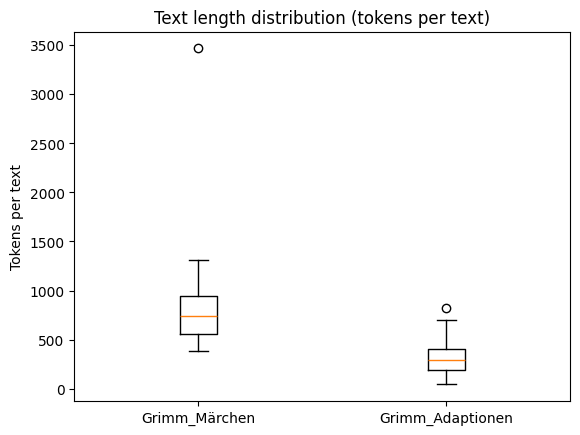

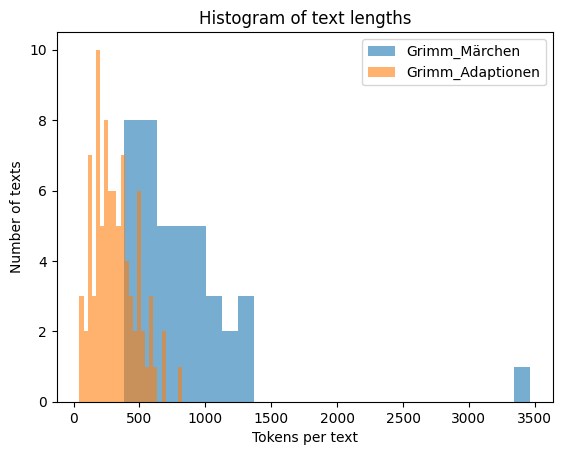

In [ ]:
# Create a boxplot to compare the distribution of text lengths (in tokens)
# between the original Andersen fairy tales and the adapted versions
plt.figure()

# Prepare the data for the boxplot
# Each element in the list corresponds to one corpus
data_box = [
    lengths_all.loc[lengths_all["corpus"]=="Grimm_Märchen", "n_tokens"].to_numpy(),
    lengths_all.loc[lengths_all["corpus"]=="Grimm_Adaptionen", "n_tokens"].to_numpy(),
]

# Plot the boxplot showing token length distributions
plt.boxplot(data_box, labels=["Grimm_Märchen","Grimm_Adaptionen"])

# Add title and axis label
plt.title("Text length distribution (tokens per text)")
plt.ylabel("Tokens per text")

# Display the plot
plt.show()


# Create a histogram to visualize how text lengths are distributed
# in each corpus
plt.figure()

# Histogram for the original Grimm fairy tales
plt.hist(data_box[0], bins=25, alpha=0.6, label="Grimm_Märchen")

# Histogram for the adapted fairy tales
plt.hist(data_box[1], bins=25, alpha=0.6, label="Grimm_Adaptionen")

# Add titles and axis labels
plt.title("Histogram of text lengths")
plt.xlabel("Tokens per text")
plt.ylabel("Number of texts")

# Show legend to distinguish the corpora
plt.legend()

# Display the plot
plt.show()

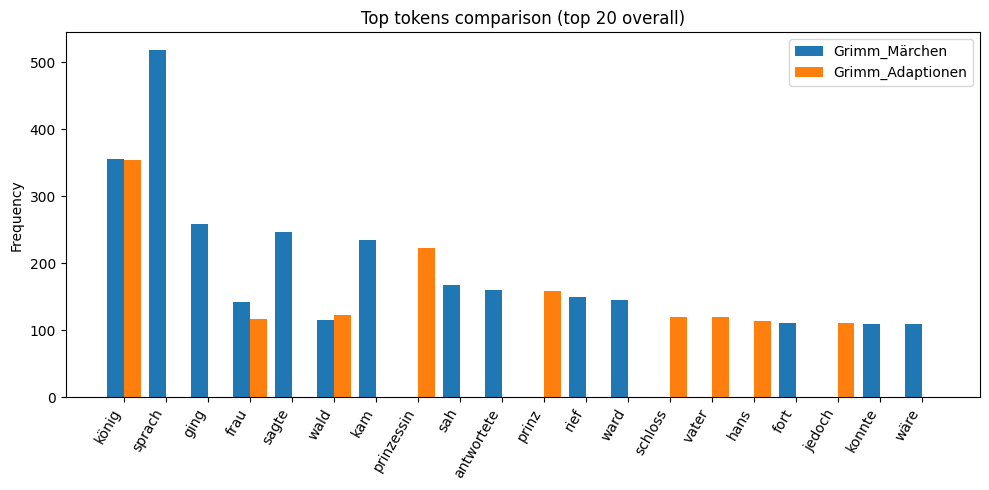

In [ ]:
# Number of top tokens to analyze
topn = 20

# Get the most frequent tokens for each corpus
# tw1: original Grimm fairy tales
# tw2: adapted fairy tales
tw1 = top_words(df,  topn=topn).set_index("token")
tw2 = top_words(df2, topn=topn).set_index("token")

# Create a combined vocabulary containing the top tokens from both corpora
# dict.fromkeys() preserves order while removing duplicates
vocab_top = list(dict.fromkeys(list(tw1.index) + list(tw2.index)))

# Create a comparison DataFrame indexed by tokens
comp = pd.DataFrame(index=vocab_top)

# Add token frequency columns for each corpus
comp["Grimm_Märchen"] = tw1["freq"]
comp["Grimm_Adaptionen"] = tw2["freq"]

# Replace missing values (tokens not present in one corpus) with zero
comp = comp.fillna(0).astype(int)

# Compute total frequency across both corpora
# This helps identify the most important tokens overall
comp["total"] = comp["Grimm_Märchen"] + comp["Grimm_Adaptionen"]

# Keep only the top tokens based on total frequency
comp_plot = comp.sort_values("total", ascending=False).head(topn).drop(columns=["total"])


# Create the figure
plt.figure(figsize=(10, 5))

# Generate x-axis positions for the tokens
x = np.arange(len(comp_plot.index))

# Width of each bar
width = 0.4

# Plot token frequencies for the original Andersen corpus
plt.bar(x - width/2, comp_plot["Grimm_Märchen"].values, width, label="Grimm_Märchen")

# Plot token frequencies for the adapted fairy tales corpus
plt.bar(x + width/2, comp_plot["Grimm_Adaptionen"].values, width, label="Grimm_Adaptionen")

# Set token labels on the x-axis
plt.xticks(x, comp_plot.index, rotation=60, ha="right")

# Add title and axis label
plt.title(f"Top tokens comparison (top {topn} overall)")
plt.ylabel("Frequency")

# Add legend to distinguish the two corpora
plt.legend()

# Adjust layout so labels do not overlap
plt.tight_layout()

# Display the plot
plt.show()

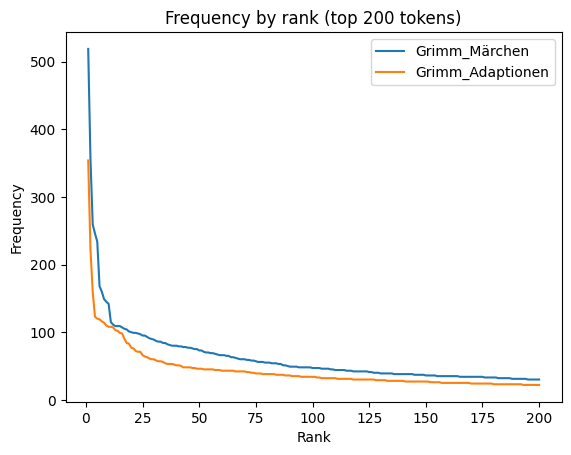

In [ ]:
# Function to compute the Zipf curve for a corpus
# It returns token ranks and their frequencies for the top-N tokens
def zipf_curve(dframe: pd.DataFrame, name: str, topn=200):

    # Retrieve a safe tokens column (ensures lists of tokens)
    toks_series = _safe_tokens_col(dframe, "tokens")

    # Count token frequencies across the corpus
    c = Counter(t for toks in toks_series for t in toks)

    # Extract the frequencies of the top-N most common tokens
    freqs = np.array([f for _, f in c.most_common(topn)])

    # Generate token ranks (1 = most frequent)
    ranks = np.arange(1, len(freqs) + 1)

    # Return ranks, frequencies, and corpus name
    return ranks, freqs, name


# Compute Zipf curves for the two corpora
r1, f1, n1 = zipf_curve(df,  "Grimm_Märchen")
r2, f2, n2 = zipf_curve(df2, "Grimm_Adaptionen")


# Plot frequency vs rank for both corpora
plt.figure()

# Plot Zipf curve for the original Grimm corpus
plt.plot(r1, f1, label=n1)

# Plot Zipf curve for the adapted fairy tales corpus
plt.plot(r2, f2, label=n2)

# Add title and axis labels
plt.title("Frequency by rank (top 200 tokens)")
plt.xlabel("Rank")
plt.ylabel("Frequency")

# Add legend to distinguish the corpora
plt.legend()

# Display the plot
plt.show()


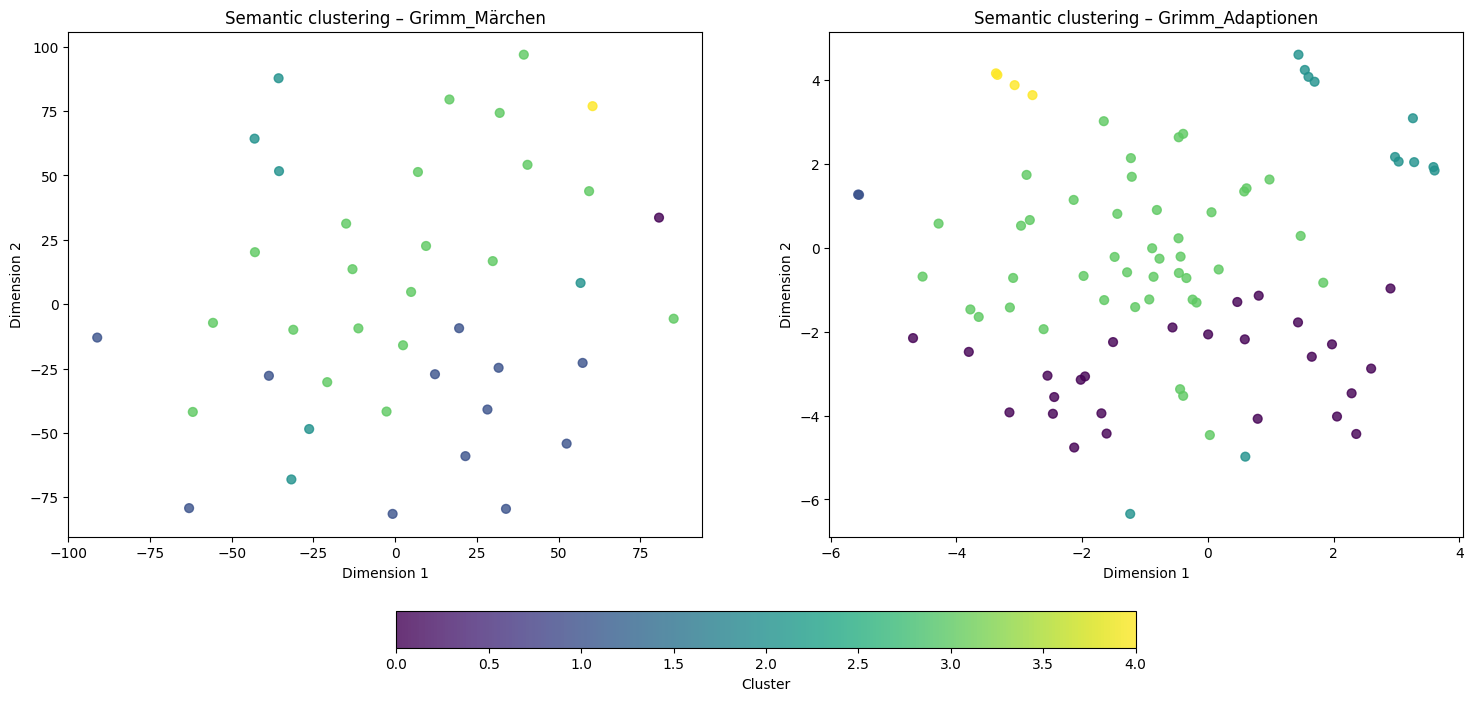

In [ ]:
# Create a figure with two subplots to compare the semantic clustering
# of the two corpora side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# -------- Group 1: Original Grimm fairy tales --------
# Scatter plot of the t-SNE projection colored by K-Means cluster
sc1 = axes[0].scatter(
    X1[:, 0],     # t-SNE dimension 1
    X1[:, 1],     # t-SNE dimension 2
    c=clusters,   # cluster labels from K-Means
    s=40,         # point size
    alpha=0.8     # slight transparency
)

# Add title and axis labels
axes[0].set_title("Semantic clustering – Grimm_Märchen")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")


# -------- Group 2: Adapted fairy tales --------
# Scatter plot of the t-SNE projection colored by K-Means cluster
sc2 = axes[1].scatter(
    X2[:, 0],     # t-SNE dimension 1
    X2[:, 1],     # t-SNE dimension 2
    c=clusters2,  # cluster labels from K-Means
    s=40,
    alpha=0.8
)

# Add title and axis labels
axes[1].set_title("Semantic clustering – Grimm_Adaptionen")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")


# -------- Shared horizontal colorbar --------
# The colorbar represents cluster membership
cbar = fig.colorbar(
    sc2,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.12
)

# Label the colorbar
cbar.set_label("Cluster")

# Display the figure
plt.show()

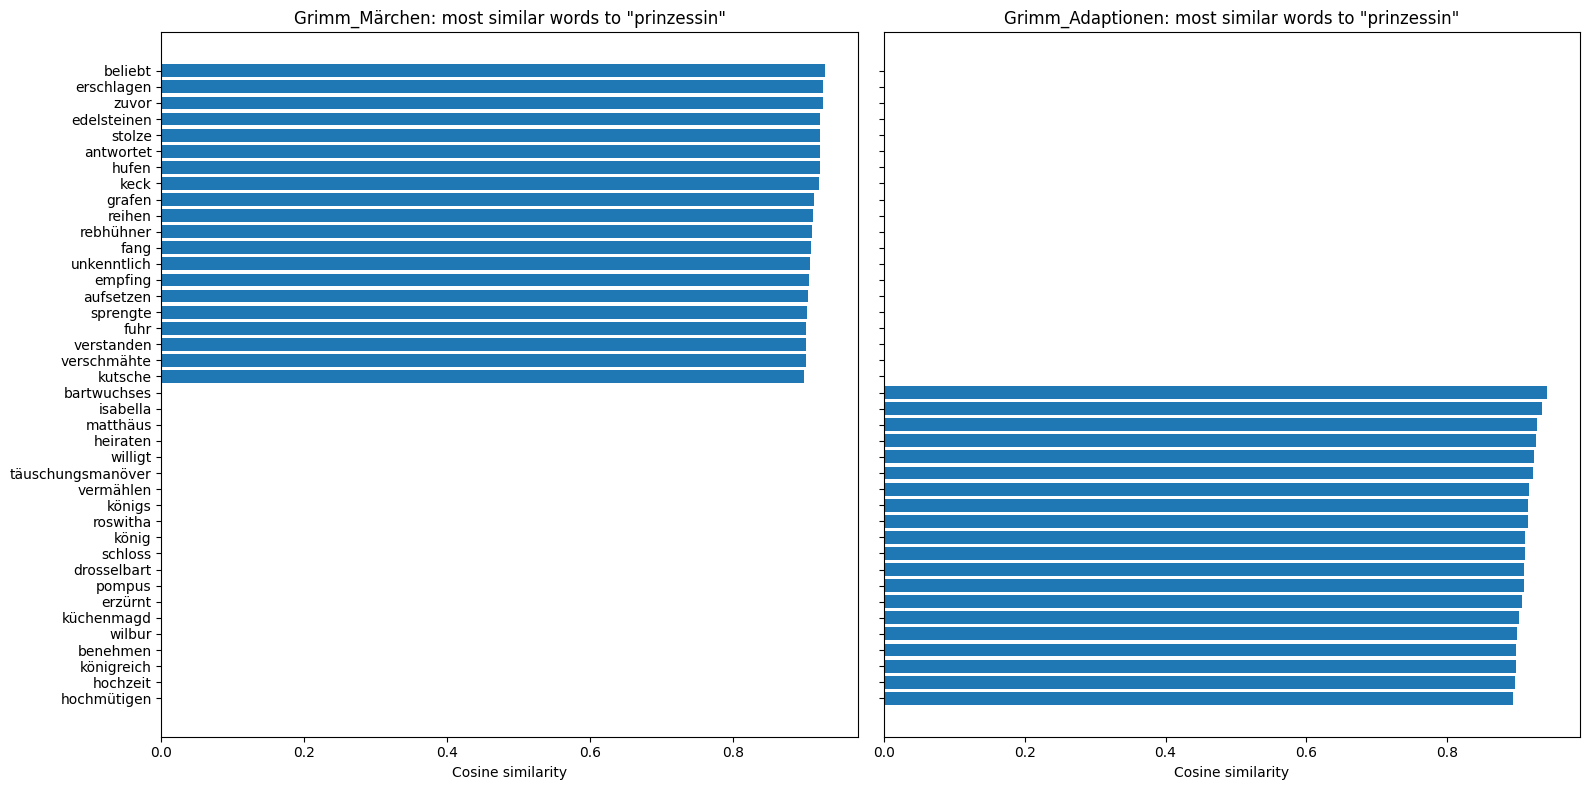

In [ ]:
# Define the reference word whose semantic neighbors we want to analyze
word = "prinzessin"

# 1) Retrieve the most similar words from both Word2Vec vocabularies
# model  → trained on original Grimm fairy tales
# model2 → trained on adapted fairy tales
sim1 = model.wv.most_similar(word, topn=20)
sim2 = model2.wv.most_similar(word, topn=20)

# 2) Convert the results into DataFrames for easier visualization
similar_words1 = pd.DataFrame(sim1, columns=["word", "similarity"])
similar_words2 = pd.DataFrame(sim2, columns=["word", "similarity"])

# 3) Create side-by-side plots to compare the semantic neighborhoods
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# ----- Model 1: Original Grimm fairy tales -----
# Horizontal bar chart showing words most similar to "prinzessin"
axes[0].barh(similar_words1["word"], similar_words1["similarity"])

# Add title and axis label
axes[0].set_title(f'Grimm_Märchen: most similar words to "{word}"')
axes[0].set_xlabel("Cosine similarity")

# ----- Model 2: Adapted fairy tales -----
# Horizontal bar chart for the adapted corpus
axes[1].barh(similar_words2["word"], similar_words2["similarity"])

# Invert y-axis so the most similar word appears at the top
axes[1].invert_yaxis()

# Add title and axis label
axes[1].set_title(f'Grimm_Adaptionen: most similar words to "{word}"')
axes[1].set_xlabel("Cosine similarity")

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the plots
plt.show()

In [ ]:
# Display the DataFrame containing the words most similar to the given word
# in the adapted fairy tales corpus (Word2Vec model trained on df2)
similar_words2

,word,similarity
0,bartwuchses,0.941214
1,isabella,0.934775
2,matthäus,0.927742
3,heiraten,0.926291
4,willigt,0.923242
5,täuschungsmanöver,0.922106
6,vermählen,0.915897
7,königs,0.914674
8,roswitha,0.914522
9,könig,0.910855


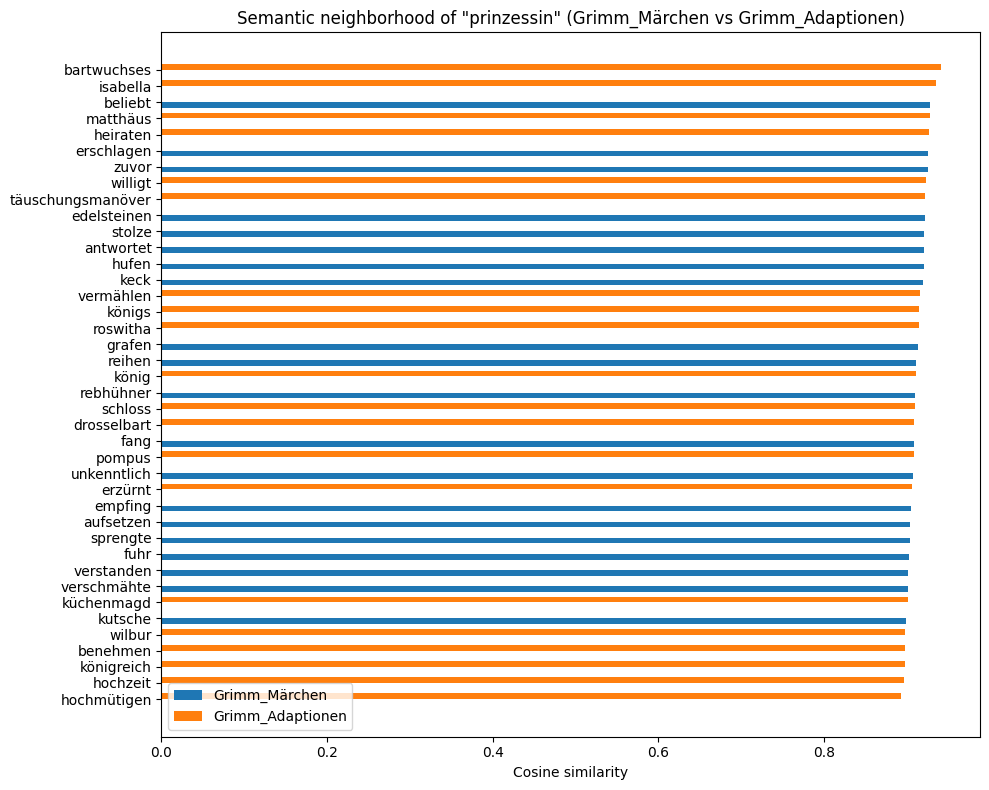

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Function to retrieve the semantic neighbors of a word
# from both Word2Vec models (original and adapted corpora)
def comparacion2(word):

    # Get the most similar words from the original Grimm corpus
    sim1 = model.wv.most_similar(word, topn=20)

    # Get the most similar words from the adapted fairy tales corpus
    sim2 = model2.wv.most_similar(word, topn=20)

    return sim1, sim2


# Define the reference word to analyze
word = "prinzessin"

# Retrieve semantic neighbors from both models
sim1, sim2 = comparacion2(word)


# Convert results into DataFrames
simi1 = pd.DataFrame(sim1, columns=["word", "sim_model1"])
simi2 = pd.DataFrame(sim2, columns=["word", "sim_model2"])


# Merge both vocabularies into a single comparison table
# Words appearing in only one model will receive similarity = 0
tabla = pd.merge(simi1, simi2, on="word", how="outer").fillna(0)


# Sort words by the highest similarity observed in either model
tabla["max_sim"] = tabla[["sim_model1", "sim_model2"]].max(axis=1)
tabla = tabla.sort_values("max_sim", ascending=True)


# ---------- Visualization: semantic neighborhood comparison ----------

# Create y positions for the words
y = np.arange(len(tabla))
h = 0.35

# Create the horizontal bar chart
plt.figure(figsize=(10, 8))

# Similarity values for the original Andersen corpus
plt.barh(y - h/2, tabla["sim_model1"], height=h, label="Grimm_Märchen")

# Similarity values for the adapted fairy tales corpus
plt.barh(y + h/2, tabla["sim_model2"], height=h, label="Grimm_Adaptionen")

# Add word labels on the y-axis
plt.yticks(y, tabla["word"])

# Add title and axis label
plt.xlabel("Cosine similarity")
plt.title(f'Semantic neighborhood of "{word}" (Grimm_Märchen vs Grimm_Adaptionen)')

# Add legend to distinguish the corpora
plt.legend()

# Adjust layout to avoid overlapping labels
plt.tight_layout()

# Display the plot
plt.show()

# 5. Comparison (2 Groups: Original Fairy Tales vs. Copilot)

In [ ]:
# Compute corpus-level statistics for two datasets:
# 1) Original Grimm fairy tales
# 2) Copilot-generated fairy tales
stats_df_1_3 = pd.DataFrame([
    corpus_stats(df,  "Grimm_Märchen"),
    corpus_stats(df3, "Grimm_Copilot")
])

# Set the corpus name as the index for easier comparison
stats_df_1_3 = stats_df_1_3.set_index("corpus")

# Display the statistics table
display(stats_df_1_3)

,n_texts,total_tokens,avg_tokens_per_text,median_tokens_per_text,min_tokens_text,max_tokens_text,unique_vocabulary,type_token_ratio
corpus,,,,,,,,
Grimm_Märchen,40,33110,827.750000,739.5,386,3466,6427,0.194111
Grimm_Copilot,87,22672,260.597701,278.0,55,471,5801,0.255866


In [ ]:
# Utility function to ensure the "tokens" column contains valid token lists
# This function fixes possible issues such as NaN values, None, or accidental strings
def _safe_tokens_col(dframe: pd.DataFrame, col="tokens"):

    # If the tokens column exists, use it; otherwise create empty token lists
    s = dframe[col] if col in dframe.columns else pd.Series([[]]*len(dframe))

    # Cleaning function applied to each element
    def fix(x):
        # If already a list of tokens, return it
        if isinstance(x, list):
            return x

        # Handle missing values (None or NaN)
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return []

        # If tokens were accidentally stored as a string, split them
        if isinstance(x, str):
            return x.split()

        # Default fallback
        return []

    # Apply cleaning to the entire column
    return s.apply(fix)


# ---------- 4) Length distributions (table per text) ----------

# Create a table with file names from the original Grimm corpus
lens1 = df[["file"]].copy()

# Add corpus identifier
lens1["corpus"] = "Grimm_Märchen"

# Compute the number of tokens per text
lens1["n_tokens"] = _safe_tokens_col(df, "tokens").apply(len)


# Repeat the same process for the Copilot-generated fairy tales
lens3 = df3[["file"]].copy()
lens3["corpus"] = "Grimm_Copilot"
lens3["n_tokens"] = _safe_tokens_col(df3, "tokens").apply(len)


# Combine both corpora into a single DataFrame
lengths_all = pd.concat([lens1, lens3], ignore_index=True)

# Display the table showing token counts for each text
display(lengths_all)

,file,corpus,n_tokens
0,1857_Grimm_Original_Grimm_Hänsel_und_Grethel.txt,Grimm_Märchen,1247
1,1857_Grimm_Original_Grimm_Der_treue_Johannes.txt,Grimm_Märchen,1277
2,1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusi...,Grimm_Märchen,540
3,1812_Grimm_Original_Grimm_König_Drosselbart.txt,Grimm_Märchen,711
4,1857_Grimm_Original_Grimm_Die_goldene_Gans.txt,Grimm_Märchen,675
...,...,...,...
122,2011_Grimm_Copilot_Wheeler_Der_gestiefelte_Kat...,Grimm_Copilot,360
123,1954_Grimm_Copilot_Surmann_Der_Froschkönig.txt,Grimm_Copilot,76
124,1953_Grimm_Copilot_Fitz_Brüderchen_und_Schwest...,Grimm_Copilot,142
125,2012_Grimm_Copilot_Bongartz_Allerleirauh.txt,Grimm_Copilot,306


/tmp/ipykernel_1532/2060335125.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=["Grimm_Märchen","Grimm_Copilot"])


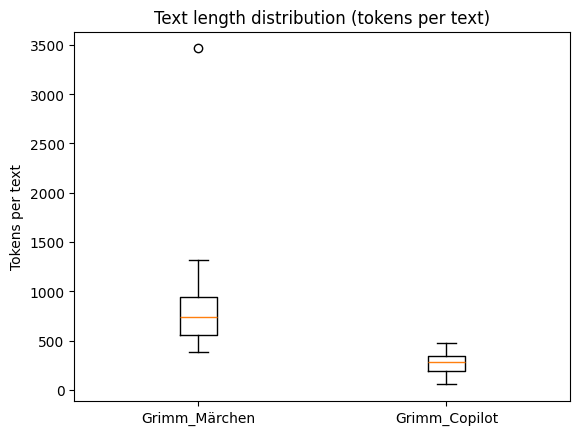

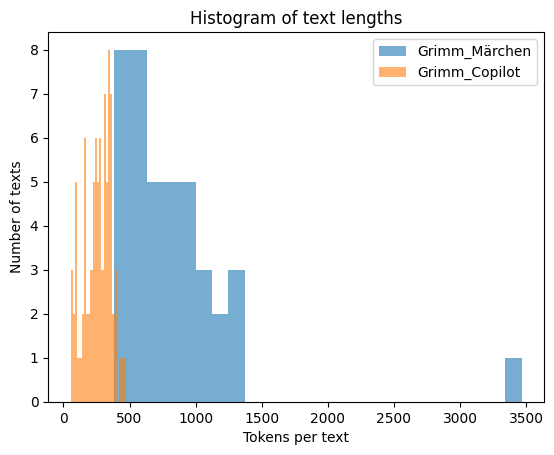

In [ ]:
# ---------- Plots: boxplot + histogram ----------

# Create a boxplot to compare the distribution of text lengths (number of tokens)
# between the original Andersen fairy tales and the Copilot-generated versions
plt.figure()

# Prepare the data arrays for each corpus
data_box = [
    lengths_all.loc[lengths_all["corpus"]=="Grimm_Märchen", "n_tokens"].to_numpy(),
    lengths_all.loc[lengths_all["corpus"]=="Grimm_Copilot", "n_tokens"].to_numpy(),
]

# Draw the boxplot showing the token-length distribution for each corpus
plt.boxplot(data_box, labels=["Grimm_Märchen","Grimm_Copilot"])

# Add title and axis label
plt.title("Text length distribution (tokens per text)")
plt.ylabel("Tokens per text")

# Display the plot
plt.show()


# ---------- Histogram comparison ----------

# Create a histogram to visualize how text lengths are distributed
# across both corpora
plt.figure()

# Histogram for the original Andersen fairy tales
plt.hist(data_box[0], bins=25, alpha=0.6, label="Grimm_Märchen")

# Histogram for the Copilot-generated fairy tales
plt.hist(data_box[1], bins=25, alpha=0.6, label="Grimm_Copilot")

# Add title and axis labels
plt.title("Histogram of text lengths")
plt.xlabel("Tokens per text")
plt.ylabel("Number of texts")

# Add legend to distinguish the corpora
plt.legend()

# Display the plot
plt.show()

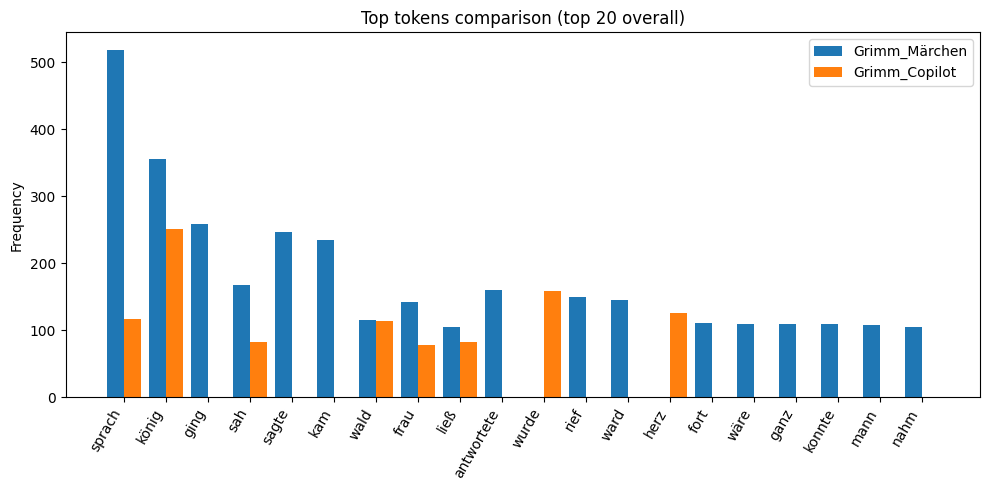

In [ ]:
# ---------- Top words comparison (side-by-side bar chart) ----------

# Number of most frequent tokens to analyze
topn = 20

# Retrieve the top tokens from each corpus
# tw1 → original Grimm fairy tales
# tw3 → Copilot-generated fairy tales
tw1 = top_words(df,  topn=topn).set_index("token")
tw3 = top_words(df3, topn=topn).set_index("token")

# Build a combined vocabulary containing the top tokens from both corpora
# dict.fromkeys() preserves order and removes duplicates
vocab_top1_3 = list(dict.fromkeys(list(tw1.index) + list(tw3.index)))

# Create a comparison table indexed by tokens
comp = pd.DataFrame(index=vocab_top1_3)

# Add frequency columns for each corpus
comp["Grimm_Märchen"] = tw1["freq"]
comp["Grimm_Copilot"] = tw3["freq"]

# Replace missing values with zero (tokens appearing in only one corpus)
comp = comp.fillna(0).astype(int)

# Compute total frequency across both corpora
# This helps identify the most prominent tokens overall
comp["total"] = comp["Grimm_Märchen"] + comp["Grimm_Copilot"]

# Keep only the tokens with the highest total frequency
comp_plot = comp.sort_values("total", ascending=False).head(topn).drop(columns=["total"])


# ---------- Visualization: side-by-side bar chart ----------

# Create the figure
plt.figure(figsize=(10, 5))

# Generate x-axis positions for the tokens
x = np.arange(len(comp_plot.index))

# Width of each bar
width = 0.4

# Plot frequencies for the original Grimm corpus
plt.bar(x - width/2, comp_plot["Grimm_Märchen"].values, width, label="Grimm_Märchen")

# Plot frequencies for the Copilot-generated corpus
plt.bar(x + width/2, comp_plot["Grimm_Copilot"].values, width, label="Grimm_Copilot")

# Add token labels on the x-axis
plt.xticks(x, comp_plot.index, rotation=60, ha="right")

# Add title and axis label
plt.title(f"Top tokens comparison (top {topn} overall)")
plt.ylabel("Frequency")

# Add legend to distinguish the corpora
plt.legend()

# Adjust layout so labels do not overlap
plt.tight_layout()

# Display the plot
plt.show()

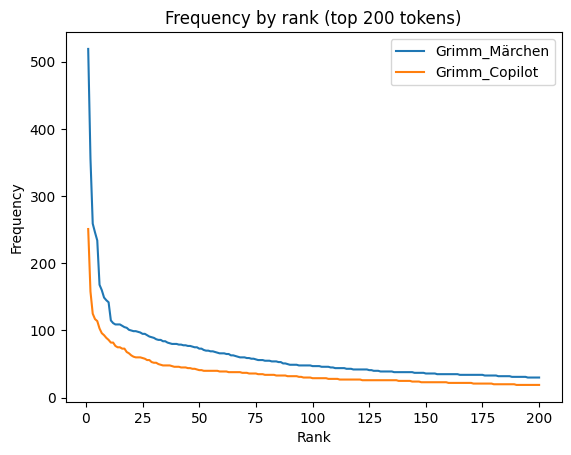

In [ ]:
# Function to compute the Zipf curve for a corpus
# It returns the rank of each token and its frequency
def zipf_curve(dframe: pd.DataFrame, name: str, topn=200):
    toks_series = _safe_tokens_col(dframe, "tokens")         # Retrieve a safe tokens column (ensures lists of tokens)
    c = Counter(t for toks in toks_series for t in toks)     # Count token frequencies across the corpus
    freqs = np.array([f for _, f in c.most_common(topn)])    # Extract the frequencies of the top-N most common tokens
    ranks = np.arange(1, len(freqs) + 1)                     # Create rank values (1 = most frequent word)
    return ranks, freqs, name                                # Return rank, frequency, and corpus name


# Compute Zipf curves for both corpora
# Original Grimm fairy tales
r1, f1, n1 = zipf_curve(df,  "Grimm_Märchen")

# Copilot-generated fairy tales
r3, f3, n3 = zipf_curve(df3, "Grimm_Copilot")


# ---------- Visualization: Zipf curves ----------


plt.figure() # Create the figure
plt.plot(r1, f1, label=n1) # Plot frequency vs rank for the original Andersen corpus
plt.plot(r3, f3, label=n3) # Plot frequency vs rank for the Copilot-generated corpus

# Add title and axis labels
plt.title("Frequency by rank (top 200 tokens)")
plt.xlabel("Rank")
plt.ylabel("Frequency")

# Add legend to distinguish the corpora
plt.legend()

# Display the plot
plt.show()


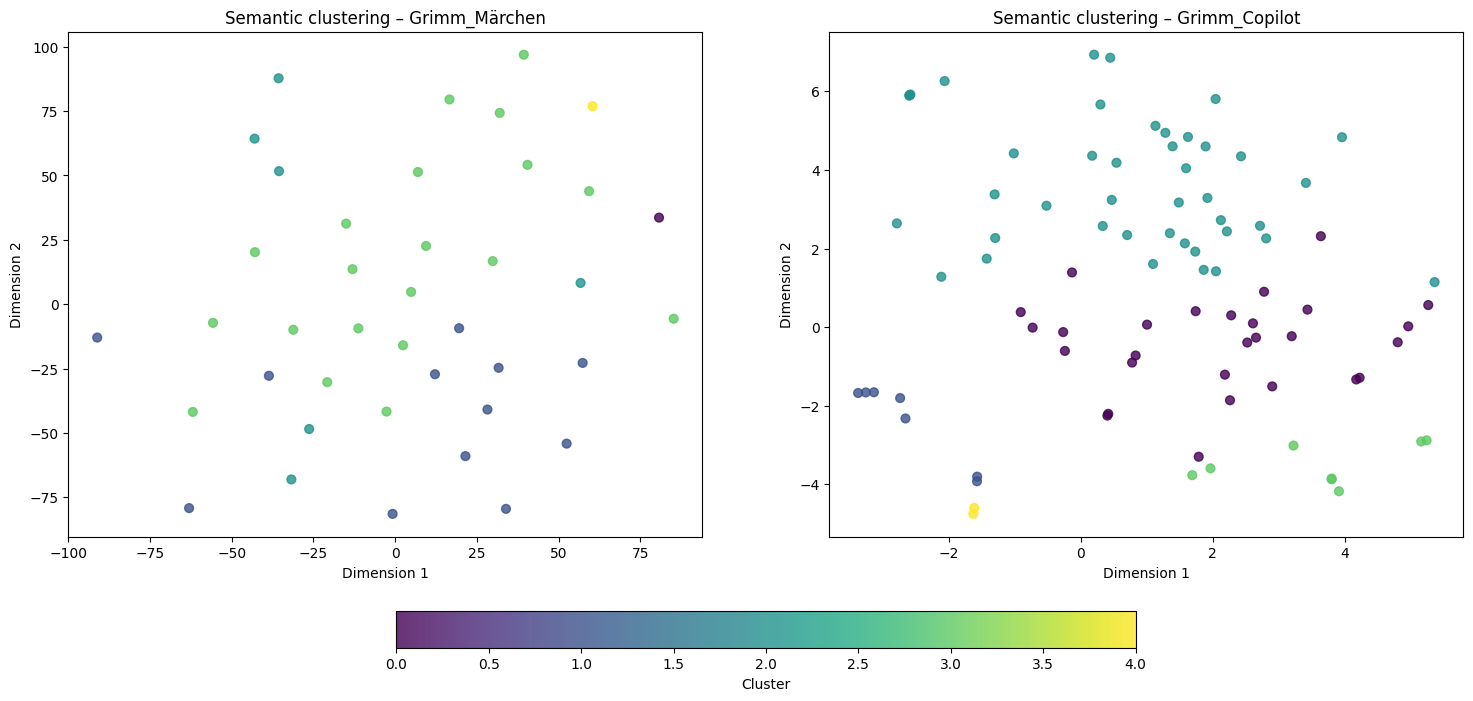

In [ ]:
# Create a figure with two subplots to compare the semantic clustering
# of the original Grimm corpus and the Copilot-generated corpus
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# -------- Group 1: Original Grimm fairy tales --------
# Scatter plot of the t-SNE projection colored by K-Means cluster
sc1 = axes[0].scatter(
    X1[:, 0],     # t-SNE dimension 1
    X1[:, 1],     # t-SNE dimension 2
    c=clusters,   # cluster labels from K-Means
    s=40,         # size of points
    alpha=0.8     # transparency for better readability
)

# Add title and axis labels
axes[0].set_title("Semantic clustering – Grimm_Märchen")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")


# -------- Group 2: Copilot-generated fairy tales --------
# Scatter plot of the t-SNE projection colored by K-Means cluster
sc3 = axes[1].scatter(
    X3[:, 0],     # t-SNE dimension 1
    X3[:, 1],     # t-SNE dimension 2
    c=clusters3,  # cluster labels from K-Means
    s=40,
    alpha=0.8
)

# Add title and axis labels
axes[1].set_title("Semantic clustering – Grimm_Copilot")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")


# -------- Shared horizontal colorbar --------
# The colorbar represents cluster membership across both plots
cbar = fig.colorbar(
    sc3,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.12
)

# Label the colorbar
cbar.set_label("Cluster")

# Display the figure
plt.show()

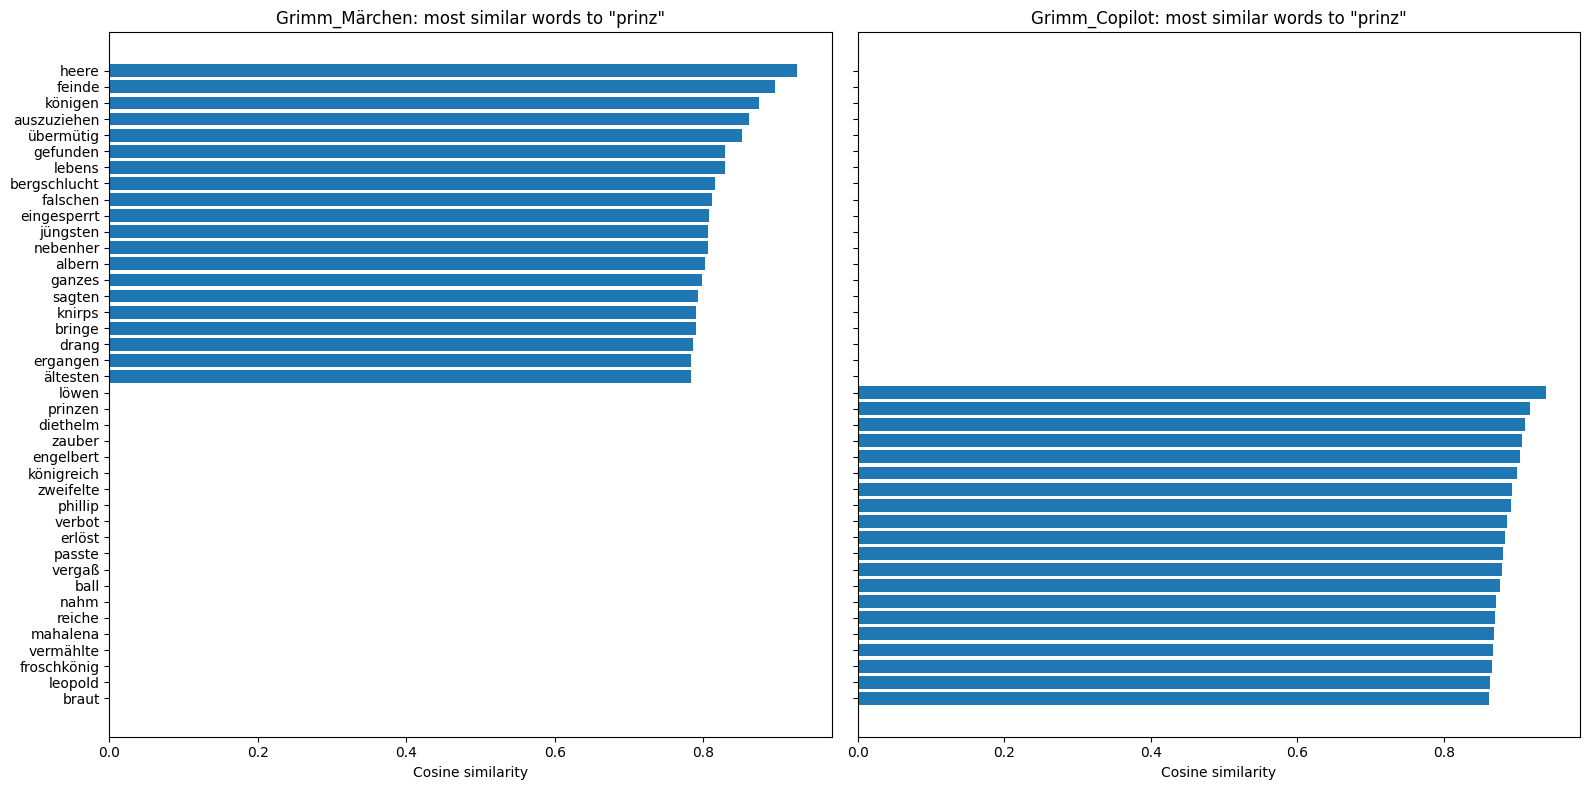

In [ ]:
# Define the reference word whose semantic neighbors will be analyzed
word = "prinz"

# 1) Retrieve the most similar words from both Word2Vec models
# model  → trained on the original Grimm fairy tales
# model3 → trained on the Copilot-generated fairy tales
sim1 = model.wv.most_similar(word, topn=20)
sim3 = model3.wv.most_similar(word, topn=20)

# 2) Convert the results into DataFrames for easier visualization
similar_words1 = pd.DataFrame(sim1, columns=["word", "similarity"])
similar_words3 = pd.DataFrame(sim3, columns=["word", "similarity"])

# 3) Create side-by-side plots to compare the semantic neighborhoods
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# ----- Model 1: Original Grimm fairy tales -----
# Horizontal bar chart showing words most similar to "prinz"
axes[0].barh(similar_words1["word"], similar_words1["similarity"])

# Add title and axis label
axes[0].set_title(f'Grimm_Märchen: most similar words to "{word}"')
axes[0].set_xlabel("Cosine similarity")

# ----- Model 3: Copilot-generated fairy tales -----
# Horizontal bar chart for the Copilot corpus
axes[1].barh(similar_words3["word"], similar_words3["similarity"])

# Invert the y-axis so the most similar word appears at the top
axes[1].invert_yaxis()

# Add title and axis label
axes[1].set_title(f'Grimm_Copilot: most similar words to "{word}"')
axes[1].set_xlabel("Cosine similarity")

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the plots
plt.show()

In [ ]:
# Display the DataFrame containing the words most semantically similar to "prinz"
# according to the Word2Vec model trained on the Copilot-generated fairy tales
similar_words3

,word,similarity
0,löwen,0.938856
1,prinzen,0.916895
2,diethelm,0.911196
3,zauber,0.906753
4,engelbert,0.904158
5,königreich,0.900162
6,zweifelte,0.892411
7,phillip,0.892013
8,verbot,0.886826
9,erlöst,0.883315


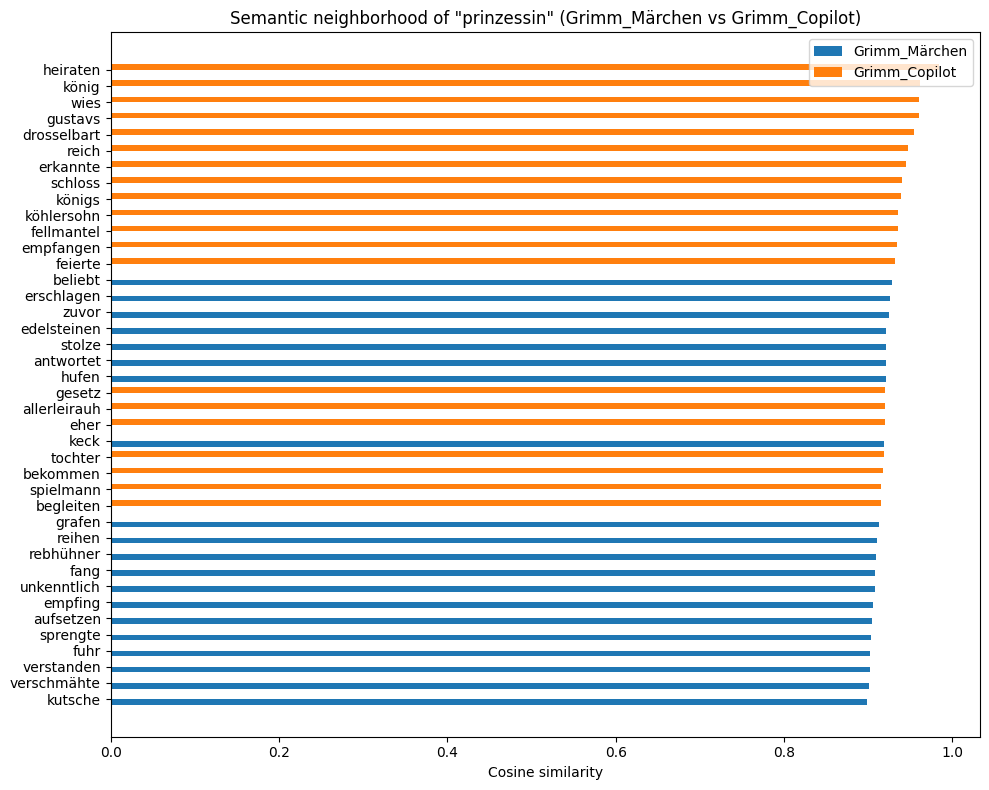

In [ ]:
# Function to retrieve semantic neighbors of a word from two Word2Vec models
# model  → trained on the original Grimm fairy tales
# model3 → trained on the Copilot-generated fairy tales
def comparacion2(word):
      sim1 = model.wv.most_similar(word, topn=20)  # Get the most similar words from the original corpus
      sim3 = model3.wv.most_similar(word, topn=20) # Get the most similar words from the Copilot-generated corpus
      return sim1, sim3


# Define the reference word to analyze
word = "prinzessin"

# Retrieve semantic neighbors from both models
sim1, sim3 = comparacion2(word)


# Convert the results into DataFrames
simi1 = pd.DataFrame(sim1, columns=["word", "sim_model1"])
simi3 = pd.DataFrame(sim3, columns=["word", "sim_model3"])


# Merge the vocabularies from both models
# Words appearing only in one model will receive similarity = 0
tabla = pd.merge(simi1, simi3, on="word", how="outer").fillna(0)


# Sort words by their maximum similarity in either model
# This helps highlight the most semantically relevant neighbors
tabla["max_sim"] = tabla[["sim_model1", "sim_model3"]].max(axis=1)
tabla = tabla.sort_values("max_sim", ascending=True)


# ---------- Visualization: semantic neighborhood comparison ----------

# Create y-axis positions for the words
y = np.arange(len(tabla))
h = 0.35

# Create the horizontal bar chart
plt.figure(figsize=(10, 8))

# Similarity scores for the original Grimm corpus
plt.barh(y - h/2, tabla["sim_model1"], height=h, label="Grimm_Märchen")

# Similarity scores for the Copilot-generated corpus
plt.barh(y + h/2, tabla["sim_model3"], height=h, label="Grimm_Copilot")

# Add word labels on the y-axis
plt.yticks(y, tabla["word"])

# Add title and axis label
plt.xlabel("Cosine similarity")
plt.title(f'Semantic neighborhood of "{word}" (Grimm_Märchen vs Grimm_Copilot)')

# Add legend to distinguish the corpora
plt.legend()

# Adjust layout to avoid overlapping labels
plt.tight_layout()

# Display the plot
plt.show()

# 5. Comparison (2 Groups: Adaptation vs. Copilot)

In [ ]:
# Compute corpus-level statistics for two datasets:
# 1) Adapted Grimm fairy tales
# 2) Copilot-generated fairy tales
stats_df2_3 = pd.DataFrame([
    corpus_stats(df2,  "Grimm_Adaptionen"),
    corpus_stats(df3, "Grimm_Copilot")
])

# Set the corpus name as the index for easier comparison
stats_df2_3 = stats_df2_3.set_index("corpus")

# Display the statistics table
display(stats_df2_3)

,n_texts,total_tokens,avg_tokens_per_text,median_tokens_per_text,min_tokens_text,max_tokens_text,unique_vocabulary,type_token_ratio
corpus,,,,,,,,
Grimm_Adaptionen,87,27362,314.505747,291.0,45,824,7293,0.266538
Grimm_Copilot,87,22672,260.597701,278.0,55,471,5801,0.255866


In [ ]:
# Utility function to ensure that the "tokens" column contains valid token lists
# This handles potential issues such as NaN values, None, or accidental strings
def _safe_tokens_col(dframe: pd.DataFrame, col="tokens"):

    # If the column exists, use it; otherwise create empty token lists
    s = dframe[col] if col in dframe.columns else pd.Series([[]]*len(dframe))

    # Cleaning function applied to each element
    def fix(x):
        if isinstance(x, list):  # If the element is already a list of tokens, return it
            return x
        if x is None or (isinstance(x, float) and np.isnan(x)):  # Handle missing values (None or NaN)
            return []
        if isinstance(x, str): # If tokens were accidentally stored as a string, split them
            return x.split()
        return [] # Default fallback

    # Apply cleaning function to the entire column
    return s.apply(fix)


# ---------- Length distributions (table per text) ----------

# Create a table with file names from the adapted Grimm fairy tales
lens2 = df2[["file"]].copy()

# Add a column identifying the corpus
lens2["corpus"] = "Grimm_Adaptionen"

# Compute the number of tokens for each text
lens2["n_tokens"] = _safe_tokens_col(df2, "tokens").apply(len)


# Repeat the same process for the Copilot-generated fairy tales
lens3 = df3[["file"]].copy()
lens3["corpus"] = "Grimm_Copilot"
lens3["n_tokens"] = _safe_tokens_col(df3, "tokens").apply(len)


# Combine both corpora into a single table
lengths_all2 = pd.concat([lens2, lens3], ignore_index=True)

# Display the table showing token counts for each text
display(lengths_all2)

,file,corpus,n_tokens
0,2014_Grimm_Wikipedia_Woolverton_Maleficent.txt,Grimm_Adaptionen,516
1,1949_Grimm_Wikipedia_Hamel_Hans_im_Glück.txt,Grimm_Adaptionen,59
2,2012_Grimm_Wikipedia_Keerl_Die_sechs_Schwäne.txt,Grimm_Adaptionen,363
3,1955_Grimm_Wikipedia_Lustig_Schneeweißchen_und...,Grimm_Adaptionen,147
4,1982_Grimm_Wikipedia_Hofman_Der_dritte_Prinz.txt,Grimm_Adaptionen,360
...,...,...,...
169,2011_Grimm_Copilot_Wheeler_Der_gestiefelte_Kat...,Grimm_Copilot,360
170,1954_Grimm_Copilot_Surmann_Der_Froschkönig.txt,Grimm_Copilot,76
171,1953_Grimm_Copilot_Fitz_Brüderchen_und_Schwest...,Grimm_Copilot,142
172,2012_Grimm_Copilot_Bongartz_Allerleirauh.txt,Grimm_Copilot,306


/tmp/ipykernel_1532/3171948804.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=["Grimm_Adaptionen","Grimm_Copilot"])


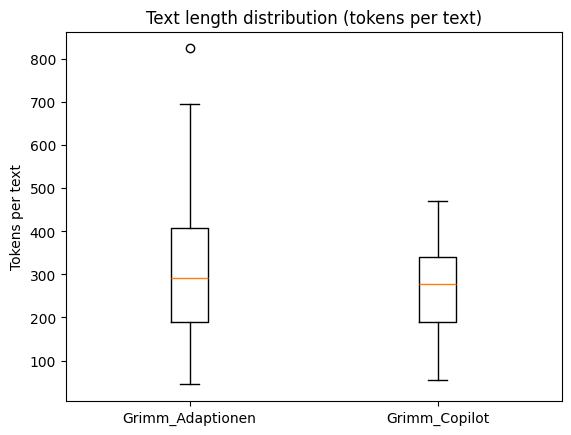

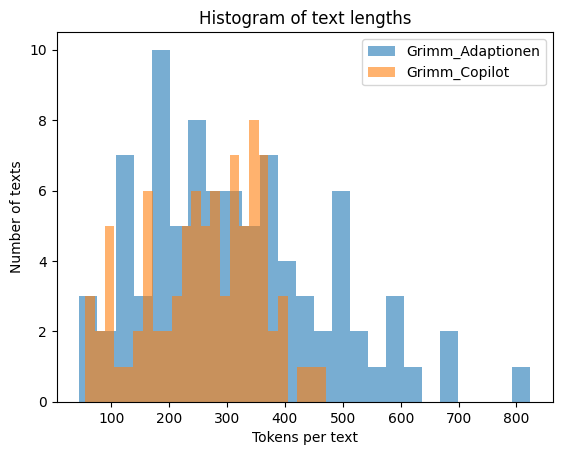

In [ ]:
# ---------- Plots: boxplot + histogram ----------

# Create a boxplot to compare the distribution of text lengths (in tokens)
# between the adapted Grimm fairy tales and the Copilot-generated texts
plt.figure()

# Prepare the data arrays for each corpus
data_box = [
    lengths_all2.loc[lengths_all2["corpus"]=="Grimm_Adaptionen", "n_tokens"].to_numpy(),
    lengths_all2.loc[lengths_all2["corpus"]=="Grimm_Copilot", "n_tokens"].to_numpy(),
]

# Draw the boxplot showing token-length distributions for both corpora
plt.boxplot(data_box, labels=["Grimm_Adaptionen","Grimm_Copilot"])

# Add title and axis label
plt.title("Text length distribution (tokens per text)")
plt.ylabel("Tokens per text")

# Display the boxplot
plt.show()


# ---------- Histogram comparison ----------

# Create a histogram to visualize how text lengths are distributed
# across both corpora
plt.figure()

# Histogram for the adapted fairy tales
plt.hist(data_box[0], bins=25, alpha=0.6, label="Grimm_Adaptionen")

# Histogram for the Copilot-generated fairy tales
plt.hist(data_box[1], bins=25, alpha=0.6, label="Grimm_Copilot")

# Add title and axis labels
plt.title("Histogram of text lengths")
plt.xlabel("Tokens per text")
plt.ylabel("Number of texts")

# Add legend to distinguish the corpora
plt.legend()

# Display the histogram
plt.show()

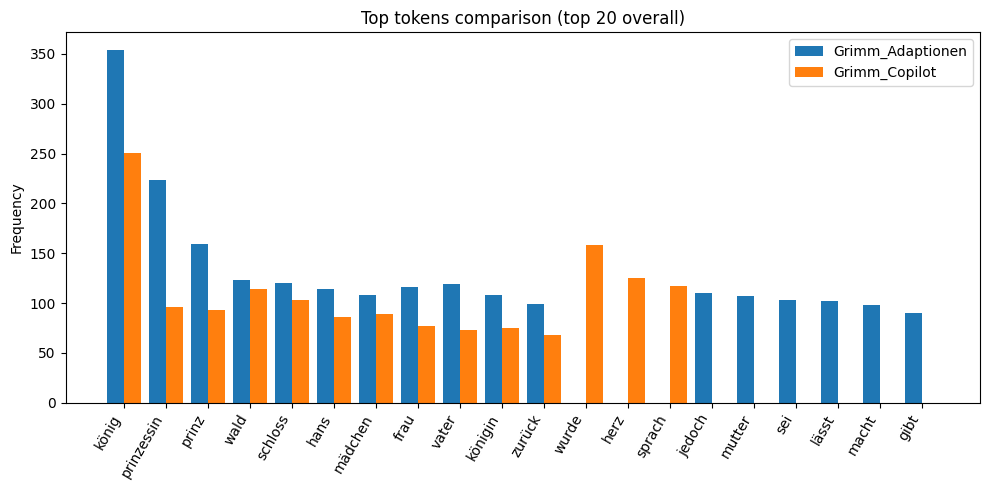

In [ ]:
# ---------- Top words comparison (side-by-side bar chart) ----------

# Number of most frequent tokens to analyze
topn = 20

# Retrieve the top tokens from each corpus
# tw2 → adapted Grimm fairy tales
# tw3 → Copilot-generated fairy tales
tw2 = top_words(df2, topn=topn).set_index("token")
tw3 = top_words(df3, topn=topn).set_index("token")

# Build a combined vocabulary containing the top tokens from both corpora
# dict.fromkeys() preserves order and removes duplicates
vocab_top = list(dict.fromkeys(list(tw2.index) + list(tw3.index)))

# Create a comparison DataFrame indexed by tokens
comp = pd.DataFrame(index=vocab_top)

# Add frequency columns for each corpus
comp["Grimm_Adaptionen"] = tw2["freq"]
comp["Grimm_Copilot"] = tw3["freq"]

# Replace missing values (tokens appearing in only one corpus) with zero
comp = comp.fillna(0).astype(int)

# Compute total frequency across both corpora
# This helps identify the most prominent tokens overall
comp["total"] = comp["Grimm_Adaptionen"] + comp["Grimm_Copilot"]

# Keep only the tokens with the highest total frequency
comp_plot = comp.sort_values("total", ascending=False).head(topn).drop(columns=["total"])


# ---------- Visualization: side-by-side bar chart ----------

# Create the figure
plt.figure(figsize=(10, 5))

# Generate x-axis positions for tokens
x = np.arange(len(comp_plot.index))

# Width of each bar
width = 0.4

# Plot frequencies for the adapted fairy tales corpus
plt.bar(x - width/2, comp_plot["Grimm_Adaptionen"].values, width, label="Grimm_Adaptionen")

# Plot frequencies for the Copilot-generated corpus
plt.bar(x + width/2, comp_plot["Grimm_Copilot"].values, width, label="Grimm_Copilot")

# Add token labels on the x-axis
plt.xticks(x, comp_plot.index, rotation=60, ha="right")

# Add title and axis label
plt.title(f"Top tokens comparison (top {topn} overall)")
plt.ylabel("Frequency")

# Add legend to distinguish the corpora
plt.legend()

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

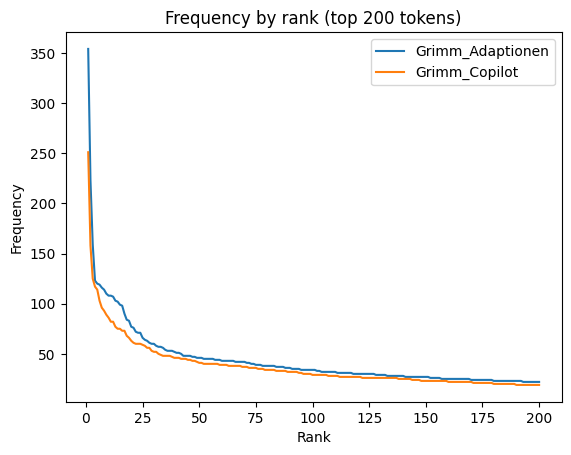

In [ ]:
# Function to compute the Zipf curve for a corpus
# It returns the rank of each token and its frequency
def zipf_curve(dframe: pd.DataFrame, name: str, topn=200):

    # Retrieve a cleaned tokens column (ensures each entry is a list of tokens)
    toks_series = _safe_tokens_col(dframe, "tokens")

    # Count token frequencies across the entire corpus
    c = Counter(t for toks in toks_series for t in toks)

    # Extract frequencies of the top-N most frequent tokens
    freqs = np.array([f for _, f in c.most_common(topn)])

    # Generate rank positions (1 = most frequent token)
    ranks = np.arange(1, len(freqs) + 1)

    # Return ranks, frequencies, and corpus name
    return ranks, freqs, name


# Compute Zipf curves for both corpora
# Adapted Grimm fairy tales
r2, f2, n2 = zipf_curve(df2, "Grimm_Adaptionen")

# Copilot-generated fairy tales
r3, f3, n3 = zipf_curve(df3, "Grimm_Copilot")


# ---------- Visualization: Zipf curves ----------

# Create the figure
plt.figure()

# Plot frequency vs rank for the adapted fairy tales corpus
plt.plot(r2, f2, label=n2)

# Plot frequency vs rank for the Copilot-generated corpus
plt.plot(r3, f3, label=n3)

# Add title and axis labels
plt.title("Frequency by rank (top 200 tokens)")
plt.xlabel("Rank")
plt.ylabel("Frequency")

# Add legend to distinguish the corpora
plt.legend()

# Display the plot
plt.show()

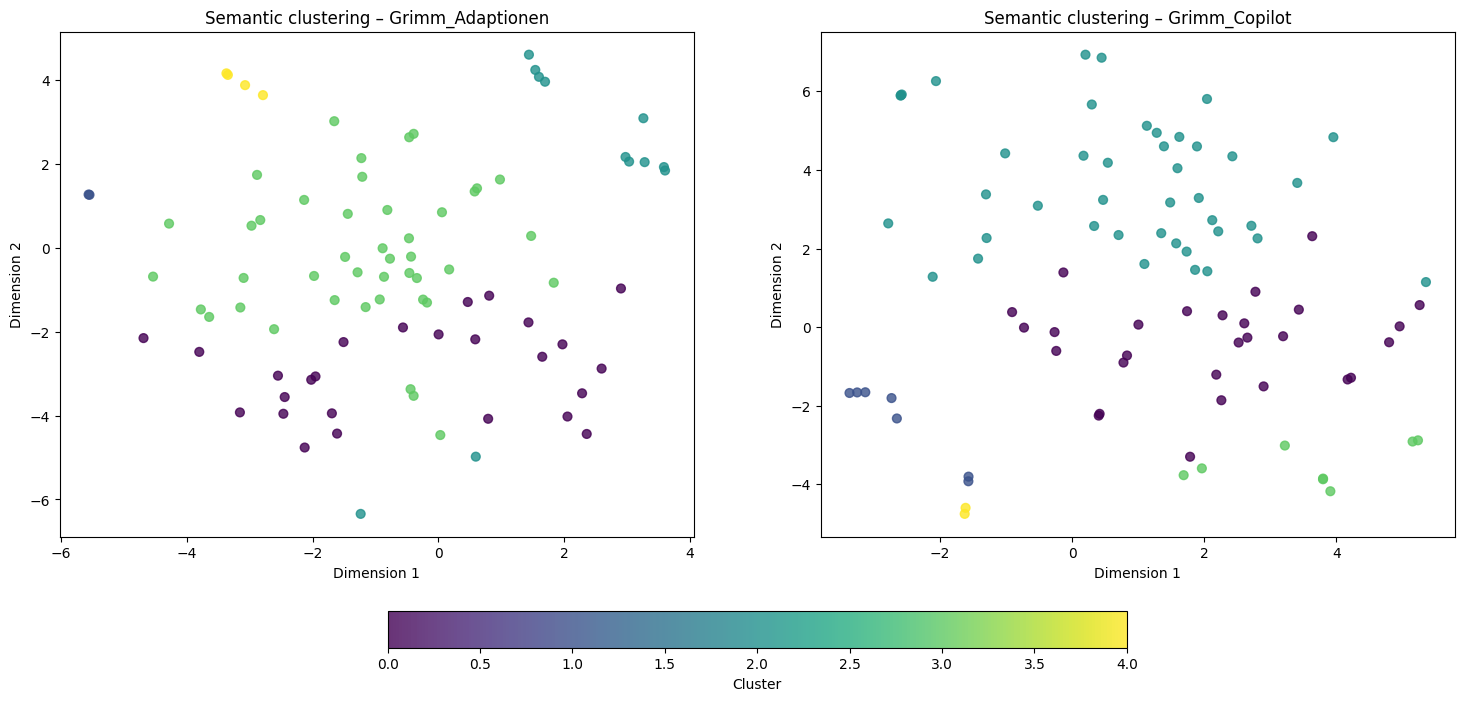

In [ ]:
# Create a figure with two subplots to compare semantic clustering
# between the adapted fairy tales and the Copilot-generated fairy tales
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# -------- Grimm_Adaptionen --------
# Scatter plot of the t-SNE projection of document embeddings
# Colors represent cluster membership obtained with KMeans
sc2 = axes[0].scatter(
    X2[:, 0],      # t-SNE dimension 1
    X2[:, 1],      # t-SNE dimension 2
    c=clusters2,   # cluster labels for adapted texts
    s=40,          # point size
    alpha=0.8      # transparency for readability
)

# Add title and axis labels
axes[0].set_title("Semantic clustering – Grimm_Adaptionen")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")


# --------Grimm_Copilot --------
# Scatter plot of the t-SNE projection for the Copilot-generated texts
sc3 = axes[1].scatter(
    X3[:, 0],      # t-SNE dimension 1
    X3[:, 1],      # t-SNE dimension 2
    c=clusters3,   # cluster labels for Copilot texts
    s=40,
    alpha=0.8
)

# Add title and axis labels
axes[1].set_title("Semantic clustering – Grimm_Copilot")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")


# -------- Shared horizontal colorbar --------
# The colorbar indicates the cluster index assigned by KMeans
cbar = fig.colorbar(
    sc3,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.12
)

# Label the colorbar
cbar.set_label("Cluster")

# Display the figure
plt.show()

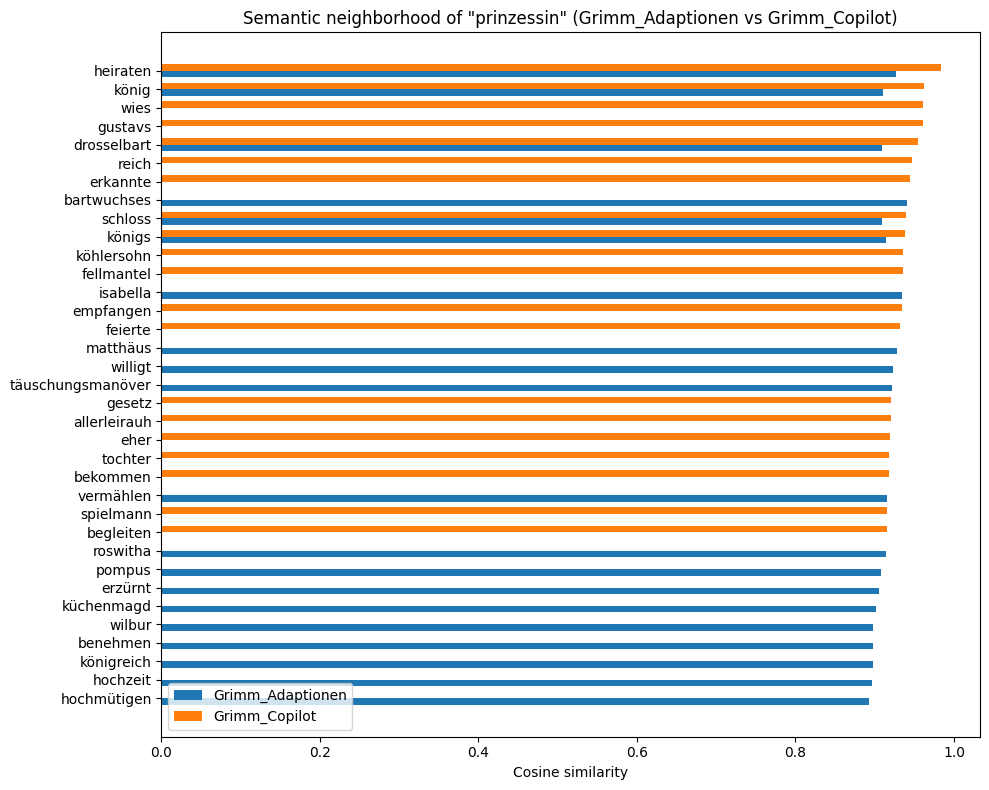

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to retrieve semantic neighbors of a word
# from the Word2Vec models trained on the adapted corpus and the Copilot corpus
def comparacion2(word):
    sim2 = model2.wv.most_similar(word, topn=20) # Most similar words in the adapted fairy tales corpus
    sim3 = model3.wv.most_similar(word, topn=20) # Most similar words in the Copilot-generated corpus
    return sim2, sim3


# Define the reference word
word = "prinzessin"

# Retrieve semantic neighbors from both models
sim2, sim3 = comparacion2(word)

# Convert results into DataFrames
simi2 = pd.DataFrame(sim2, columns=["word", "sim_model2"])
simi3 = pd.DataFrame(sim3, columns=["word", "sim_model3"])


# ---------- Merge vocabularies ----------

# Combine both word lists into one table
# Words that appear in only one model receive similarity = 0
tabla = pd.merge(simi2, simi3, on="word", how="outer").fillna(0)


# ---------- Sort by strongest semantic similarity ----------

# Compute the maximum similarity across the two models
tabla["max_sim"] = tabla[["sim_model2", "sim_model3"]].max(axis=1)

# Sort words to make the visualization easier to read
tabla = tabla.sort_values("max_sim", ascending=True)


# ---------- Visualization: semantic neighborhood comparison ----------

# Create y-axis positions
y = np.arange(len(tabla))
h = 0.35

# Create figure
plt.figure(figsize=(10, 8))

# Similarity scores for the adapted fairy tales corpus
plt.barh(y - h/2, tabla["sim_model2"], height=h, label="Grimm_Adaptionen")

# Similarity scores for the Copilot-generated corpus
plt.barh(y + h/2, tabla["sim_model3"], height=h, label="Grimm_Copilot")

# Add word labels
plt.yticks(y, tabla["word"])

# Axis labels and title
plt.xlabel("Cosine similarity")
plt.title(f'Semantic neighborhood of "{word}" (Grimm_Adaptionen vs Grimm_Copilot)')

# Legend
plt.legend()

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

In [ ]:
# Utility function to ensure that the "tokens" column contains valid token lists
# This handles possible issues such as missing values, NaN, or accidental strings
def _safe_tokens_col(dframe: pd.DataFrame, col="tokens"):

    # If the column exists, use it; otherwise create empty token lists
    s = dframe[col] if col in dframe.columns else pd.Series([[]] * len(dframe))

    # Cleaning function applied to each element
    def fix(x):
        if isinstance(x, list): # If the element is already a list of tokens, keep it unchanged
            return x
        if x is None or (isinstance(x, float) and np.isnan(x)): # Handle missing values (None or NaN)
            return []
        if isinstance(x, str): # If tokens were accidentally stored as a string, split them into words
            return x.split()
        return []  # Default fallback for unexpected data types

    # Apply the cleaning function to the entire column
    return s.apply(fix)


# Function to compute basic corpus-level statistics
def corpus_stats(dframe: pd.DataFrame, name: str):
    toks_series = _safe_tokens_col(dframe, "tokens")# Retrieve a cleaned tokens column
    lengths = toks_series.apply(len).to_numpy() # Compute the number of tokens in each document
    vocab = set(t for toks in toks_series for t in toks) # Build the vocabulary of unique tokens in the corpus
    total_tokens = int(lengths.sum()) # Total number of tokens in the corpus
    vocab_size = int(len(vocab)) # Number of unique words in the corpus
    ttr = (vocab_size / total_tokens) if total_tokens else np.nan # Type-token ratio (measure of lexical diversity)
    return { # Return all corpus statistics as a dictionary
        "corpus": name,
        "n_texts": int(len(dframe)),
        "total_tokens": total_tokens,
        "avg_tokens_per_text": float(np.mean(lengths)) if len(lengths) else np.nan,
        "median_tokens_per_text": float(np.median(lengths)) if len(lengths) else np.nan,
        "min_tokens_per_text": int(np.min(lengths)) if len(lengths) else np.nan,
        "max_tokens_per_text": int(np.max(lengths)) if len(lengths) else np.nan,
        "unique_vocabulary": int(len(vocab)),
        "type_token_ratio": float(ttr),
    }


# Function to retrieve the most frequent tokens in a corpus
def top_words(dframe: pd.DataFrame, topn=20):
    toks_series = _safe_tokens_col(dframe, "tokens") # Retrieve a cleaned tokens column
    c = Counter(t for toks in toks_series for t in toks) # Count token frequencies across the entire corpus
    return pd.DataFrame(c.most_common(topn), columns=["token", "freq"]) # Return the top-N most frequent tokens as a DataFrame


# Function to compute a Zipf curve for a corpus
# It returns token ranks and their corresponding frequencies
def zipf_curve(dframe: pd.DataFrame, name: str, topn=200):
    toks_series = _safe_tokens_col(dframe, "tokens") # Retrieve a cleaned tokens column
    c = Counter(t for toks in toks_series for t in toks) # Count token frequencies across the corpus
    freqs = np.array([f for _, f in c.most_common(topn)]) # Extract the frequencies of the top-N most frequent tokens
    ranks = np.arange(1, len(freqs) + 1) # Generate token ranks (1 = most frequent token)
    return ranks, freqs, name # Return ranks, frequencies, and corpus name

## 5. Comparison (3 Groups: Original Fairy tales vs. Adaptations vs. Copilot versions)

In [ ]:
# Create a dictionary that groups all corpora together
# This allows easy iteration and comparison across datasets
groups = {
    "Grimm_Märchen": df,        # Original Grimm fairy tales
    "Grimm_Adaptionen": df2,   # Adapted fairy tales
    "Grimm_Copilot": df3       # Copilot-generated fairy tales
}

In [ ]:
# Import numpy (used inside corpus_stats for numerical operations)
import numpy as np

# Compute corpus-level statistics for all corpora stored in the "groups" dictionary
# This iterates over each (name, DataFrame) pair
stats_df = pd.DataFrame([
    corpus_stats(dframe, name)
    for name, dframe in groups.items()
])

# Set the corpus name as the index for easier comparison
stats_df = stats_df.set_index("corpus")

# Display the resulting table
display(stats_df)

,n_texts,total_tokens,avg_tokens_per_text,median_tokens_per_text,min_tokens_per_text,max_tokens_per_text,unique_vocabulary,type_token_ratio
corpus,,,,,,,,
Grimm_Märchen,40,33110,827.750000,739.5,386,3466,6427,0.194111
Grimm_Adaptionen,87,27362,314.505747,291.0,45,824,7293,0.266538
Grimm_Copilot,87,22672,260.597701,278.0,55,471,5801,0.255866


,file,corpus,n_tokens
0,1857_Grimm_Original_Grimm_Hänsel_und_Grethel.txt,Grimm_Märchen,1247
1,1857_Grimm_Original_Grimm_Der_treue_Johannes.txt,Grimm_Märchen,1277
2,1857_Grimm_Original_Grimm_Die_Bremer_Stadtmusi...,Grimm_Märchen,540
3,1812_Grimm_Original_Grimm_König_Drosselbart.txt,Grimm_Märchen,711
4,1857_Grimm_Original_Grimm_Die_goldene_Gans.txt,Grimm_Märchen,675


/tmp/ipykernel_1532/3202860503.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=list(groups.keys()))


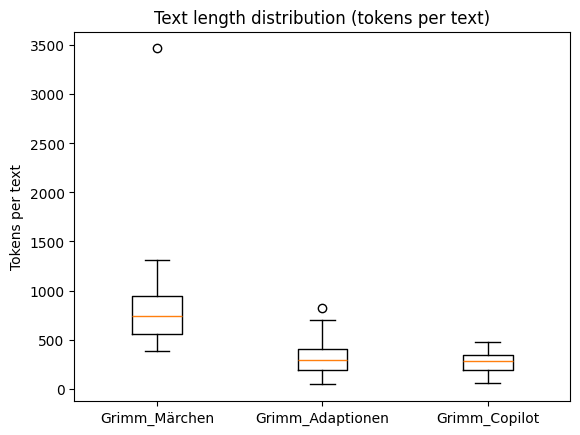

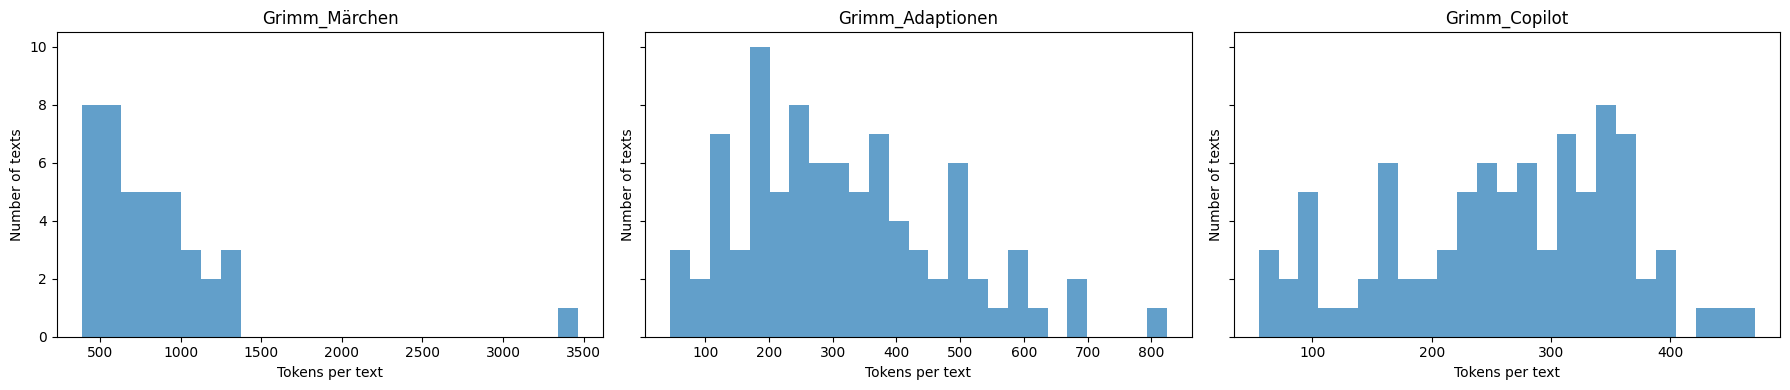

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# ---------- Build a unified table of text lengths ----------

# Create a combined DataFrame with token counts for all corpora
# This iterates over each corpus in the "groups" dictionary
lengths_all = pd.concat([
    pd.DataFrame({
        "file": gdf["file"].values,  # file name
        "corpus": name,              # corpus label
        "n_tokens": _safe_tokens_col(gdf, "tokens").apply(len).values  # token count per text
    })
    for name, gdf in groups.items()
], ignore_index=True)

# Display a preview of the table
display(lengths_all.head())


# ---------- Boxplot: compare text length distributions ----------

# Create a boxplot comparing token distributions across all corpora
plt.figure()

# Prepare data for each corpus
data_box = [
    lengths_all.loc[lengths_all["corpus"] == name, "n_tokens"].to_numpy()
    for name in groups.keys()
]

# Plot boxplot with one box per corpus
plt.boxplot(data_box, labels=list(groups.keys()))

# Add title and axis label
plt.title("Text length distribution (tokens per text)")
plt.ylabel("Tokens per text")

# Display the plot
plt.show()


# ---------- Histograms: one per corpus ----------

# Number of corpora
n = len(groups)

# Create subplots (one histogram per corpus)
fig, axes = plt.subplots(1, n, figsize=(6*n, 4), sharey=True)

# Ensure axes is iterable even if there is only one subplot
if n == 1:
    axes = [axes]

# Plot a histogram for each corpus
for ax, (name, _) in zip(axes, groups.items()):
    vals = lengths_all.loc[lengths_all["corpus"] == name, "n_tokens"].to_numpy() # Extract token counts for the current corpus
    ax.hist(vals, bins=25, alpha=0.7) # Plot histogram
    # Add title and axis labels
    ax.set_title(name)
    ax.set_xlabel("Tokens per text")
    ax.set_ylabel("Number of texts")

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plots
plt.show()

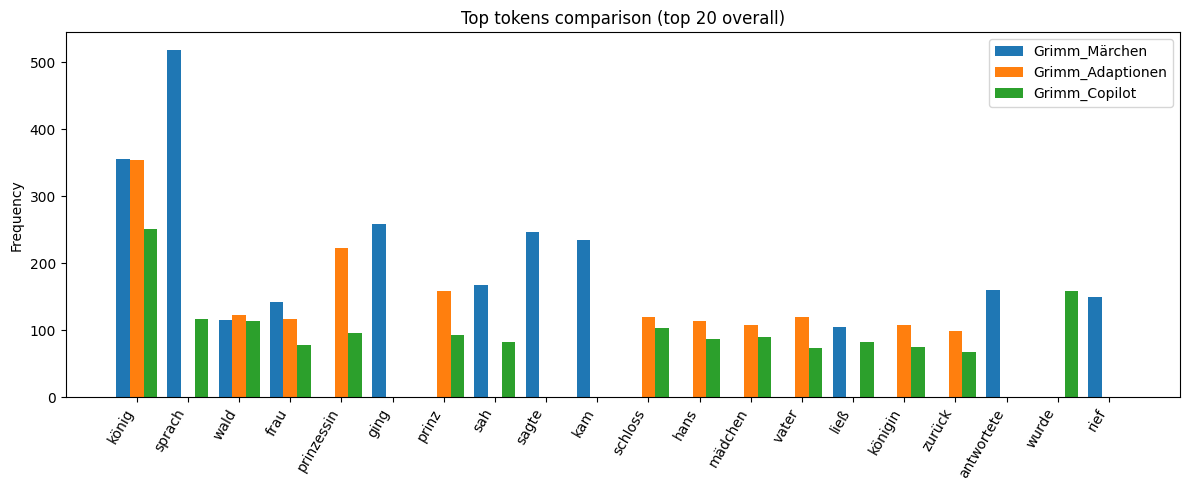

In [ ]:
# Import Counter for frequency calculations
from collections import Counter

# Number of top tokens to analyze
topn = 20

# Compute top tokens for each corpus
# Result: dictionary → {corpus_name: DataFrame of top tokens}
tops = {
    name: top_words(gdf, topn=topn).set_index("token")
    for name, gdf in groups.items()
}

# ---------- Build union of top tokens across all corpora ----------

# Collect all tokens from each corpus
tokens_union = []
for name in groups.keys():
    tokens_union += list(tops[name].index)

# Remove duplicates while preserving order
tokens_union = list(dict.fromkeys(tokens_union))


# ---------- Create comparison table ----------

# Initialize DataFrame indexed by all tokens
comp = pd.DataFrame(index=tokens_union)

# Add frequency column for each corpus
for name in groups.keys():
    comp[name] = tops[name]["freq"]

# Replace missing values (tokens not present in some corpora) with zero
comp = comp.fillna(0).astype(int)

# Compute total frequency across all corpora
comp["total"] = comp.sum(axis=1)

# Keep only the most frequent tokens overall
comp_plot = comp.sort_values("total", ascending=False).head(topn).drop(columns=["total"])


# ---------- Visualization: grouped bar chart ----------

# Create figure
plt.figure(figsize=(12, 5))

# Generate x-axis positions
x = np.arange(len(comp_plot.index))

# Adjust bar width depending on number of corpora
width = 0.8 / len(groups)

# Plot bars for each corpus (side-by-side)
for j, name in enumerate(groups.keys()):
    plt.bar(
        x + (j - (len(groups)-1)/2) * width,  # shift bars for grouping
        comp_plot[name].values,
        width,
        label=name
    )

# Add token labels on x-axis
plt.xticks(x, comp_plot.index, rotation=60, ha="right")

# Add title and axis label
plt.title(f"Top tokens comparison (top {topn} overall)")
plt.ylabel("Frequency")

# Add legend
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Display plot
plt.show()

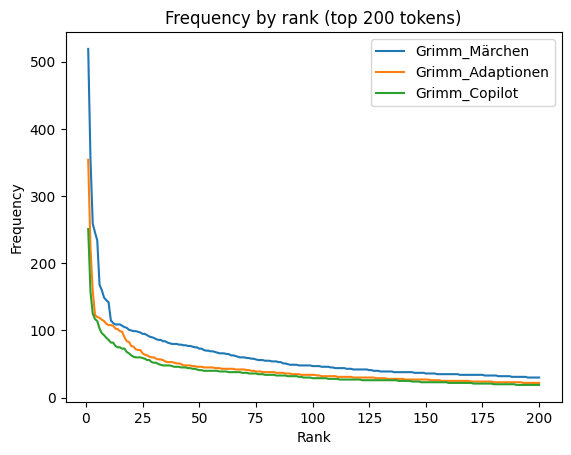

In [ ]:
# Create a figure to compare Zipf curves across all corpora
plt.figure()

# Iterate over each corpus in the groups dictionary
for name, gdf in groups.items():

    # Compute rank-frequency data using the Zipf curve function
    r, f, _ = zipf_curve(gdf, name, topn=200)

    # Plot the Zipf curve for the current corpus
    plt.plot(r, f, label=name)

# Add title and axis labels
plt.title("Frequency by rank (top 200 tokens)")
plt.xlabel("Rank")
plt.ylabel("Frequency")

# Add legend to distinguish the corpora
plt.legend()

# Display the plot
plt.show()


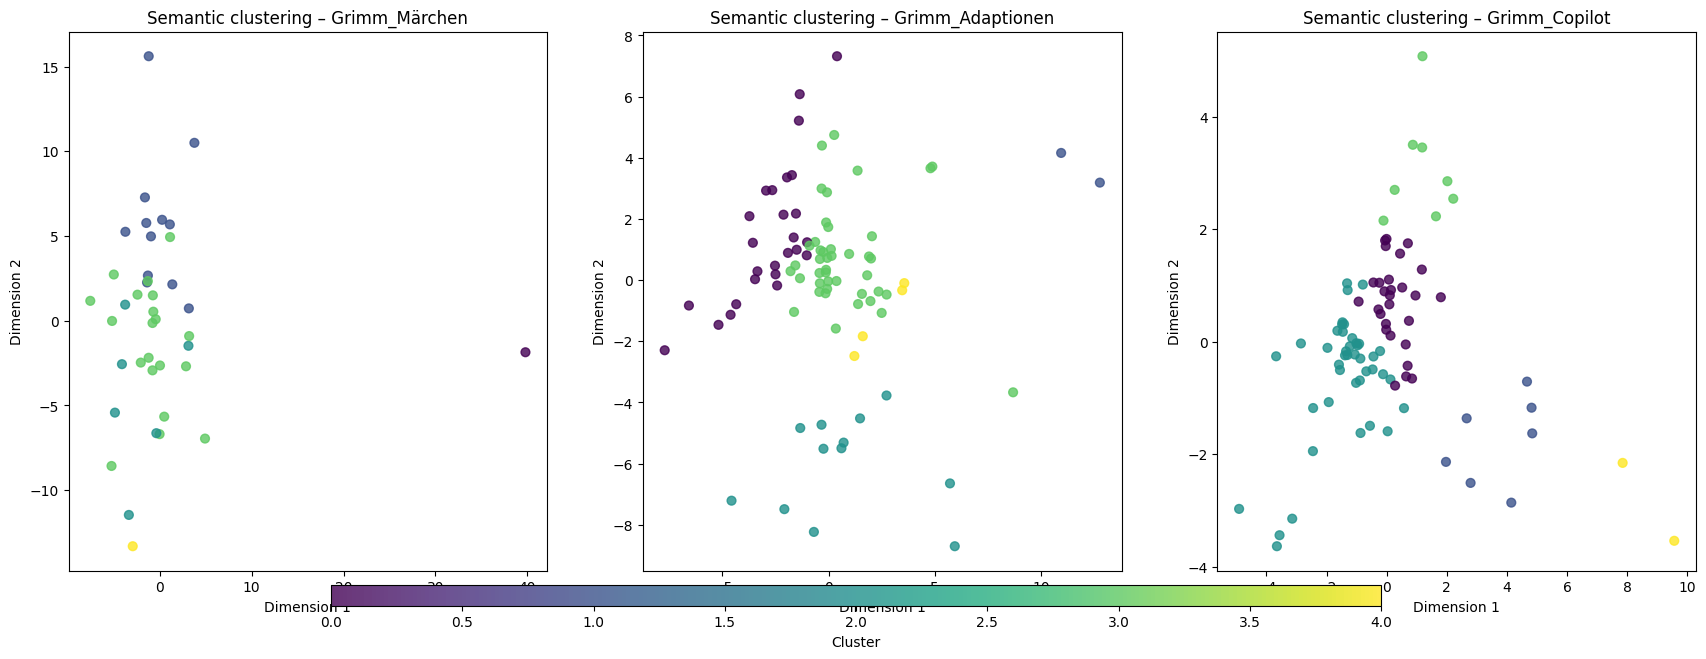

In [ ]:
# Import required libraries
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# Function to project Doc2Vec document embeddings into 2D and perform clustering
def project_and_cluster_doc2vec(doc2vec_model, k=5, seed=42):

    # Build matrix of document vectors (one vector per document)
    X = np.vstack([
        doc2vec_model.dv[tag]
        for tag in doc2vec_model.dv.index_to_key
    ])

    # Reduce dimensionality to 2D using PCA (for visualization)
    X_2d = PCA(n_components=2, random_state=seed).fit_transform(X)

    # Apply KMeans clustering on the original high-dimensional vectors
    clusters = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init="auto"
    ).fit_predict(X)

    return X_2d, clusters


# Apply the function to each corpus
X1, clusters1 = project_and_cluster_doc2vec(model,  k=5)   # Original Grimm
X2, clusters2 = project_and_cluster_doc2vec(model2, k=5)   # Adapted tales
X3, clusters3 = project_and_cluster_doc2vec(model3, k=5)   # Copilot tales


# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Prepare lists for iteration
X_list = [X1, X2, X3]                    # 2D projections
C_list = [clusters1, clusters2, clusters3]  # cluster labels
names  = ["Grimm_Märchen", "Grimm_Adaptionen", "Grimm_Copilot"]

# Create subplots (one for each corpus)
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Plot each corpus in its own subplot
for ax, X, C, name in zip(axes, X_list, C_list, names):

    # Scatter plot of document embeddings
    sc = ax.scatter(
        X[:, 0],    # PCA dimension 1
        X[:, 1],    # PCA dimension 2
        c=C,        # cluster labels
        s=40,       # point size
        alpha=0.8   # transparency
    )

    # Add title and axis labels
    ax.set_title(f"Semantic clustering – {name}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")


# ---------- Shared horizontal colorbar ----------

# Add a colorbar below all plots
cbar_ax = fig.add_axes([0.25, 0.06, 0.5, 0.03])

# Create colorbar using the last scatter plot
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal")

# Label the colorbar
cbar.set_label("Cluster")

# Display the figure
plt.show()



B. Conceptual Deplacement

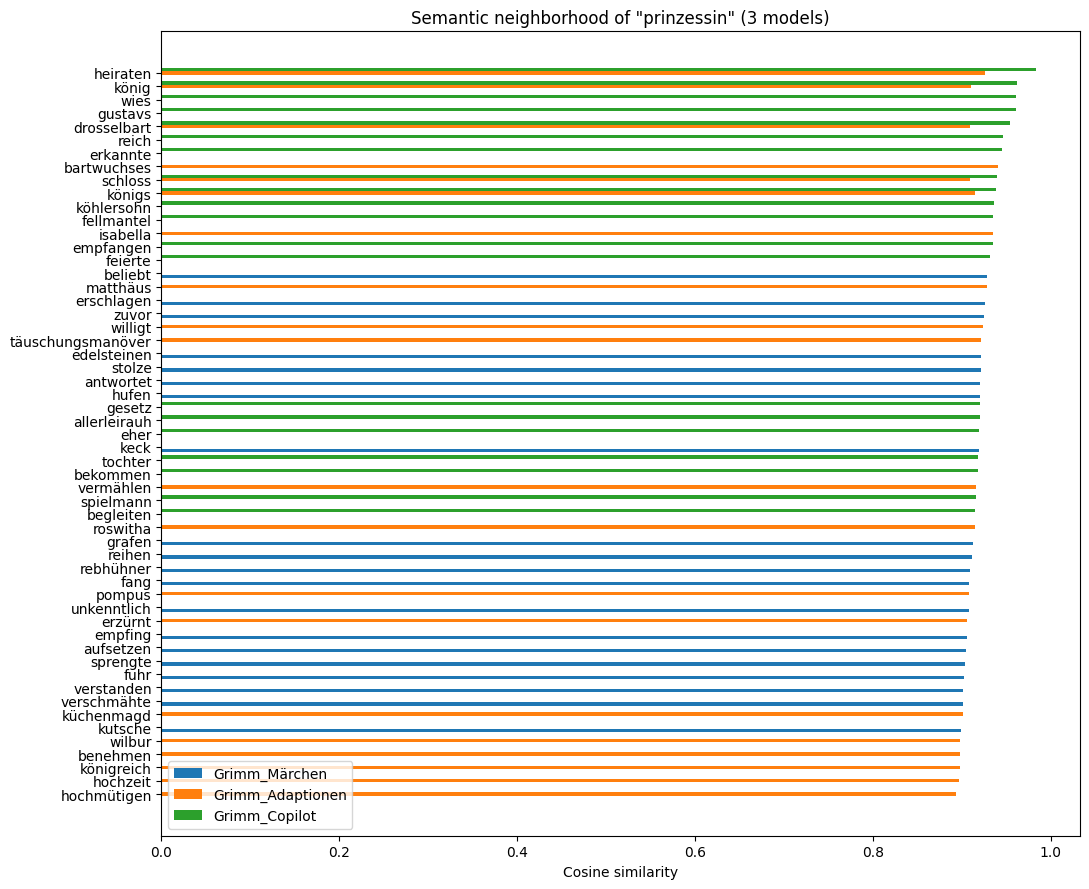

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select the reference word to analyze
word = "prinzessin"

# Retrieve the most similar words from each Word2Vec model
# model  → original Andersen fairy tales
# model2 → adapted fairy tales
# model3 → Copilot-generated fairy tales
sim1 = model.wv.most_similar(word, topn=20)
sim2 = model2.wv.most_similar(word, topn=20)
sim3 = model3.wv.most_similar(word, topn=20)

# Convert results into DataFrames
d1 = pd.DataFrame(sim1, columns=["word", "m1"])  # original corpus
d2 = pd.DataFrame(sim2, columns=["word", "m2"])  # adapted corpus
d3 = pd.DataFrame(sim3, columns=["word", "m3"])  # Copilot corpus

# ---------- Merge semantic neighborhoods ----------

# Combine all vocabularies into a single table
# Words not present in a model receive similarity = 0
dfm = (
    d1.merge(d2, on="word", how="outer")
      .merge(d3, on="word", how="outer")
      .fillna(0)
)

# Compute the maximum similarity across the three models
# This helps identify the most relevant words overall
dfm["max"] = dfm[["m1", "m2", "m3"]].max(axis=1)

# Sort words for visualization (lowest → highest similarity)
dfm = dfm.sort_values("max", ascending=True)


# ---------- Visualization: semantic comparison across 3 models ----------

# Create y-axis positions
y = np.arange(len(dfm))
h = 0.25  # bar height

# Create the figure
plt.figure(figsize=(11, 9))

# Plot similarity scores for each corpus
plt.barh(y - h, dfm["m1"], height=h, label="Grimm_Märchen")
plt.barh(y,     dfm["m2"], height=h, label="Grimm_Adaptionen")
plt.barh(y + h, dfm["m3"], height=h, label="Grimm_Copilot")

# Add word labels on the y-axis
plt.yticks(y, dfm["word"])

# Add axis label and title
plt.xlabel("Cosine similarity")
plt.title(f'Semantic neighborhood of "{word}" (3 models)')

# Add legend
plt.legend()

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


# 0. SHARED — Imports, configuration, training, alignment

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from gensim.models import Word2Vec
from scipy.linalg import orthogonal_procrustes

# ── Consistent colour palette for the 3 corpora ─────────────────
COLORS = {
    "Originals":    "#1D9E75",  # teal
    "Wikipedia":    "#BA7517",  # amber
    "AI (Copilot)": "#D85A30",  # coral
}

# ── Shared hyperparameters ───────────────────────────────────────
PARAMS = dict(
    vector_size=200,
    window=5,
    min_count=2,      # words with ≥2 occurrences enter the vocabulary
    workers=4,
    sg=1,             # Skip-gram (better suited for small corpora)
    epochs=200,
    seed=42,
)

# ────────────────────────────────────────────────────────────────
# S1. MODEL TRAINING
#     One Word2Vec model per corpus, identical hyperparameters
# ────────────────────────────────────────────────────────────────

print("=" * 60)
print("  SHARED — Training Word2Vec models")
print("=" * 60)

model_orig = Word2Vec(sentences=df["tokens"].tolist(),  **PARAMS)
model_wiki = Word2Vec(sentences=df2["tokens"].tolist(), **PARAMS)
model_ia   = Word2Vec(sentences=df3["tokens"].tolist(), **PARAMS)

print(f"  Vocabulary — originals : {len(model_orig.wv)}")
print(f"  Vocabulary — Wikipedia : {len(model_wiki.wv)}")
print(f"  Vocabulary — AI        : {len(model_ia.wv)}")

  SHARED — Training Word2Vec models
  Vocabulary — originals : 3189
  Vocabulary — Wikipedia : 3203
  Vocabulary — AI        : 2700


In [ ]:

# ────────────────────────────────────────────────────────────────
# S2. ORTHOGONAL ALIGNMENT (Procrustes)
#     Aligns Wikipedia and AI to the Originals' vector space.
#     Required before any cross-corpus vector comparison.
# ────────────────────────────────────────────────────────────────

def align_models(model_ref, model_target):
    """
    Computes the orthogonal rotation matrix that maps model_target
    onto model_ref's space using shared vocabulary as anchors.
    Returns a dict {word: aligned_vector} for model_target.
    """
    shared_vocab = list(
        set(model_ref.wv.key_to_index) & set(model_target.wv.key_to_index)
    )
    if len(shared_vocab) < 50:
        print(f"  ⚠ Only {len(shared_vocab)} shared words — Procrustes may be unstable.")

    A = np.array([model_ref.wv[w]    for w in shared_vocab])  # reference
    B = np.array([model_target.wv[w] for w in shared_vocab])  # to align

    R, _ = orthogonal_procrustes(B, A)  # minimises ||B·R - A||_F

    aligned_vectors = {w: model_target.wv[w] @ R for w in model_target.wv.key_to_index}
    return aligned_vectors, len(shared_vocab)

print("\nAligning vector spaces (Procrustes)...")
vecs_wiki_aligned, n1 = align_models(model_orig, model_wiki)
vecs_ia_aligned,   n2 = align_models(model_orig, model_ia)
print(f"  Orig–Wiki : {n1} shared words used for alignment")
print(f"  Orig–AI   : {n2} shared words used for alignment")
print("\n✓ Models trained and aligned. Proceeding to Step 1.\n")


Aligning vector spaces (Procrustes)...
  Orig–Wiki : 1242 shared words used for alignment
  Orig–AI   : 1391 shared words used for alignment

✓ Models trained and aligned. Proceeding to RQ1.



# 1. Vocabulary-level analysis (Semantic conservation, shift, and disappearance across 3 corpora)

Which keywords are conserved, shifted, or lost?


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 1-1. Keywords
# ────────────────────────────────────────────────────────────────

keywords = [
    # Archetypal characters
    "prinzessin", "prinz", "könig", "königin", "diener", "hexe",
    "teufel", "riese", "zauberer", "bauer",
    # Values and emotions
    "gut", "böse", "liebe", "glück", "angst", "mut", "verlangen",
    "trauer", "schönheit", "stolz",
    # Magical world
    "zauber", "garten", "feuer", "wald", "sage",
    "nacht", "traum", "geist", "höhle", "meer",
    # Spiritual / moral elements (candidates for disappearance)
    "herz", "erlösung", "gott", "himmel", "tod", "engel",
    "schuld", "verwünscht", "gnade", "kirche",
]

keywords = [w for w in keywords if w in model_orig.wv]
print(f"\n  {len(keywords)} keywords found in original corpus")


  40 keywords found in original corpus


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 1-2. Classification functions
# ────────────────────────────────────────────────────────────────

def jaccard_neighbours(model_ref, vecs_target, word, topn=10):
    """Jaccard index between top-N neighbours in two aligned spaces."""
    if word not in model_ref.wv or word not in vecs_target:
        return None
    neighbours_ref = set(w for w, _ in model_ref.wv.most_similar(word, topn=topn))
    vec_q = vecs_target[word]
    sims  = {
        w: np.dot(vec_q, vec) / (np.linalg.norm(vec_q) * np.linalg.norm(vec) + 1e-9)
        for w, vec in vecs_target.items() if w != word
    }
    neighbours_target = set(sorted(sims, key=sims.get, reverse=True)[:topn])
    intersection = neighbours_ref & neighbours_target
    union        = neighbours_ref | neighbours_target
    return len(intersection) / len(union) if union else 0.0

def aligned_cosine_distance(model_ref, vecs_target, word):
    """Cosine distance between a word's vector in ref vs aligned space."""
    if word not in model_ref.wv or word not in vecs_target:
        return None
    v_ref    = model_ref.wv[word]
    v_target = vecs_target[word]
    cos = np.dot(v_ref, v_target) / (np.linalg.norm(v_ref) * np.linalg.norm(v_target) + 1e-9)
    return 1 - cos

def classify(j, d, exists):
    if not exists or j is None:            return "disappearance"
    if j >= 0.4:                           return "conservation"
    if d is not None and d <= 0.3:         return "conservation"
    return "shift"

In [ ]:

# ────────────────────────────────────────────────────────────────
# Step 1-3. Build results table
# ────────────────────────────────────────────────────────────────

rows = []
for word in keywords:
    in_orig = word in model_orig.wv
    in_wiki = word in model_wiki.wv
    in_ia   = word in model_ia.wv

    j_wiki = jaccard_neighbours(model_orig, vecs_wiki_aligned, word) if (in_orig and in_wiki) else None
    j_ia   = jaccard_neighbours(model_orig, vecs_ia_aligned,   word) if (in_orig and in_ia)   else None
    d_wiki = aligned_cosine_distance(model_orig, vecs_wiki_aligned, word) if (in_orig and in_wiki) else None
    d_ia   = aligned_cosine_distance(model_orig, vecs_ia_aligned,   word) if (in_orig and in_ia)   else None

    rows.append({
        "word":          word,
        "in_originals":  in_orig,
        "in_wikipedia":  in_wiki,
        "in_ai":         in_ia,
        "jaccard_wiki":  round(j_wiki, 3) if j_wiki is not None else np.nan,
        "jaccard_ia":    round(j_ia,   3) if j_ia   is not None else np.nan,
        "cos_dist_wiki": round(d_wiki, 3) if d_wiki is not None else np.nan,
        "cos_dist_ia":   round(d_ia,   3) if d_ia   is not None else np.nan,
        "category_wiki": classify(j_wiki, d_wiki, in_wiki),
        "category_ia":   classify(j_ia,   d_ia,   in_ia),
    })

rq1_results = pd.DataFrame(rows)
print("\n── Step 1 results ──────────────────────────────────────")
print(rq1_results[["word","category_wiki","category_ia","jaccard_wiki","jaccard_ia"]].to_string(index=False))


── Step 1 results ──────────────────────────────────────
      word category_wiki   category_ia  jaccard_wiki  jaccard_ia
prinzessin         shift         shift         0.000       0.000
     prinz         shift         shift         0.000       0.000
     könig         shift         shift         0.000       0.000
   königin         shift         shift         0.000       0.000
    diener         shift         shift         0.000       0.000
      hexe         shift         shift         0.000       0.000
    teufel         shift         shift         0.053       0.000
     riese disappearance disappearance           NaN         NaN
  zauberer         shift         shift         0.000       0.000
     bauer         shift         shift         0.000       0.000
       gut         shift         shift         0.000       0.000
      böse         shift         shift         0.000       0.053
     liebe         shift         shift         0.000       0.000
     glück         shift        

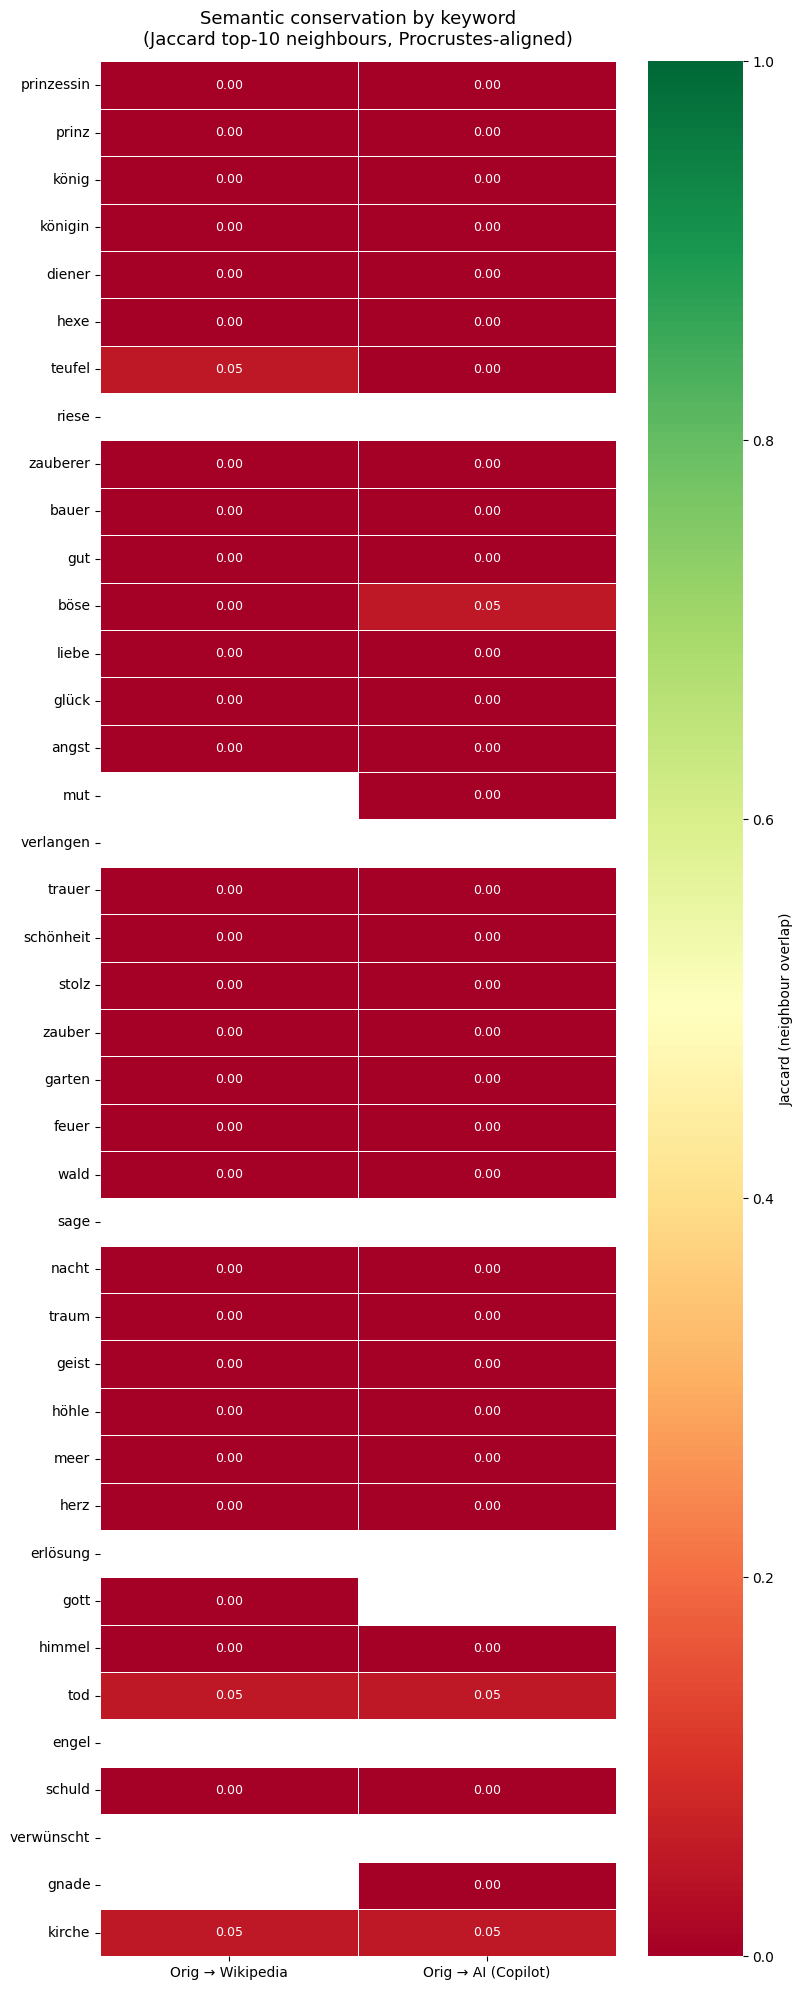

Saved: Step1_heatmap_jaccard.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 1-4. Visualisation 1 — Jaccard heatmap
# ────────────────────────────────────────────────────────────────

n_words = len(rq1_results)  # altura dinámica según número de palabras

fig, ax = plt.subplots(figsize=(8, n_words * 0.45 + 2))
heat_data = rq1_results.set_index("word")[["jaccard_wiki", "jaccard_ia"]].rename(
    columns={"jaccard_wiki": "Orig → Wikipedia", "jaccard_ia": "Orig → AI (Copilot)"}
)
sns.heatmap(
    heat_data, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5,
    cbar_kws={"label": "Jaccard (neighbour overlap)"},
    ax=ax, mask=heat_data.isna(),
    annot_kws={"size": 9},
)
ax.set_title(
    "Semantic conservation by keyword\n(Jaccard top-10 neighbours, Procrustes-aligned)",
    fontsize=13, pad=12,
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=10)
plt.tight_layout()
plt.savefig("Step1_heatmap_jaccard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step1_heatmap_jaccard.png")

In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 1-5. Visualisation 2 — Nearest neighbours comparison
#         Group 1: automatic (top shifted by jaccard_ia)
#         Group 2: manual (theoretically motivated)
# ────────────────────────────────────────────────────────────────

def show_neighbours_compared(word, topn=8):
    """Side-by-side neighbour table for a word across 3 corpora."""
    print(f"\n── Semantic neighbours of '{word}' ─────────────────")
    def get_nb(model):
        return [w for w, _ in model.wv.most_similar(word, topn=topn)] if word in model.wv else []

    v_orig = get_nb(model_orig)
    v_wiki = get_nb(model_wiki)
    v_ia   = get_nb(model_ia)

    df_nb = pd.DataFrame({
        "Originals":    v_orig + [""] * (topn - len(v_orig)),
        "Wikipedia":    v_wiki + [""] * (topn - len(v_wiki)),
        "AI (Copilot)": v_ia   + [""] * (topn - len(v_ia)),
    }, index=range(1, topn + 1))
    print(df_nb.to_string())

    s_o, s_w, s_i = set(v_orig), set(v_wiki), set(v_ia)
    print(f"\n  Common to all 3        : {s_o & s_w & s_i or '–'}")
    print(f"  Exclusive to originals : {s_o - s_w - s_i or '–'}")
    print(f"  Exclusive to AI        : {s_i - s_o - s_w or '–'}")

# ── Group 1: automatic (lowest jaccard_ia) ───────────────────
top_auto = (
    rq1_results
    .dropna(subset=["jaccard_ia"])
    .nsmallest(3, "jaccard_ia")["word"]
    .tolist()
)

# ── Group 2: theoretically motivated (manual selection) ──────
top_manual = [
    "trauer",      # shift wiki · disappearance IA — emotional loss
    "erlösung",    # shift wiki · disappearance IA — theological loss
    "meer",        # conservation IA — unexpected result
    "sehnsucht",   # shift both — core Andersen emotion
    "könig",       # only stable conservation — functional narrative role
]

# Remove duplicates from group 2 already covered in group 1
top_manual_clean = [w for w in top_manual if w not in top_auto]

# ── Output group 1 ───────────────────────────────────────────
print("\n" + "="*65)
print("  GROUP 1 — Top shifted (automatic, lowest jaccard_ia)")
print("="*65)
print(f"  Words: {top_auto}")

for w in top_auto:
    show_neighbours_compared(w)

# ── Output group 2 ───────────────────────────────────────────
print("\n" + "="*65)
print("  GROUP 2 — Theoretically motivated (manual selection)")
print("="*65)
print(f"  Words: {top_manual_clean}")

for w in top_manual_clean:
    show_neighbours_compared(w)


  GROUP 1 — Top shifted (automatic, lowest jaccard_ia)
  Words: ['prinzessin', 'prinz', 'könig']

── Semantic neighbours of 'prinzessin' ─────────────────
     Originals         Wikipedia      AI (Copilot)
1      geputzt       hochmütigen         willibald
2  gestiefelte          roswitha  schicksalsfrauen
3       stolze       bartwuchses      wunderlichen
4      gewogen           gedenkt          besiegte
5      wünsche            ablauf         tauschten
6         satz            lieben           bischof
7      spielen  festgemeinschaft           vollzog
8          heu           isabell        köhlersohn

  Common to all 3        : –
  Exclusive to originals : {'gewogen', 'wünsche', 'stolze', 'satz', 'spielen', 'geputzt', 'gestiefelte', 'heu'}
  Exclusive to AI        : {'willibald', 'wunderlichen', 'schicksalsfrauen', 'besiegte', 'köhlersohn', 'bischof', 'tauschten', 'vollzog'}

── Semantic neighbours of 'prinz' ─────────────────
       Originals    Wikipedia AI (Copilot)
1        

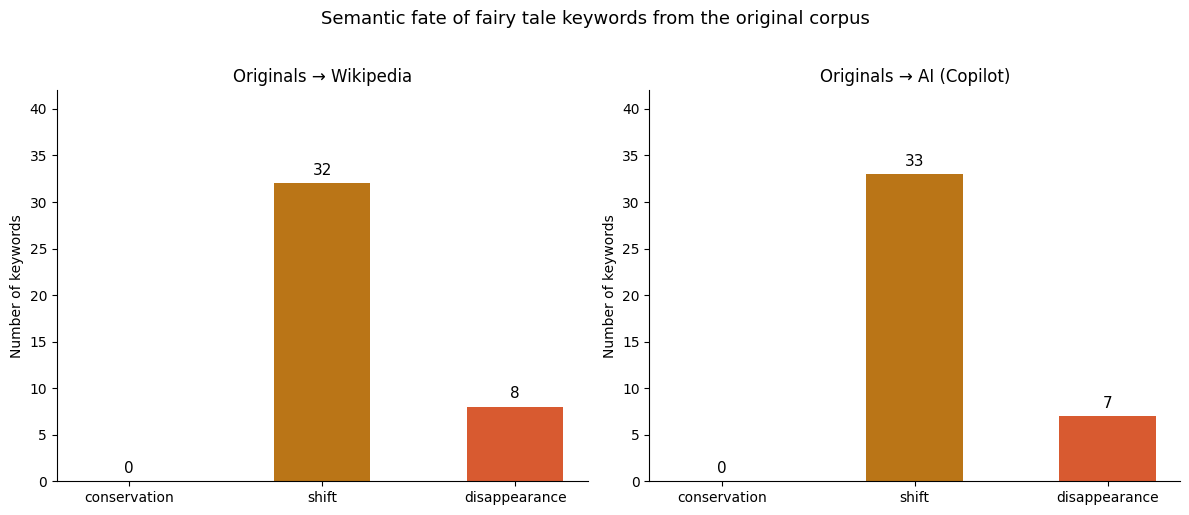

Saved: Step1_categories_barplot.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 1-6. Visualisation 3 — Category bar chart
# ────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
categories = ["conservation", "shift", "disappearance"]
cat_colors = ["#1D9E75", "#BA7517", "#D85A30"]

for ax, col, title in zip(
    axes,
    ["category_wiki", "category_ia"],
    ["Originals → Wikipedia", "Originals → AI (Copilot)"],
):
    counts = rq1_results[col].value_counts().reindex(categories, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=cat_colors, width=0.5)
    ax.bar_label(bars, padding=4, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Number of keywords")
    ax.set_ylim(0, len(keywords) + 2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Semantic fate of fairy tale keywords from the original corpus", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("Step1_categories_barplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step1_categories_barplot.png")

In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 1-7. Disappearance analysis — active vocabulary comparison
# ────────────────────────────────────────────────────────────────

vocab_orig = set(model_orig.wv.key_to_index)
vocab_wiki = set(model_wiki.wv.key_to_index)
vocab_ia   = set(model_ia.wv.key_to_index)

only_orig      = vocab_orig - vocab_wiki - vocab_ia
in_orig_not_ia = vocab_orig - vocab_ia

print(f"\n── Active vocabulary ────────────────────────────────")
print(f"  Originals : {len(vocab_orig)} words")
print(f"  Wikipedia : {len(vocab_wiki)} words")
print(f"  AI        : {len(vocab_ia)} words")
print(f"\n  Exclusive to originals (absent from both) : {len(only_orig)}")
print(f"  In originals but NOT in AI                : {len(in_orig_not_ia)}")

freq_orig       = {w: model_orig.wv.get_vecattr(w, "count") for w in in_orig_not_ia if w in vocab_orig}
top_disappeared = sorted(freq_orig, key=freq_orig.get, reverse=True)[:30]
print(f"\n  Top 30 disappeared words (by original frequency):")
print(" ", ", ".join(top_disappeared))


── Active vocabulary ────────────────────────────────
  Originals : 3189 words
  Wikipedia : 3203 words
  AI        : 2700 words

  Exclusive to originals (absent from both) : 1492
  In originals but NOT in AI                : 1798

  Top 30 disappeared words (by original frequency):
  türe, fing, laß, herum, lieber, weiss, königssohn, sneewittchen, gott, grethel, swinegel, wirt, nein, löwe, habt, wären, herrn, fertig, vergnügt, liegen, sitzen, aufs, gesagt, höhe, erblickte, dirs, alsbald, seid, gerne, jüngling


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 1-8. Export
# ────────────────────────────────────────────────────────────────

rq1_results.to_csv("Step1_semantic_results.csv", index=False, encoding="utf-8-sig")
print("\n✓ Step1 complete. Files saved:")
print("    · Step1_heatmap_jaccard.png")
print("    · Step1_categories_barplot.png")
print("    · Step1_semantic_results.csv")



✓ Step1 complete. Files saved:
    · Step1_heatmap_jaccard.png
    · Step1_categories_barplot.png
    · Step1_semantic_results.csv


# 2. Concept-level analysis (Semantic shift of key fairy tale concepts)
How does the meaning of specific concepts change?

In [ ]:
# Concepts to study — a subset of the keywords above, chosen for
# their cultural significance in the fairy tale genre
CONCEPTS = [
    # Archetypal characters
    "prinzessin", "prinz", "könig", "königin", "diener", "hexe",
    "teufel", "riese", "zauberer", "bauer",
    # Values and emotions
    "gut", "böse", "liebe", "glück", "angst", "mut", "verlangen",
    "trauer", "schönheit", "stolz",
    # Magical world
    "zauber", "garten", "feuer", "wald", "sage",
    "nacht", "traum", "geist", "höhle", "meer",
    # Spiritual / moral elements (candidates for disappearance)
    "herz", "erlösung", "gott", "himmel", "tod", "engel",
    "schuld", "verwünscht", "gnade", "kirche",
]
CONCEPTS = [c for c in CONCEPTS if c in model_orig.wv]
print(f"\n  {len(CONCEPTS)} concepts available: {CONCEPTS}")


  40 concepts available: ['prinzessin', 'prinz', 'könig', 'königin', 'diener', 'hexe', 'teufel', 'riese', 'zauberer', 'bauer', 'gut', 'böse', 'liebe', 'glück', 'angst', 'mut', 'verlangen', 'trauer', 'schönheit', 'stolz', 'zauber', 'garten', 'feuer', 'wald', 'sage', 'nacht', 'traum', 'geist', 'höhle', 'meer', 'herz', 'erlösung', 'gott', 'himmel', 'tod', 'engel', 'schuld', 'verwünscht', 'gnade', 'kirche']


In [ ]:

# ────────────────────────────────────────────────────────────────
# Step 2-1. Level 1 — Nearest neighbours compared (Jaccard)
# ────────────────────────────────────────────────────────────────

def get_neighbours(model, word, topn=10):
    if word not in model.wv:
        return []
    return [w for w, _ in model.wv.most_similar(word, topn=topn)]

def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return np.nan
    return len(set_a & set_b) / len(set_a | set_b)

def analyse_concept_neighbours(concept, topn=10):
    v_orig = get_neighbours(model_orig, concept, topn)
    v_wiki = get_neighbours(model_wiki, concept, topn)
    v_ia   = get_neighbours(model_ia,   concept, topn)

    pad    = lambda lst: lst + [""] * (max(len(v_orig), len(v_wiki), len(v_ia), topn) - len(lst))
    df_nb  = pd.DataFrame({
        "Originals":    pad(v_orig),
        "Wikipedia":    pad(v_wiki),
        "AI (Copilot)": pad(v_ia),
    }, index=range(1, topn + 1))

    print(f"\n{'═'*54}")
    print(f"  Concept: '{concept}'")
    print(f"{'═'*54}")
    print(df_nb.to_string())

    s_o, s_w, s_i = set(v_orig), set(v_wiki), set(v_ia)
    j_ow = jaccard(s_o, s_w)
    j_oi = jaccard(s_o, s_i)
    j_wi = jaccard(s_w, s_i)

    print(f"\n  Jaccard Orig↔Wiki : {j_ow:.3f}")
    print(f"  Jaccard Orig↔AI   : {j_oi:.3f}")
    print(f"  Jaccard Wiki↔AI   : {j_wi:.3f}")
    print(f"  Common to all 3   : {s_o & s_w & s_i or '–'}")
    print(f"  Exclusive Orig    : {s_o - s_w - s_i or '–'}")
    print(f"  Exclusive AI      : {s_i - s_o - s_w or '–'}")

    return {"concept": concept, "j_orig_wiki": round(j_ow, 3),
            "j_orig_ia": round(j_oi, 3), "j_wiki_ia": round(j_wi, 3)}

print("\n── Level 1: neighbour comparison ────────────────────")
level1_rows = [analyse_concept_neighbours(c) for c in CONCEPTS]
level1 = pd.DataFrame(level1_rows)



── Level 1: neighbour comparison ────────────────────

══════════════════════════════════════════════════════
  Concept: 'prinzessin'
══════════════════════════════════════════════════════
       Originals         Wikipedia      AI (Copilot)
1        geputzt       hochmütigen         willibald
2    gestiefelte          roswitha  schicksalsfrauen
3         stolze       bartwuchses      wunderlichen
4        gewogen           gedenkt          besiegte
5        wünsche            ablauf         tauschten
6           satz            lieben           bischof
7        spielen  festgemeinschaft           vollzog
8            heu           isabell        köhlersohn
9   vorbeifahren             frist              zofe
10         hufen      eigentlichen         empfangen

  Jaccard Orig↔Wiki : 0.000
  Jaccard Orig↔AI   : 0.000
  Jaccard Wiki↔AI   : 0.000
  Common to all 3   : –
  Exclusive Orig    : {'gewogen', 'wünsche', 'hufen', 'stolze', 'satz', 'vorbeifahren', 'spielen', 'geputzt', 'gestief

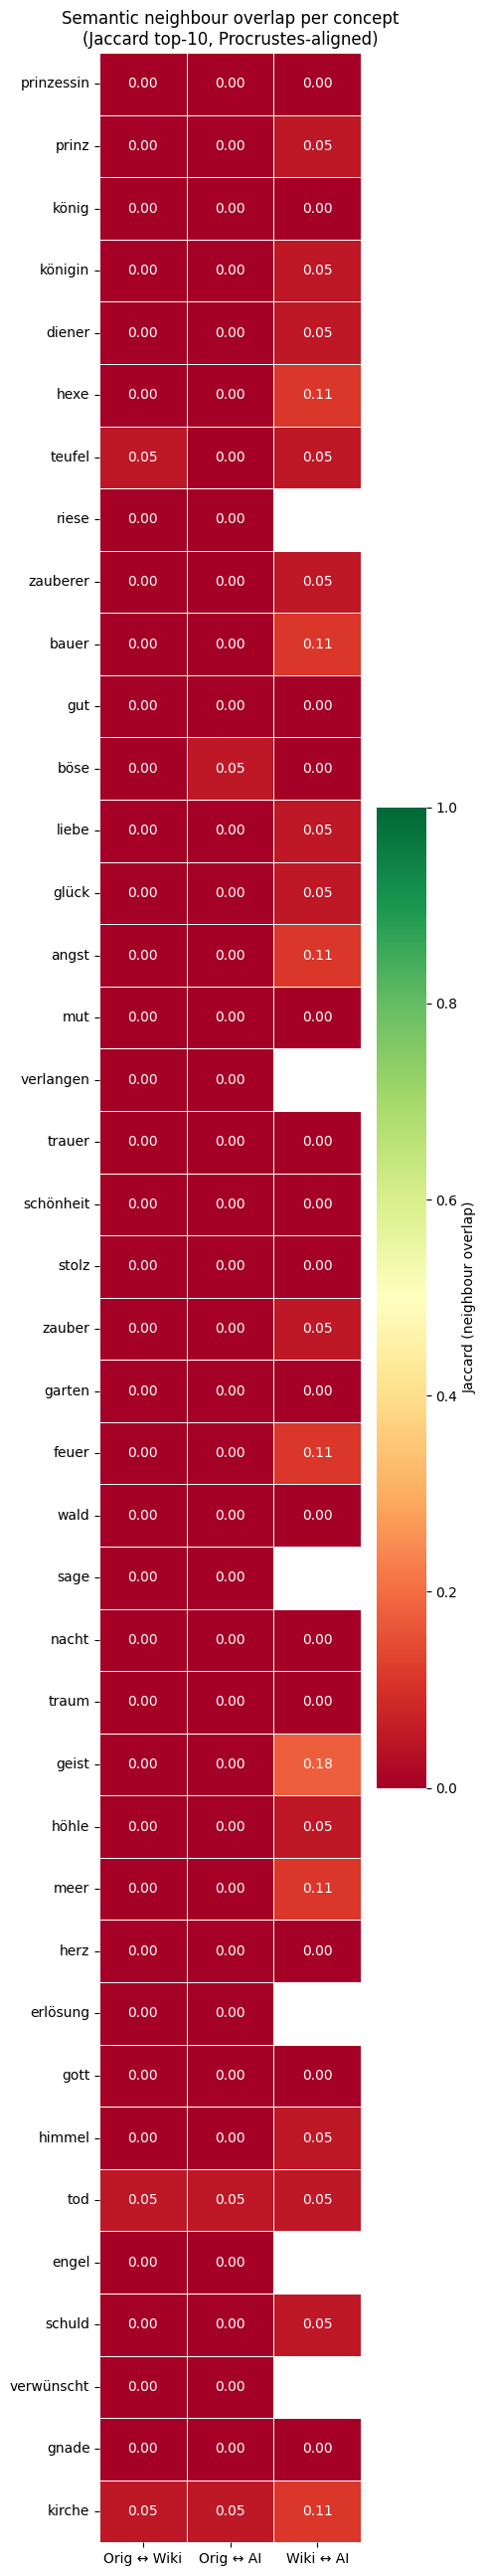

Saved: Step2_jaccard_heatmap.png


In [ ]:
# Visualisation: Jaccard heatmap
fig, ax = plt.subplots(figsize=(5, len(CONCEPTS) * 0.6 + 2))
heat = level1.set_index("concept")[["j_orig_wiki", "j_orig_ia", "j_wiki_ia"]].rename(
    columns={"j_orig_wiki": "Orig ↔ Wiki", "j_orig_ia": "Orig ↔ AI", "j_wiki_ia": "Wiki ↔ AI"}
)
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Jaccard (neighbour overlap)"}, ax=ax)
ax.set_title("Semantic neighbour overlap per concept\n(Jaccard top-10, Procrustes-aligned)", fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("Step2_jaccard_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step2_jaccard_heatmap.png")

In [ ]:
# ────────────────────────────────────────────────────────────────
# Step2-2. Level 2 — Aligned cosine distance
#         How far did the concept's vector actually move?
# ────────────────────────────────────────────────────────────────

def cosine_dist(v1, v2):
    return 1 - np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-9)

print("\n── Level 2: aligned cosine distance ─────────────────")
print("  (0 = identical position · 1 = opposite poles)\n")

level2_rows = []
for concept in CONCEPTS:
    v_orig = model_orig.wv[concept] if concept in model_orig.wv else None
    v_wiki = vecs_wiki_aligned.get(concept)
    v_ia   = vecs_ia_aligned.get(concept)

    d_ow = cosine_dist(v_orig, v_wiki) if (v_orig is not None and v_wiki is not None) else np.nan
    d_oi = cosine_dist(v_orig, v_ia)   if (v_orig is not None and v_ia   is not None) else np.nan
    d_wi = cosine_dist(v_wiki, v_ia)   if (v_wiki is not None and v_ia   is not None) else np.nan

    level2_rows.append({
        "concept": concept,
        "dist_orig_wiki": round(d_ow, 4) if not np.isnan(d_ow) else np.nan,
        "dist_orig_ia":   round(d_oi, 4) if not np.isnan(d_oi) else np.nan,
        "dist_wiki_ia":   round(d_wi, 4) if not np.isnan(d_wi) else np.nan,
    })

level2 = pd.DataFrame(level2_rows)
print(level2.to_string(index=False))


── Level 2: aligned cosine distance ─────────────────
  (0 = identical position · 1 = opposite poles)

   concept  dist_orig_wiki  dist_orig_ia  dist_wiki_ia
prinzessin          0.5143        0.5320        0.6444
     prinz          0.4492        0.4479        0.6634
     könig          0.4649        0.6045        0.7066
   königin          0.3288        0.5102        0.6347
    diener          0.5323        0.4525        0.6828
      hexe          0.4472        0.4645        0.5790
    teufel          0.3410        0.4544        0.5366
     riese             NaN           NaN           NaN
  zauberer          0.5135        0.5537        0.6137
     bauer          0.4851        0.4660        0.5729
       gut          0.4912        0.4872        0.6495
      böse          0.4343        0.5310        0.7359
     liebe          0.4723        0.5027        0.6747
     glück          0.5092        0.4808        0.6656
     angst          0.4432        0.5226        0.6552
       mut      

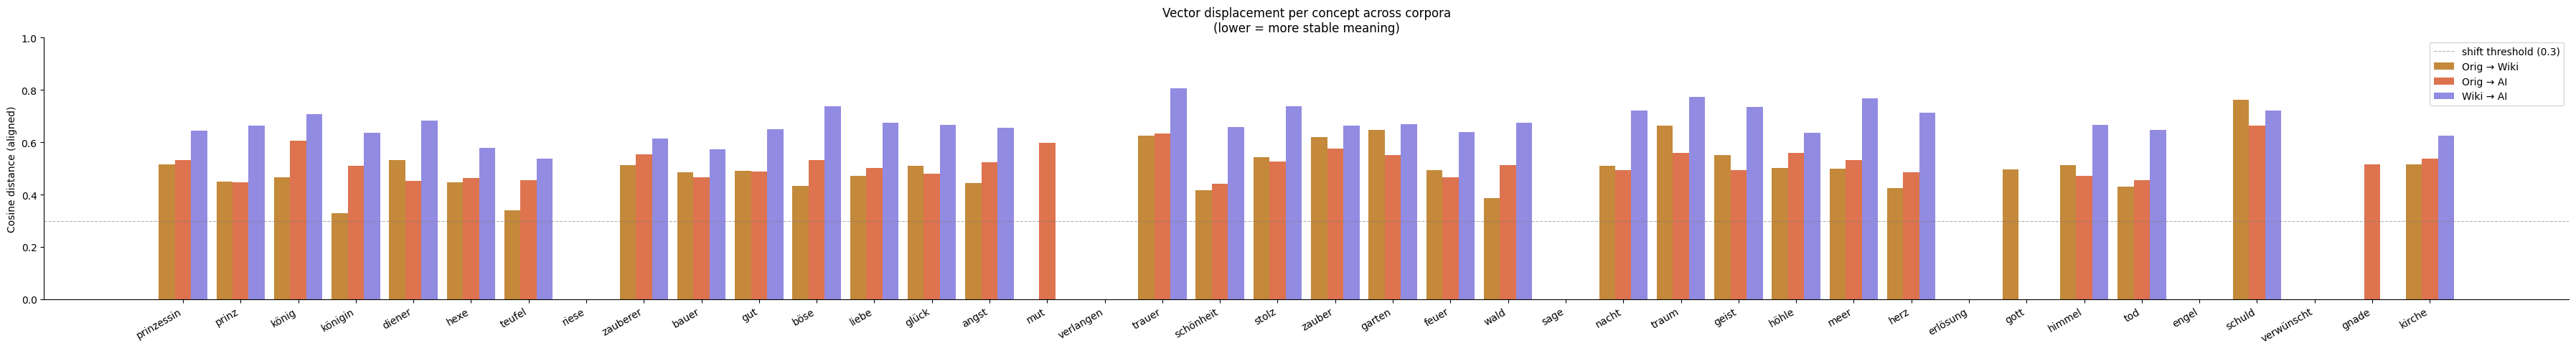

Saved: Step2_cosine_distance_barplot.png


In [ ]:
# Visualisation: grouped bar chart
x     = np.arange(len(CONCEPTS))
width = 0.28
fig, ax = plt.subplots(figsize=(max(10, len(CONCEPTS) * 0.9), 5))
ax.bar(x - width, level2["dist_orig_wiki"], width, label="Orig → Wiki",  color=COLORS["Wikipedia"],    alpha=0.85)
ax.bar(x,         level2["dist_orig_ia"],   width, label="Orig → AI",    color=COLORS["AI (Copilot)"], alpha=0.85)
ax.bar(x + width, level2["dist_wiki_ia"],   width, label="Wiki → AI",    color="#7F77DD",               alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CONCEPTS, rotation=30, ha="right")
ax.set_ylabel("Cosine distance (aligned)")
ax.set_title("Vector displacement per concept across corpora\n(lower = more stable meaning)", fontsize=12)
ax.set_ylim(0, 1)
ax.axhline(0.3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="shift threshold (0.3)")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("Step2_cosine_distance_barplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step2_cosine_distance_barplot.png")

In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 2-3. Level 3 — Semantic radar (dimensional projection)
#
# Each dimension is defined by seed words. Verify which ones exist
# in your vocabulary before running:
#
#   for dim, seeds in DIMENSIONS.items():
#       present = [w for w in seeds if w in model_orig.wv]
#       print(f"{dim}: {present}")
# ────────────────────────────────────────────────────────────────

DIMENSIONS = {
    "morality":    ["gut", "tugend", "treu", "gerecht", "böse", "schuld"],
    "suffering":   ["angst", "trauer", "schmerz", "weinen", "leid", "einsamkeit"],
    "salvation":   ["retten", "befreien", "erlösung", "hilfe", "glück", "wunder"],
    "power":       ["könig", "macht", "herrschen", "stark", "siegen", "befehlen"],
    "magic":       ["zauber", "verwandlung", "wunder", "fee", "hexe", "geheimnis"],
    "love":        ["liebe", "herz", "sehnsucht", "heirat", "treue", "zärtlich"],
    "death":       ["tod", "sterben", "grab", "ende", "vergehen", "opfer"],
}

def dimension_score(model, concept, seed_words):
    """Average cosine similarity between concept and seed words present in model."""
    if concept not in model.wv:
        return np.nan
    sims = [model.wv.similarity(concept, w) for w in seed_words if w in model.wv]
    return np.mean(sims) if sims else np.nan

def radar_chart(concept, scores_dict, ax):
    labels = list(DIMENSIONS.keys())
    N      = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], size=7)
    ax.set_title(f"'{concept}'", size=11, pad=20)

    for label, color in COLORS.items():
        values      = scores_dict.get(label, [np.nan] * N)
        values_plot = [v if not np.isnan(v) else 0 for v in values] + [0]
        values_plot[-1] = values_plot[0]
        ax.plot(angles, values_plot, color=color, linewidth=1.5, label=label)
        ax.fill(angles, values_plot, color=color, alpha=0.12)

print("\n── Level 3: semantic radar (dimensional projection) ─")

concept_scores = {}
for concept in CONCEPTS:
    concept_scores[concept] = {
        corpus: [dimension_score(model, concept, seeds) for seeds in DIMENSIONS.values()]
        for corpus, model in zip(
            ["Originals", "Wikipedia", "AI (Copilot)"],
            [model_orig,  model_wiki,  model_ia],
        )
    }
    print(f"\n  {concept}:")
    for corpus, scores in concept_scores[concept].items():
        score_str = "  ".join(
            f"{dim}={s:.2f}" if not np.isnan(s) else f"{dim}=N/A"
            for dim, s in zip(DIMENSIONS.keys(), scores)
        )
        print(f"    {corpus:15s}: {score_str}")


── Level 3: semantic radar (dimensional projection) ─

  prinzessin:
    Originals      : morality=0.16  suffering=0.11  salvation=0.16  power=0.21  magic=0.14  love=0.07  death=0.13
    Wikipedia      : morality=0.09  suffering=0.11  salvation=0.08  power=0.13  magic=0.09  love=0.14  death=0.06
    AI (Copilot)   : morality=0.12  suffering=0.09  salvation=0.13  power=0.14  magic=0.11  love=0.11  death=0.06

  prinz:
    Originals      : morality=0.14  suffering=0.19  salvation=0.16  power=0.07  magic=0.17  love=0.11  death=0.15
    Wikipedia      : morality=0.16  suffering=0.09  salvation=0.13  power=0.11  magic=0.15  love=0.16  death=0.13
    AI (Copilot)   : morality=0.09  suffering=0.09  salvation=0.16  power=0.10  magic=0.15  love=0.11  death=0.11

  könig:
    Originals      : morality=0.14  suffering=0.12  salvation=0.08  power=0.42  magic=0.14  love=0.15  death=0.09
    Wikipedia      : morality=0.12  suffering=0.08  salvation=0.09  power=0.32  magic=0.10  love=0.11  death=0.0

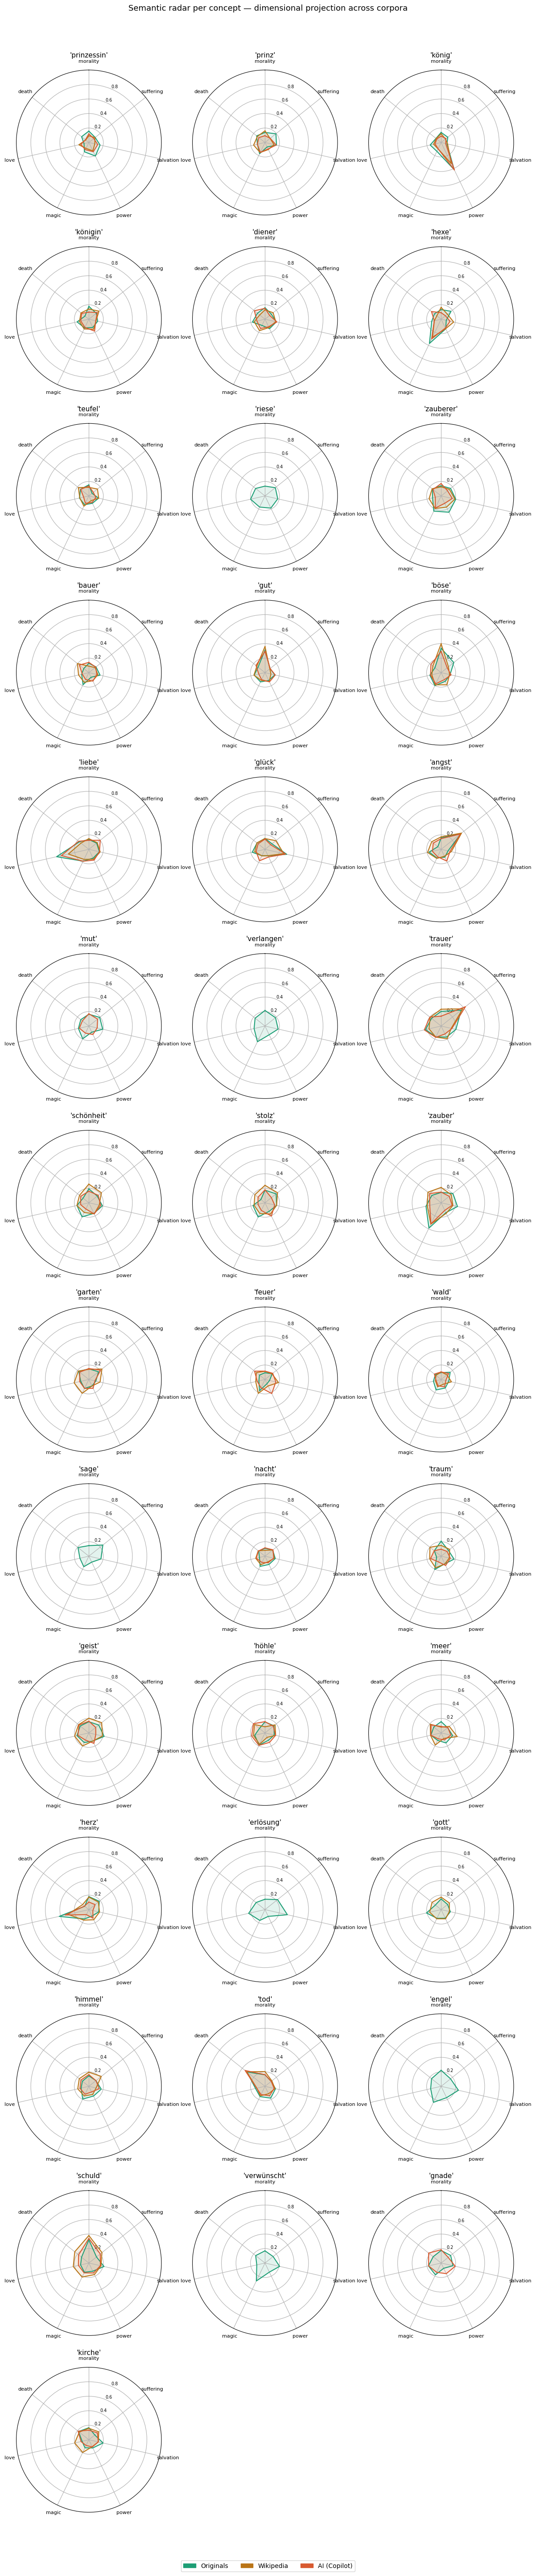

Saved: Step2_semantic_radar.png


In [ ]:
# Visualisation: radar grid
n_cols = 3
n_rows = -(-len(CONCEPTS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4),
                          subplot_kw=dict(polar=True))
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, concept in enumerate(CONCEPTS):
    radar_chart(concept, concept_scores[concept], axes_flat[i])
for j in range(len(CONCEPTS), len(axes_flat)):
    axes_flat[j].set_visible(False)

handles = [mpatches.Patch(color=c, label=l) for l, c in COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Semantic radar per concept — dimensional projection across corpora",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("Step2_semantic_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step2_semantic_radar.png")


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step2-4. Export combined results
# ────────────────────────────────────────────────────────────────

combined = level1[["concept", "j_orig_wiki", "j_orig_ia", "j_wiki_ia"]].merge(
    level2[["concept", "dist_orig_wiki", "dist_orig_ia", "dist_wiki_ia"]],
    on="concept",
)
combined.to_csv("Step2_concept_shift_results.csv", index=False, encoding="utf-8-sig")

print("\n✓ Step2 complete. Files saved:")
print("    · Step2_jaccard_heatmap.png")
print("    · Step2_cosine_distance_barplot.png")
print("    · Step2_semantic_radar.png")
print("    · Step2_concept_shift_results.csv")

print("\n" + "=" * 60)
print("  PIPELINE COMPLETE")
print("  All outputs saved to working directory.")
print("=" * 60)


✓ Step2 complete. Files saved:
    · Step2_jaccard_heatmap.png
    · Step2_cosine_distance_barplot.png
    · Step2_semantic_radar.png
    · Step2_concept_shift_results.csv

  PIPELINE COMPLETE
  All outputs saved to working directory.


# 3. Doc2Vec: Semantic proximity of AI-generated texts to source corpora
Are AI (Copilot) texts closer to originals or Wikipedia?

In [ ]:

# ────────────────────────────────────────────────────────────────
# Step3-1. Build a single global corpus with labelled documents
#         Labels encode both the corpus and the document name:
#           orig_<filename>  · wiki_<filename>  · ia_<filename>
# ────────────────────────────────────────────────────────────────

tagged_docs = []

for i, row in df.iterrows():
    tagged_docs.append(TaggedDocument(
        words=row["tokens"],
        tags=[f"orig_{row['file']}"]
    ))

for i, row in df2.iterrows():
    tagged_docs.append(TaggedDocument(
        words=row["tokens"],
        tags=[f"wiki_{row['file']}"]
    ))

for i, row in df3.iterrows():
    tagged_docs.append(TaggedDocument(
        words=row["tokens"],
        tags=[f"ia_{row['file']}"]
    ))

print(f"Total documents in global corpus: {len(tagged_docs)}")
print(f"  Originals  : {len(df)}")
print(f"  Wikipedia  : {len(df2)}")
print(f"  AI         : {len(df3)}")

Total documents in global corpus: 214
  Originals  : 40
  Wikipedia  : 87
  AI         : 87


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 3-2. Train the global Doc2Vec model
# ────────────────────────────────────────────────────────────────

model_d2v = Doc2Vec(
    documents=tagged_docs,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4,
    dm=1,           # PV-DM (distributed memory) — better for short texts
    epochs=200,
    seed=42,
)

print(f"\nGlobal Doc2Vec trained.")
print(f"  Vocabulary size : {len(model_d2v.wv)}")
print(f"  Document vectors: {len(model_d2v.dv)}")


Global Doc2Vec trained.
  Vocabulary size : 6851
  Document vectors: 214


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 3-3. Extract document vectors grouped by corpus
# ────────────────────────────────────────────────────────────────

from scipy.spatial.distance import cosine as cosine_distance

tags_orig = [t for t in model_d2v.dv.index_to_key if t.startswith("orig_")]
tags_wiki = [t for t in model_d2v.dv.index_to_key if t.startswith("wiki_")]
tags_ia   = [t for t in model_d2v.dv.index_to_key if t.startswith("ia_")]

vecs_orig = np.array([model_d2v.dv[t] for t in tags_orig])
vecs_wiki = np.array([model_d2v.dv[t] for t in tags_wiki])
vecs_ia   = np.array([model_d2v.dv[t] for t in tags_ia])

# Centroid of each corpus (mean document vector)
centroid_orig = vecs_orig.mean(axis=0)
centroid_wiki = vecs_wiki.mean(axis=0)
centroid_ia   = vecs_ia.mean(axis=0)

print(f"\nCentroid distances:")
print(f"  Orig ↔ Wiki : {cosine_distance(centroid_orig, centroid_wiki):.4f}")
print(f"  Orig ↔ AI   : {cosine_distance(centroid_orig, centroid_ia):.4f}")
print(f"  Wiki ↔ AI   : {cosine_distance(centroid_wiki, centroid_ia):.4f}")


Centroid distances:
  Orig ↔ Wiki : 0.4154
  Orig ↔ AI   : 0.3068
  Wiki ↔ AI   : 0.3046


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 3-4. Core question: for each AI text, is it closer to
#         originals or to Wikipedia?
# ────────────────────────────────────────────────────────────────

def cosine_sim(v1, v2):
    return 1 - cosine_distance(v1, v2)

def avg_sim_to_corpus(vec, corpus_vecs):
    """Average cosine similarity between vec and all vectors in corpus."""
    return np.mean([cosine_sim(vec, cv) for cv in corpus_vecs])

rows = []
for tag in tags_ia:
    vec = model_d2v.dv[tag]

    sim_to_orig = avg_sim_to_corpus(vec, vecs_orig)
    sim_to_wiki = avg_sim_to_corpus(vec, vecs_wiki)

    # Also: similarity to the 3 most similar documents in each corpus
    most_sim_orig = model_d2v.dv.most_similar(tag, topn=50)
    top3_orig = [(t, s) for t, s in most_sim_orig if t.startswith("orig_")][:3]
    top3_wiki = [(t, s) for t, s in most_sim_orig if t.startswith("wiki_")][:3]

    closer_to = "Originals" if sim_to_orig > sim_to_wiki else "Wikipedia"

    rows.append({
        "ai_document":    tag.replace("ia_", ""),
        "sim_to_orig":    round(sim_to_orig, 4),
        "sim_to_wiki":    round(sim_to_wiki, 4),
        "difference":     round(sim_to_orig - sim_to_wiki, 4),
        "closer_to":      closer_to,
        "top1_orig":      top3_orig[0][0].replace("orig_", "") if top3_orig else "–",
        "top1_orig_sim":  round(top3_orig[0][1], 3)            if top3_orig else np.nan,
        "top1_wiki":      top3_wiki[0][0].replace("wiki_", "") if top3_wiki else "–",
        "top1_wiki_sim":  round(top3_wiki[0][1], 3)            if top3_wiki else np.nan,
    })

rq3_results = pd.DataFrame(rows).sort_values("difference", ascending=False)

print("\n── Step 3 results: AI texts by proximity ───────────────")
print(rq3_results[["ai_document","sim_to_orig","sim_to_wiki","difference","closer_to"]].to_string(index=False))

n_closer_orig = (rq3_results["closer_to"] == "Originals").sum()
n_closer_wiki = (rq3_results["closer_to"] == "Wikipedia").sum()
print(f"\n  AI texts closer to Originals  : {n_closer_orig} / {len(rq3_results)}")
print(f"  AI texts closer to Wikipedia  : {n_closer_wiki} / {len(rq3_results)}")


── Step 3 results: AI texts by proximity ───────────────
                                                           ai_document  sim_to_orig  sim_to_wiki  difference closer_to
                         1976_Grimm_Copilot_Gusner_Das_blaue_Licht.txt       0.2834       0.2297      0.0537 Originals
                            1980_Grimm_Copilot_Hübner_Gevatter_Tod.txt       0.3093       0.2687      0.0406 Originals
                     1962_Grimm_Copilot_Stobrawa_König_Drosselbart.txt       0.2799       0.2492      0.0307 Originals
        1982_Grimm_Copilot_Beck_Der_Prinz_hinter_den_sieben_Meeren.txt       0.2914       0.2662      0.0252 Originals
                        1954_Grimm_Copilot_Surmann_Der_Froschkönig.txt       0.3153       0.2917      0.0235 Originals
                      1964_Grimm_Copilot_Kaltofen_Die_goldene_Gans.txt       0.2941       0.2743      0.0198 Originals
   1971_Grimm_Copilot_Barke_Der_arme_Müllerbursch_und_das_Kätzchen.txt       0.2312       0.2127      0.0185 

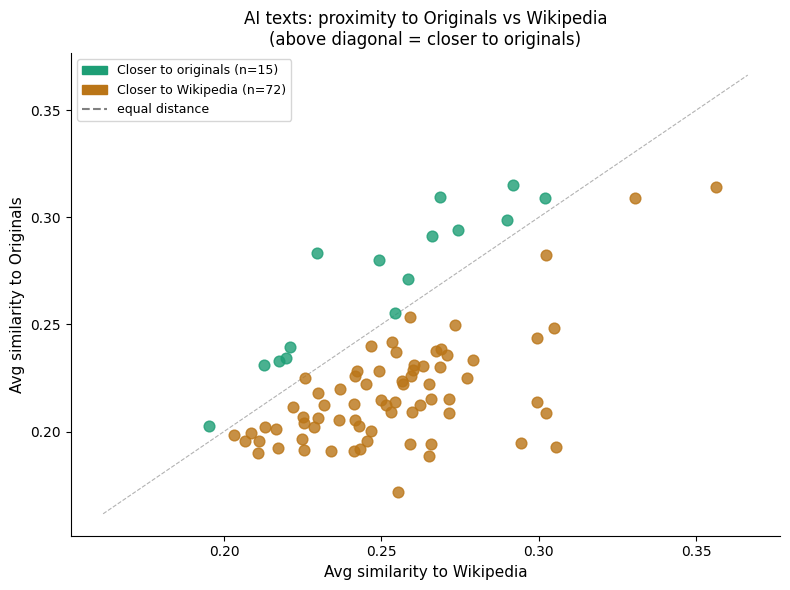

Saved: Step3_proximity_dotplot.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 3-5. Visualisation 1 — Dot plot: sim_to_orig vs sim_to_wiki
# ────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

for _, row in rq3_results.iterrows():
    color = COLORS["Originals"] if row["closer_to"] == "Originals" else COLORS["Wikipedia"]
    ax.scatter(row["sim_to_wiki"], row["sim_to_orig"], color=color, s=60, alpha=0.8, zorder=3)

# Diagonal: points above = closer to originals, below = closer to wiki
lim_min = min(rq3_results[["sim_to_orig","sim_to_wiki"]].min()) - 0.01
lim_max = max(rq3_results[["sim_to_orig","sim_to_wiki"]].max()) + 0.01
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="equal distance")

ax.set_xlabel("Avg similarity to Wikipedia", fontsize=11)
ax.set_ylabel("Avg similarity to Originals", fontsize=11)
ax.set_title(
    "AI texts: proximity to Originals vs Wikipedia\n(above diagonal = closer to originals)",
    fontsize=12,
)

handles = [
    mpatches.Patch(color=COLORS["Originals"], label=f"Closer to originals (n={n_closer_orig})"),
    mpatches.Patch(color=COLORS["Wikipedia"], label=f"Closer to Wikipedia (n={n_closer_wiki})"),
    plt.Line2D([0],[0], color="gray", linestyle="--", label="equal distance"),
]
ax.legend(handles=handles, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("Step3_proximity_dotplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step3_proximity_dotplot.png")

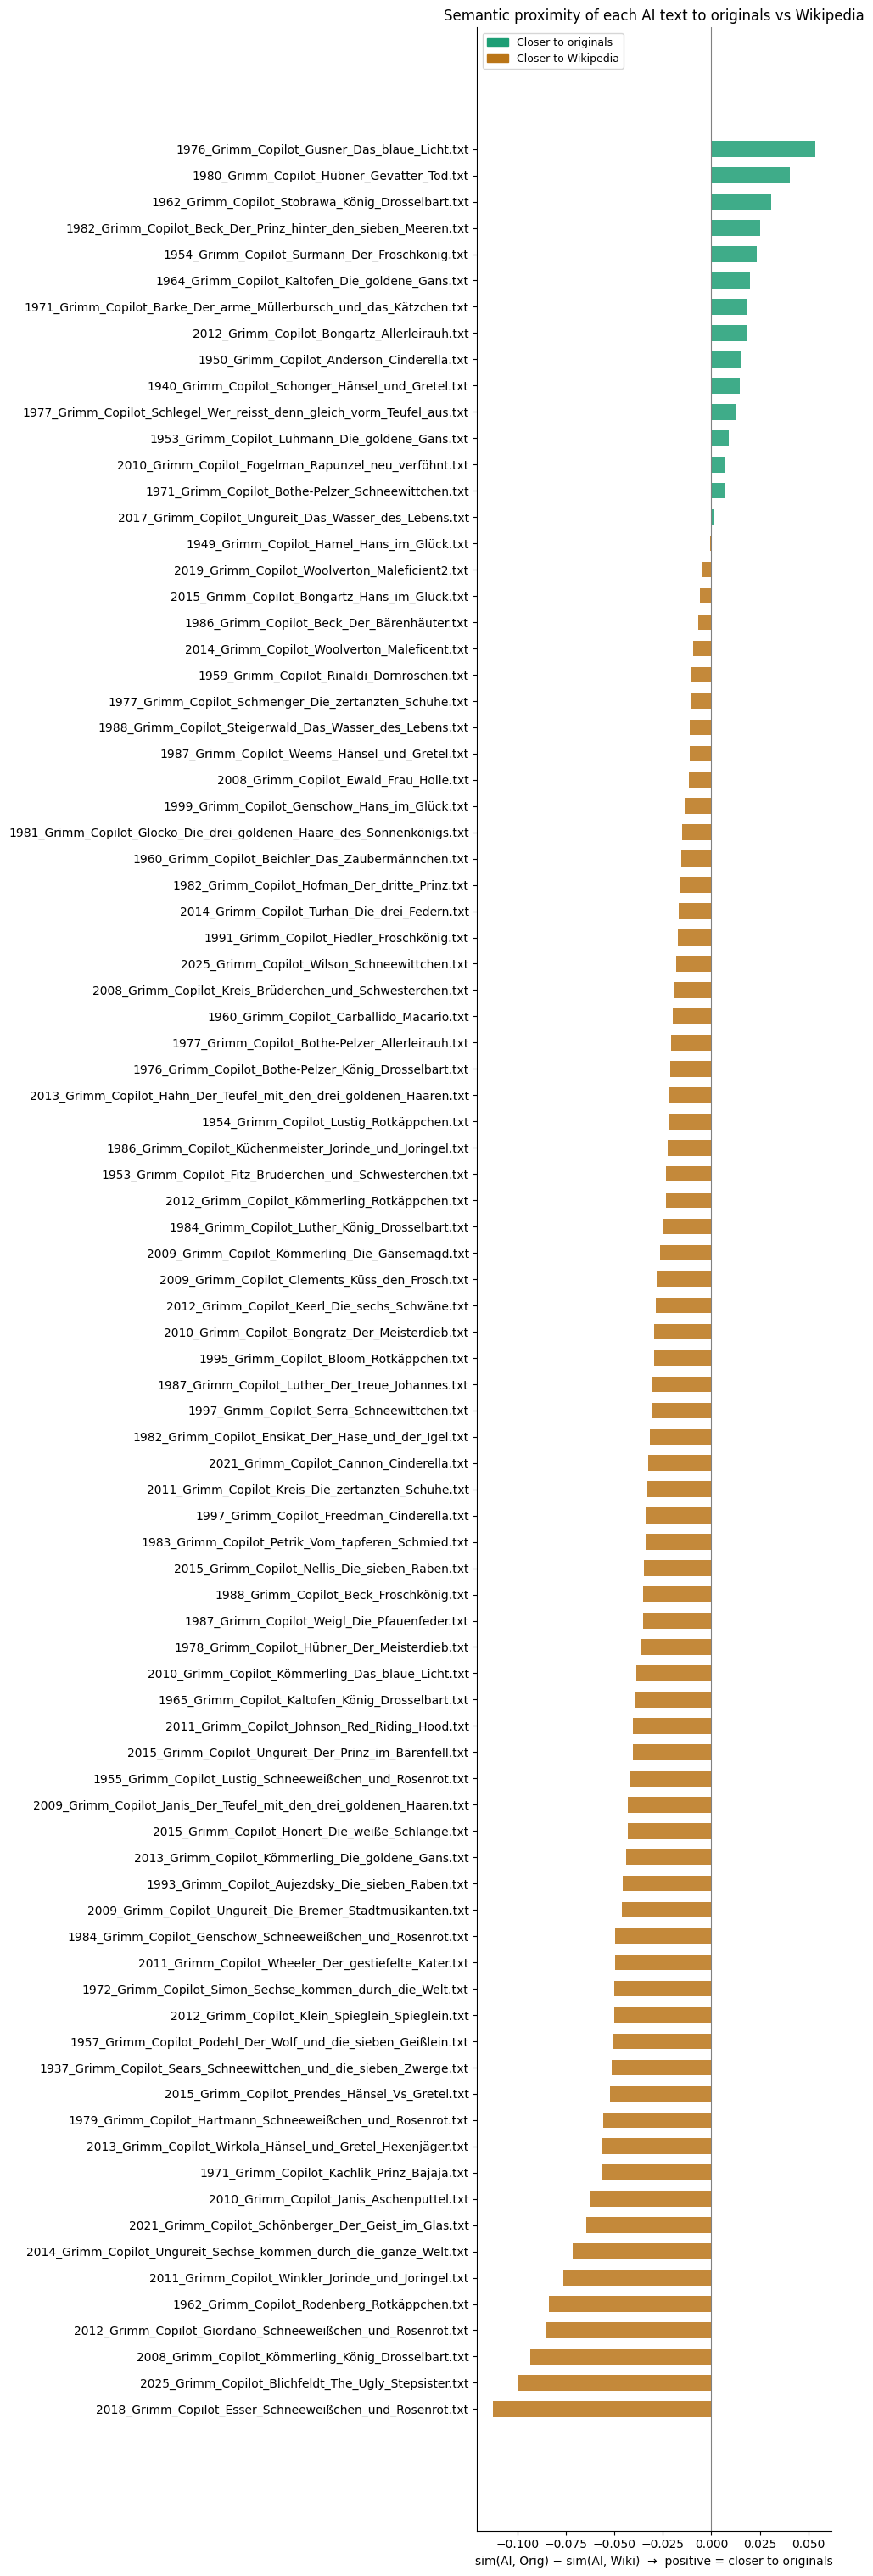

Saved: Step3_proximity_barplot.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 3-6. Visualisation 2 — Difference bar chart
#         Positive = closer to originals · Negative = closer to wiki
# ────────────────────────────────────────────────────────────────

df_plot = rq3_results.sort_values("difference")
colors_bar = [COLORS["Originals"] if d > 0 else COLORS["Wikipedia"]
              for d in df_plot["difference"]]

fig, ax = plt.subplots(figsize=(10, max(5, len(df_plot) * 0.35)))
bars = ax.barh(df_plot["ai_document"], df_plot["difference"],
               color=colors_bar, alpha=0.85, height=0.6)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("sim(AI, Orig) − sim(AI, Wiki)  →  positive = closer to originals", fontsize=10)
ax.set_title("Semantic proximity of each AI text to originals vs Wikipedia", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = [
    mpatches.Patch(color=COLORS["Originals"], label="Closer to originals"),
    mpatches.Patch(color=COLORS["Wikipedia"], label="Closer to Wikipedia"),
]
ax.legend(handles=handles, fontsize=9)
plt.tight_layout()
plt.savefig("Step3_proximity_barplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step3_proximity_barplot.png")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


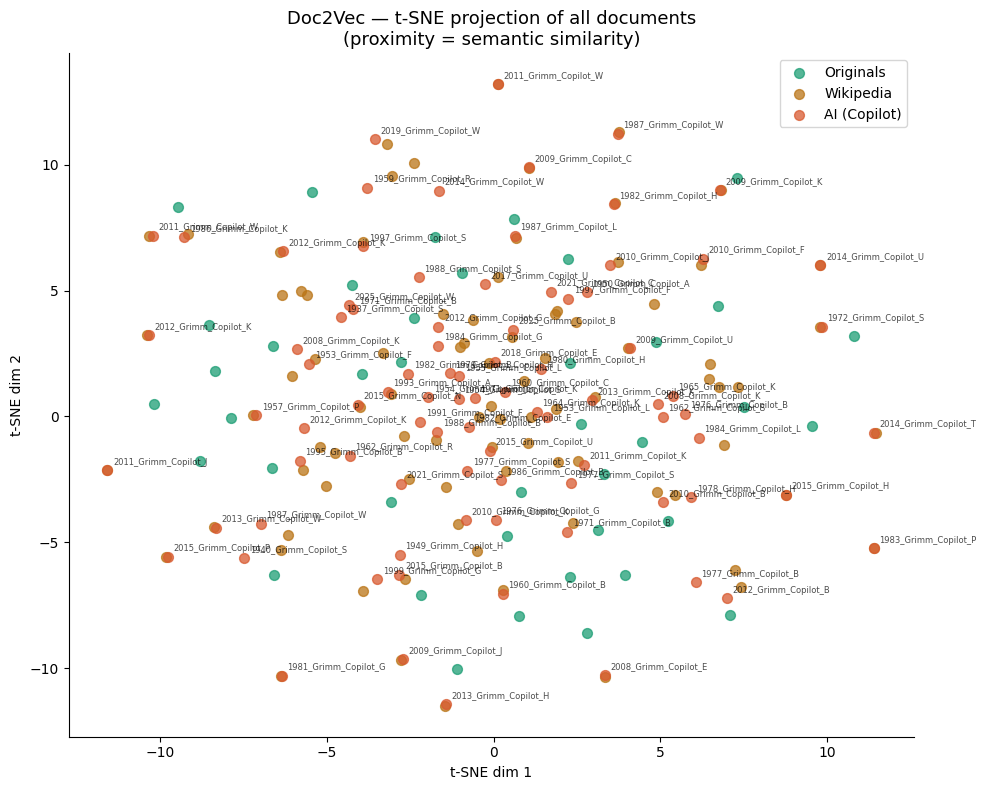

Saved: Step3_tsne_projection.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 3-7. Visualisation 3 — t-SNE projection of all documents
#         Shows the 3 corpora as clusters in 2D space
# ────────────────────────────────────────────────────────────────

all_tags  = tags_orig + tags_wiki + tags_ia
all_vecs  = np.vstack([vecs_orig, vecs_wiki, vecs_ia])
all_labels = (
    ["Originals"]    * len(tags_orig) +
    ["Wikipedia"]    * len(tags_wiki) +
    ["AI (Copilot)"] * len(tags_ia)
)

# t-SNE — perplexity should be < n_samples / 3
perplexity = min(30, len(all_tags) // 3 - 1)
tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=max(5, perplexity),
    n_iter=1000,
)
coords = tsne.fit_transform(all_vecs)

fig, ax = plt.subplots(figsize=(10, 8))
for corpus, color in COLORS.items():
    mask = [l == corpus for l in all_labels]
    x = coords[mask, 0]
    y = coords[mask, 1]
    ax.scatter(x, y, c=color, label=corpus, s=50, alpha=0.75, zorder=3)

    # Add short document labels for AI texts
    if corpus == "AI (Copilot)":
        for xi, yi, tag in zip(x, y, [t for t, l in zip(all_tags, all_labels) if l == corpus]):
            short = tag.replace("ia_", "")[:20]
            ax.annotate(short, (xi, yi), fontsize=6, alpha=0.7,
                        xytext=(4, 4), textcoords="offset points")

ax.set_title("Doc2Vec — t-SNE projection of all documents\n(proximity = semantic similarity)", fontsize=13)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("Step3_tsne_projection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step3_tsne_projection.png")

In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 3-8. Cohesion and separation metrics
#         Intra-corpus cohesion vs inter-corpus separation
# ────────────────────────────────────────────────────────────────

def mean_pairwise_sim(vecs):
    """Mean cosine similarity between all pairs within a corpus."""
    sims = []
    for i in range(len(vecs)):
        for j in range(i + 1, len(vecs)):
            sims.append(cosine_sim(vecs[i], vecs[j]))
    return np.mean(sims) if sims else np.nan

print("\n── Cohesion and separation ──────────────────────────")
coh_orig = mean_pairwise_sim(vecs_orig)
coh_wiki = mean_pairwise_sim(vecs_wiki)
coh_ia   = mean_pairwise_sim(vecs_ia)

print(f"  Intra-corpus cohesion (mean pairwise sim):")
print(f"    Originals  : {coh_orig:.4f}")
print(f"    Wikipedia  : {coh_wiki:.4f}")
print(f"    AI         : {coh_ia:.4f}")

sep_ow = cosine_distance(centroid_orig, centroid_wiki)
sep_oi = cosine_distance(centroid_orig, centroid_ia)
sep_wi = cosine_distance(centroid_wiki, centroid_ia)

print(f"\n  Inter-corpus separation (centroid cosine distance):")
print(f"    Orig ↔ Wiki : {sep_ow:.4f}")
print(f"    Orig ↔ AI   : {sep_oi:.4f}")
print(f"    Wiki ↔ AI   : {sep_wi:.4f}")

if sep_oi < sep_wi:
    print("\n  → AI corpus is CLOSER to Originals than to Wikipedia (centroid level)")
else:
    print("\n  → AI corpus is CLOSER to Wikipedia than to Originals (centroid level)")


── Cohesion and separation ──────────────────────────
  Intra-corpus cohesion (mean pairwise sim):
    Originals  : 0.2831
    Wikipedia  : 0.3654
    AI         : 0.3357

  Inter-corpus separation (centroid cosine distance):
    Orig ↔ Wiki : 0.4154
    Orig ↔ AI   : 0.3068
    Wiki ↔ AI   : 0.3046

  → AI corpus is CLOSER to Wikipedia than to Originals (centroid level)


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 3-9. Export
# ────────────────────────────────────────────────────────────────

rq3_results.to_csv("Step3_doc2vec_proximity_results.csv", index=False, encoding="utf-8-sig")
print("\n✓ Step3 complete. Files saved:")
print("    · Step3_proximity_dotplot.png")
print("    · Step3_proximity_barplot.png")
print("    · Step3_tsne_projection.png")
print("    · Step3_doc2vec_proximity_results.csv")


✓ Step3 complete. Files saved:
    · Step3_proximity_dotplot.png
    · Step3_proximity_barplot.png
    · Step3_tsne_projection.png
    · Step3_doc2vec_proximity_results.csv


In [ ]:
from sklearn.preprocessing import normalize

# Normalise vectors to unit length before clustering
# (cosine similarity becomes equivalent to euclidean on unit sphere)
vecs_norm = normalize(all_vecs, norm="l2")

CORPUS_ORDER = ["Originals", "Wikipedia", "AI (Copilot)"]
COLORS = {
    "Originals":    "#1D9E75",
    "Wikipedia":    "#BA7517",
    "AI (Copilot)": "#D85A30",
}

print("=" * 60)
print("  Step4 — K-Means clustering analysis")
print("=" * 60)
print(f"  Total documents : {len(all_vecs)}")
for corpus in CORPUS_ORDER:
    n = sum(1 for l in all_labels if l == corpus)
    print(f"    {corpus:15s}: {n}")


  Step4 — K-Means clustering analysis
  Total documents : 214
    Originals      : 40
    Wikipedia      : 87
    AI (Copilot)   : 87


  K=2  inertia=144.9  silhouette=0.0549
  K=3  inertia=139.7  silhouette=0.0603
  K=4  inertia=137.3  silhouette=0.0423
  K=5  inertia=134.9  silhouette=0.0428
  K=6  inertia=133.2  silhouette=0.0337
  K=7  inertia=131.2  silhouette=0.0355
  K=8  inertia=129.8  silhouette=0.0400


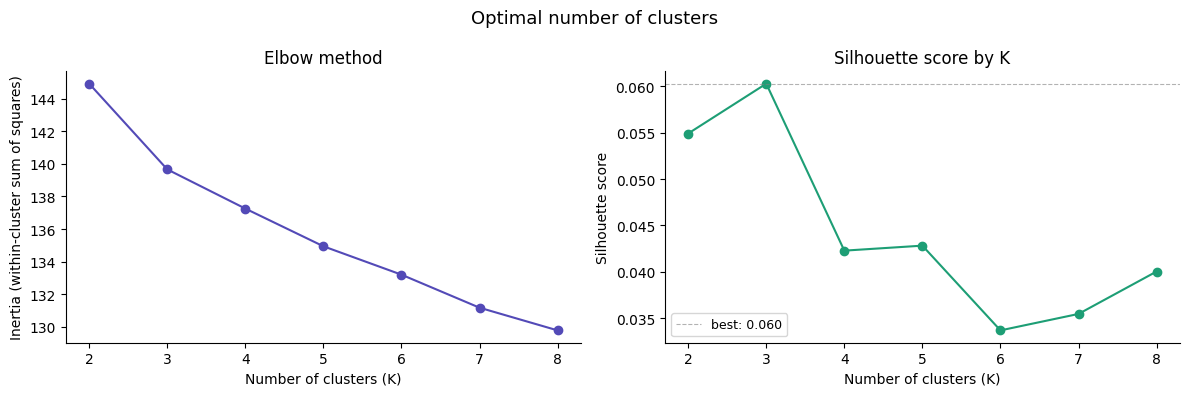


Saved: Step4_elbow_silhouette.png

  Best K by silhouette : 3
  Note: we also run K=3 (one per corpus) for interpretability


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 4-1. Elbow method — find the natural number of clusters
#         Tests K from 2 to 8, plots inertia and silhouette
# ────────────────────────────────────────────────────────────────

from sklearn.metrics import silhouette_score, silhouette_samples

K_RANGE = range(2, 9)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_km = km.fit_predict(vecs_norm)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(vecs_norm, labels_km))
    print(f"  K={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE), inertias, marker="o", color="#534AB7", linewidth=1.5)
ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("Inertia (within-cluster sum of squares)")
ax1.set_title("Elbow method")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.plot(list(K_RANGE), silhouettes, marker="o", color="#1D9E75", linewidth=1.5)
ax2.axhline(max(silhouettes), color="gray", linestyle="--",
            linewidth=0.8, alpha=0.6, label=f"best: {max(silhouettes):.3f}")
ax2.set_xlabel("Number of clusters (K)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette score by K")
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Optimal number of clusters", fontsize=13)
plt.tight_layout()
plt.savefig("Step4_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: Step4_elbow_silhouette.png")

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f"\n  Best K by silhouette : {best_k}")
print(f"  Note: we also run K=3 (one per corpus) for interpretability")


In [ ]:
# ────────────────────────────────────────────────────────────────
# RQ4-2. Run K-Means with K=3 and with best_k
#         K=3 lets us directly ask: does each cluster = one corpus?
# ────────────────────────────────────────────────────────────────

def run_kmeans(k, vecs, labels_true, label=""):
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    km_labels = km.fit_predict(vecs)
    sil    = silhouette_score(vecs, km_labels)
    print(f"\n── K={k} {label} ─────────────────────────────────")
    print(f"   Silhouette score : {sil:.4f}")

    # Cluster composition table
    rows = []
    for cluster_id in range(k):
        mask    = km_labels == cluster_id
        members = [labels_true[i] for i, m in enumerate(mask) if m]
        counts  = Counter(members)
        total   = sum(counts.values())
        majority = counts.most_common(1)[0][0]
        purity   = counts.most_common(1)[0][1] / total

        rows.append({
            "cluster":   cluster_id,
            "total":     total,
            "Originals": counts.get("Originals", 0),
            "Wikipedia": counts.get("Wikipedia", 0),
            "AI":        counts.get("AI (Copilot)", 0),
            "majority":  majority,
            "purity":    round(purity, 3),
        })
        print(f"   Cluster {cluster_id}: {total} docs  "
              f"Orig={counts.get('Originals',0)}  "
              f"Wiki={counts.get('Wikipedia',0)}  "
              f"AI={counts.get('AI (Copilot)',0)}  "
              f"→ majority: {majority} (purity={purity:.2%})")

    # Overall purity
    correct = sum(
        max(Counter([labels_true[i] for i, m in enumerate(km_labels == c) if m]).values())
        for c in range(k)
    )
    overall_purity = correct / len(labels_true)
    print(f"\n   Overall clustering purity : {overall_purity:.4f}")

    return km, km_labels, pd.DataFrame(rows), sil, overall_purity

km3, labels_km3, comp3, sil3, pur3 = run_kmeans(3, vecs_norm, all_labels, "(one per corpus)")

if best_k != 3:
    km_best, labels_best, comp_best, sil_best, pur_best = run_kmeans(
        best_k, vecs_norm, all_labels, f"(best K={best_k})"
    )


── K=3 (one per corpus) ─────────────────────────────────
   Silhouette score : 0.0603
   Cluster 0: 87 docs  Orig=0  Wiki=87  AI=0  → majority: Wikipedia (purity=100.00%)
   Cluster 1: 86 docs  Orig=0  Wiki=0  AI=86  → majority: AI (Copilot) (purity=100.00%)
   Cluster 2: 41 docs  Orig=40  Wiki=0  AI=1  → majority: Originals (purity=97.56%)

   Overall clustering purity : 0.9953


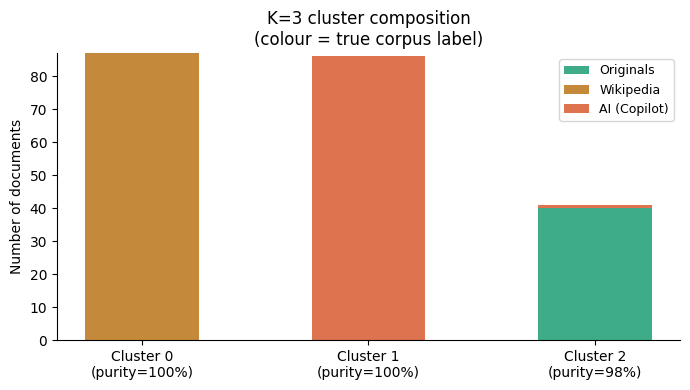

Saved: Step4_cluster_composition.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 4-3. Visualisation 1 — Cluster composition stacked bar chart
# ────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))
x     = np.arange(3)
width = 0.5

bottom = np.zeros(3)
for corpus, color in COLORS.items():
    key = corpus.split()[0]  # "Originals" / "Wikipedia" / "AI"
    col = "AI" if corpus == "AI (Copilot)" else corpus
    vals = comp3[col].values.astype(float)
    ax.bar(x, vals, width, bottom=bottom, label=corpus, color=color, alpha=0.85)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {i}\n(purity={comp3.loc[i,'purity']:.0%})" for i in range(3)])
ax.set_ylabel("Number of documents")
ax.set_title("K=3 cluster composition\n(colour = true corpus label)", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("Step4_cluster_composition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step4_cluster_composition.png")


Reusing t-SNE coordinates from RQ3.


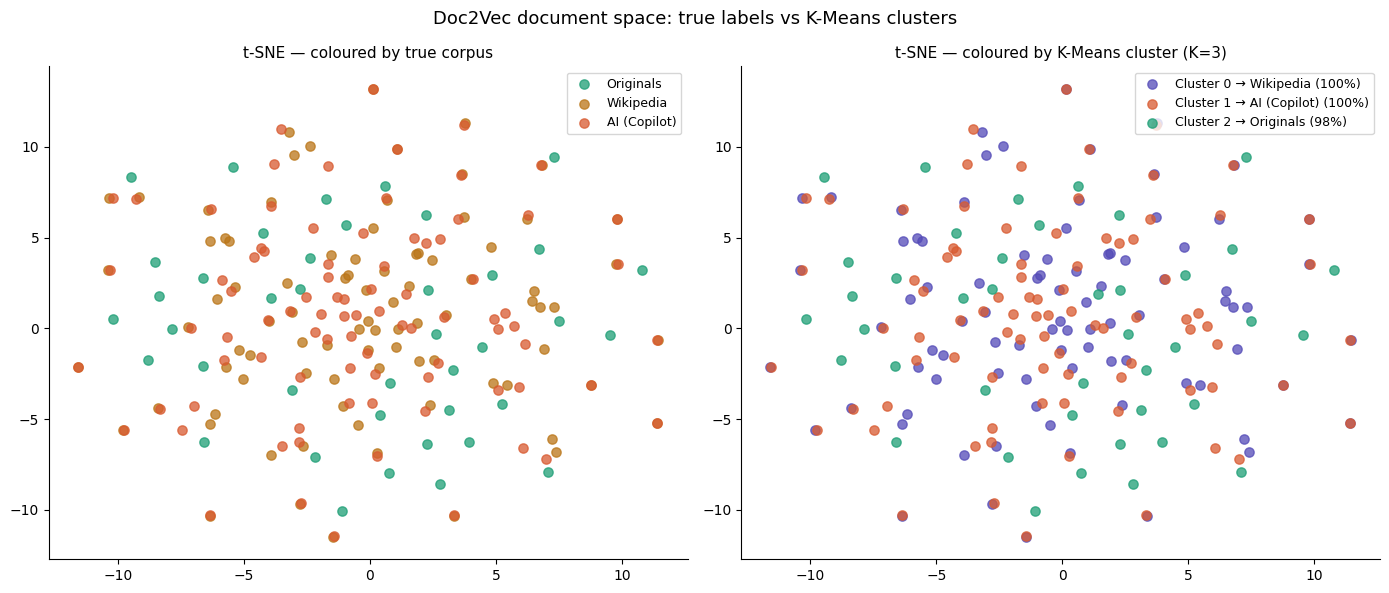

Saved: Step4_tsne_clusters.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 4-4. Visualisation 2 — t-SNE coloured by cluster (K=3)
#         Compared side-by-side with t-SNE coloured by true corpus
# ────────────────────────────────────────────────────────────────

# Reuse or recompute t-SNE coordinates
# If coords already exists from RQ3, reuse it; otherwise recompute
try:
    coords
    print("\nReusing t-SNE coordinates from Step 3.")
except NameError:
    print("\nRecomputing t-SNE...")
    perplexity = min(30, len(all_vecs) // 3 - 1)
    tsne = TSNE(n_components=2, random_state=42, init="pca",
                learning_rate="auto", perplexity=max(5, perplexity))
    coords = tsne.fit_transform(vecs_norm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: coloured by true corpus
for corpus, color in COLORS.items():
    mask = np.array([l == corpus for l in all_labels])
    ax1.scatter(coords[mask, 0], coords[mask, 1],
                c=color, label=corpus, s=45, alpha=0.75, zorder=3)
ax1.set_title("t-SNE — coloured by true corpus", fontsize=11)
ax1.legend(fontsize=9)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

# Right: coloured by K-Means cluster assignment (K=3)
cluster_colors = ["#534AB7", "#D85A30", "#1D9E75"]
for cid in range(3):
    mask = labels_km3 == cid
    majority = comp3.loc[cid, "majority"]
    purity   = comp3.loc[cid, "purity"]
    ax2.scatter(coords[mask, 0], coords[mask, 1],
                c=cluster_colors[cid], s=45, alpha=0.75, zorder=3,
                label=f"Cluster {cid} → {majority} ({purity:.0%})")
ax2.set_title("t-SNE — coloured by K-Means cluster (K=3)", fontsize=11)
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.suptitle("Doc2Vec document space: true labels vs K-Means clusters", fontsize=13)
plt.tight_layout()
plt.savefig("Step4_tsne_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step4_tsne_clusters.png")

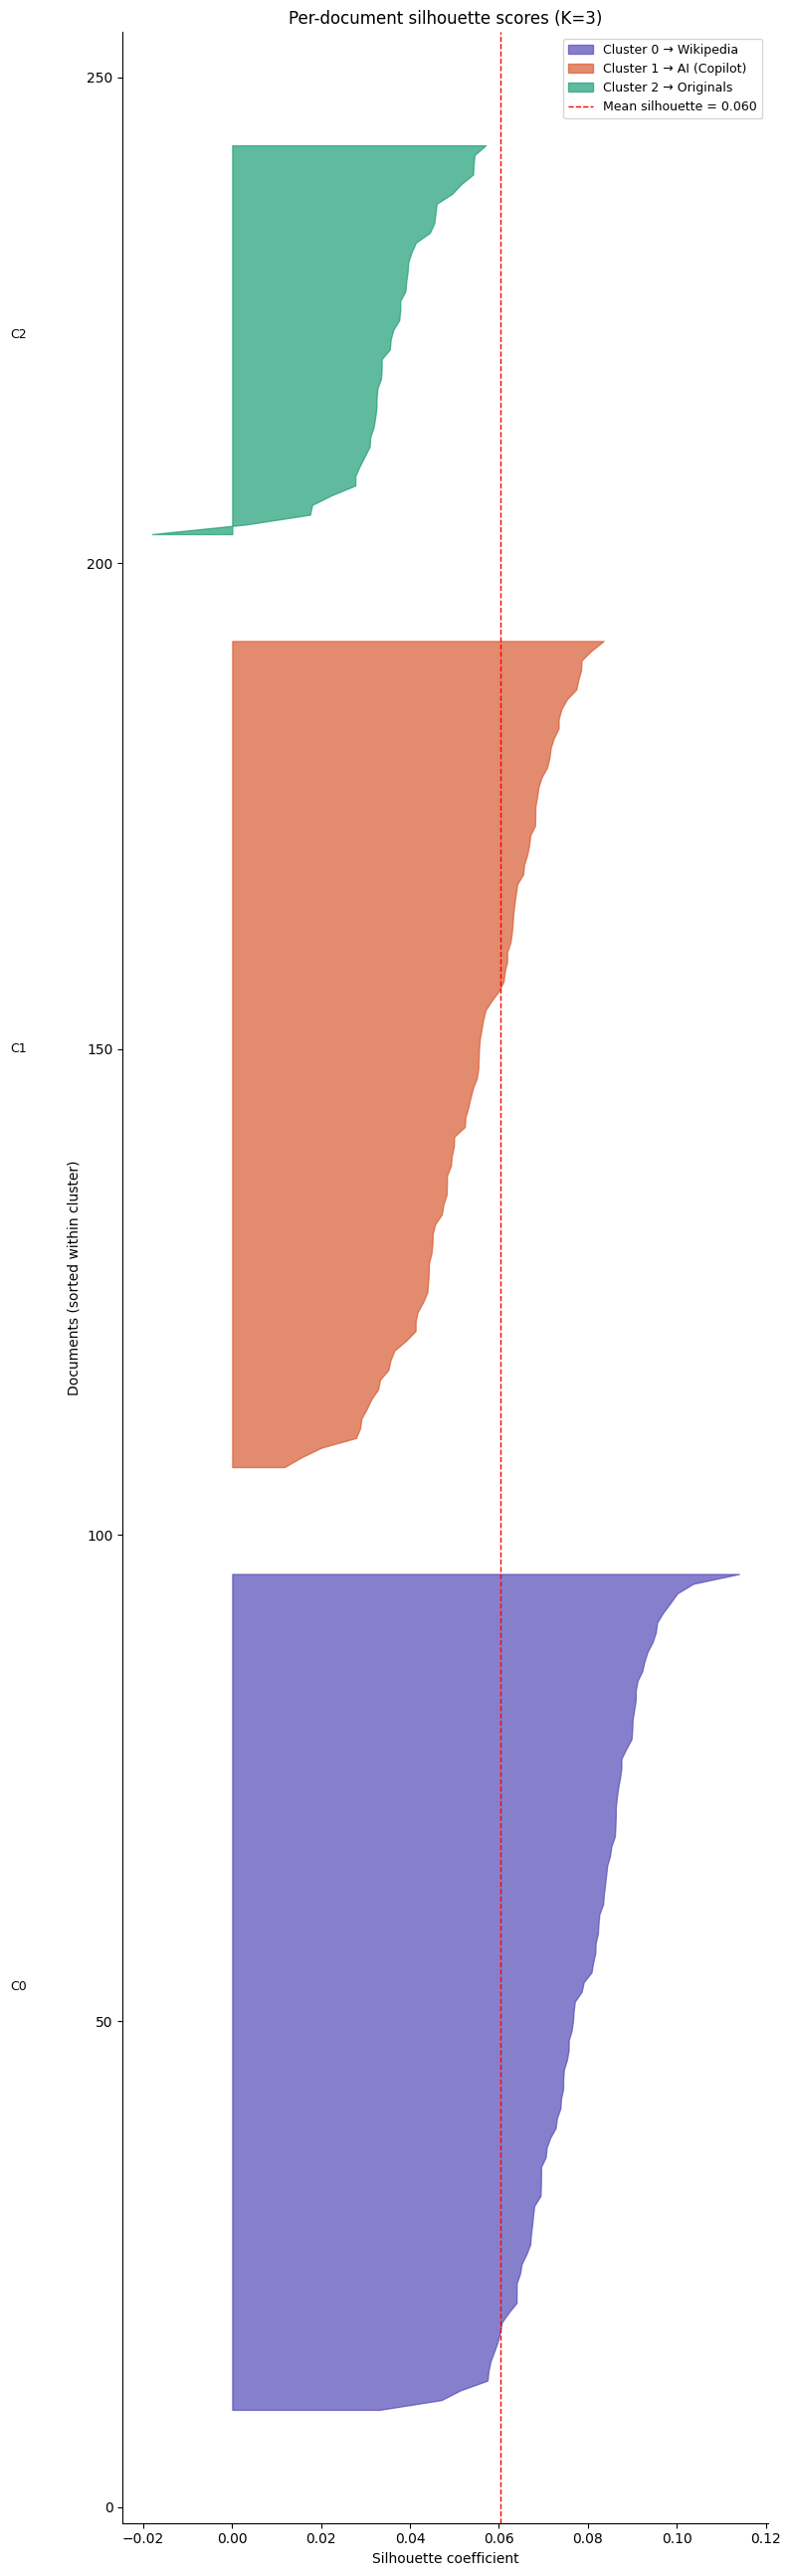

Saved: Step4_silhouette_plot.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 4-5. Visualisation 3 — Silhouette plot (per document)
#         Shows how well each document fits its assigned cluster
# ────────────────────────────────────────────────────────────────

sil_vals = silhouette_samples(vecs_norm, labels_km3)

fig, ax = plt.subplots(figsize=(8, max(5, len(all_vecs) // 8)))
y_lower = 10

for cid in range(3):
    mask      = labels_km3 == cid
    sil_cid   = np.sort(sil_vals[mask])
    size_cid  = sil_cid.shape[0]
    y_upper   = y_lower + size_cid
    majority  = comp3.loc[cid, "majority"]

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_cid,
                     alpha=0.7, color=cluster_colors[cid],
                     label=f"Cluster {cid} → {majority}")
    ax.text(-0.05, y_lower + size_cid / 2, f"C{cid}", fontsize=9, va="center")
    y_lower = y_upper + 10

ax.axvline(sil3, color="red", linestyle="--", linewidth=1,
           label=f"Mean silhouette = {sil3:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Documents (sorted within cluster)")
ax.set_title("Per-document silhouette scores (K=3)", fontsize=12)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("Step4_silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Step4_silhouette_plot.png")


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 4-6. Border documents — texts that cross corpus boundaries
#         Documents assigned to a cluster dominated by another corpus
# ────────────────────────────────────────────────────────────────

print("\n-- Border documents (assigned to foreign-majority cluster) --")

# Ensure correct index
if comp3.index.name != "cluster":
    comp3 = comp3.set_index("cluster")

border_rows = []
for i, (tag, true_label, cluster_id) in enumerate(zip(all_tags, all_labels, labels_km3)):
    cluster_majority = comp3.loc[cluster_id, "majority"]
    if true_label != cluster_majority:
        border_rows.append({
            "document":         tag,
            "true_corpus":      true_label,
            "assigned_cluster": int(cluster_id),
            "cluster_majority": cluster_majority,
            "silhouette":       round(sil_vals[i], 3),
        })

if border_rows:
    border_df = pd.DataFrame(border_rows).sort_values("silhouette")
    print(border_df.to_string(index=False))
else:
    border_df = pd.DataFrame()
    print("  (no border documents -- perfect clustering)")
    print("  Every document lands exactly in its own corpus cluster.")

print(f"\n  Total border documents: {len(border_df)} / {len(all_tags)} "
      f"({len(border_df)/len(all_tags):.1%})")


-- Border documents (assigned to foreign-majority cluster) --
                                     document  true_corpus  assigned_cluster cluster_majority  silhouette
ia_1980_Grimm_Copilot_Hübner_Gevatter_Tod.txt AI (Copilot)                 2        Originals      -0.018

  Total border documents: 1 / 214 (0.5%)


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 4-7. Summary interpretation
# ────────────────────────────────────────────────────────────────

print("\n── Step 4 Summary ──────────────────────────────────────")
print(f"  K=3 silhouette score     : {sil3:.4f}")
print(f"  K=3 overall purity       : {pur3:.4f}")
print(f"  Border documents         : {len(border_df)} ({len(border_df)/len(all_tags):.1%})")
print()
if pur3 >= 0.8:
    print("  → HIGH purity: the 3 corpora are semantically well-separated.")
    print("    K-Means recovers corpus identity without supervision.")
elif pur3 >= 0.6:
    print("  → MODERATE purity: partial separation with notable overlap.")
    print("    Some AI or Wikipedia texts share structure with originals.")
else:
    print("  → LOW purity: strong semantic mixing across corpora.")
    print("    The 3 text types are not distinguishable by their Doc2Vec vectors.")



── Step 4 Summary ──────────────────────────────────────
  K=3 silhouette score     : 0.0603
  K=3 overall purity       : 0.9953
  Border documents         : 1 (0.5%)

  → HIGH purity: the 3 corpora are semantically well-separated.
    K-Means recovers corpus identity without supervision.


In [ ]:
# ────────────────────────────────────────────────────────────────
# Step 4-8. Export
# ────────────────────────────────────────────────────────────────

# Document-level cluster assignments
doc_assignments = pd.DataFrame({
    "document":       all_tags,
    "true_corpus":    all_labels,
    "cluster_k3":     labels_km3,
    "silhouette_k3":  sil_vals.round(4),
})
doc_assignments.to_csv("Step4_cluster_assignments.csv", index=False, encoding="utf-8-sig")

# Cluster composition summary
comp3.to_csv("Step4_cluster_composition.csv", index=False, encoding="utf-8-sig")

print("\n✓ Step4 complete. Files saved:")
print("    · Step4_elbow_silhouette.png")
print("    · Step4_cluster_composition.png")
print("    · Step4_tsne_clusters.png")
print("    · Step4_silhouette_plot.png")
print("    · Step4_cluster_assignments.csv")
print("    · Step4_cluster_composition.csv")


✓ Step4 complete. Files saved:
    · Step4_elbow_silhouette.png
    · Step4_cluster_composition.png
    · Step4_tsne_clusters.png
    · Step4_silhouette_plot.png
    · Step4_cluster_assignments.csv
    · Step4_cluster_composition.csv
